# Análisis exploratorio y selección de variables de carga competitiva

Este notebook analiza las variables de carga competitiva construidas en las etapas anteriores y determina cuáles se incorporarán posteriormente a la modelización.

Se parte de `df_jugador_cargas_enriquecidas.csv`. El análisis se realiza sobre el conjunto de desarrollo, manteniendo la temporada 2024 reservada para la evaluación temporal externa. Se estudian la cobertura y distribución de las cargas, su redundancia, su asociación descriptiva con el porcentaje de juegos ganados, las diferencias jugador–rival y la estabilidad de los principales patrones.

A partir de estos resultados se definen las especificaciones base, principal y ampliada para las familias de 365 y 180 días, además de los datasets de desarrollo y evaluación que utilizarán los notebooks de modelización posteriores.

In [1]:
# Importa NumPy para trabajar con operaciones numéricas y condiciones vectorizadas.
import numpy as np

# Importa pandas para cargar, manipular y transformar datasets en formato tabla.
import pandas as pd

# Importa StandardScaler para estandarizar variables numéricas si más adelante fuera necesario.
from sklearn.preprocessing import StandardScaler

# Importa matplotlib para crear gráficos básicos.
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 1. CARGA Y AUDITORÍA INICIAL DEL DATASET
# ============================================================

import pandas as pd
import numpy as np

# Cargo el dataset completo con cargas acumuladas
# y variables enriquecidas.
data = pd.read_csv(
    "df_jugador_cargas_enriquecidas.csv",
    low_memory=False
)

# Convierto las variables temporales disponibles.
data["fecha_torneo"] = pd.to_datetime(
    data["fecha_torneo"],
    errors="raise"
)

if "fecha_ultima_competitiva" in data.columns:
    data["fecha_ultima_competitiva"] = pd.to_datetime(
        data["fecha_ultima_competitiva"],
        errors="coerce"
    )

# Guardo dimensiones iniciales de forma dinámica.
filas_iniciales = len(data)
columnas_iniciales = data.shape[1]
partidos_iniciales = data["_id_partido"].nunique()

# Columnas temporales de control.
columnas_temporales = [
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal"
]

# ------------------------------------------------------------
# Comprobaciones estructurales mínimas
# ------------------------------------------------------------

assert filas_iniciales > 0
assert columnas_iniciales > 0
assert partidos_iniciales > 0

assert data.columns.is_unique

columnas_minimas = [
    "_id_partido",
    "jugador_id",
    "rival_id",
    "identificador_torneo",
    "fecha_torneo",
    "match_year",
    "porcentaje_juegos_ganados",
    "juegos_365d",
    "juegos_180d",
    "juegos_temporada",
    "historial_365d_completo",
    "historial_180d_completo",
    "historial_56d_completo",
    "fecha_ultima_competitiva"
]

assert set(columnas_minimas).issubset(data.columns), (
    "Faltan columnas mínimas necesarias para el análisis de cargas."
)

assert set(columnas_temporales).issubset(data.columns), (
    "Faltan columnas de control temporal."
)

assert data["_id_partido"].notna().all()

filas_por_partido = (
    data
    .groupby("_id_partido")
    .size()
)

assert filas_por_partido.eq(2).all(), (
    "Algún partido no conserva exactamente dos perspectivas."
)

assert (
    data["es_buffer_carga"]
    + data["es_desarrollo_modelo"]
    + data["es_validacion_temporal"]
).eq(1).all(), (
    "La asignación temporal no es excluyente."
)

assert (
    data["es_desarrollo_modelo"]
    + data["es_validacion_temporal"]
).eq(data["es_muestra_estudio"]).all(), (
    "La muestra de estudio no coincide con desarrollo + validación."
)

assert 2020 not in data["match_year"].unique()

assert data.loc[
    data["match_year"].isin([2008, 2021]),
    "es_buffer_carga"
].eq(1).all()

assert data.loc[
    data["match_year"].eq(2024),
    "es_validacion_temporal"
].eq(1).all()

objetivo_disponible = (
    data["porcentaje_juegos_ganados"]
    .dropna()
)

assert objetivo_disponible.between(0, 1).all()

# ------------------------------------------------------------
# Resumen inicial
# ------------------------------------------------------------

print("Dimensiones del dataset:", data.shape)
print("Partidos únicos:", partidos_iniciales)
print("Jugadores únicos:", data["jugador_id"].nunique())
print(
    "Periodo temporal:",
    data["fecha_torneo"].min().date(),
    "-",
    data["fecha_torneo"].max().date()
)
print(
    "Valores ausentes en la variable objetivo:",
    data["porcentaje_juegos_ganados"].isna().sum()
)
print("Columnas duplicadas:", data.columns.duplicated().sum())

display(
    data.groupby(
        [
            "match_year",
            "es_buffer_carga",
            "es_desarrollo_modelo",
            "es_validacion_temporal",
            "es_muestra_estudio"
        ]
    )
    .size()
    .rename("observaciones")
    .to_frame()
)

display(data.head())

Dimensiones del dataset: (94030, 101)
Partidos únicos: 47015
Jugadores únicos: 1816
Periodo temporal: 2007-12-31 - 2024-12-18
Valores ausentes en la variable objetivo: 0
Columnas duplicadas: 0


,,,,,observaciones
match_year,es_buffer_carga,es_desarrollo_modelo,es_validacion_temporal,es_muestra_estudio,
2008,1,0,0,0,6204
2009,0,1,0,1,6138
2010,0,1,0,1,6026
2011,0,1,0,1,6000
2012,0,1,0,1,5980
2013,0,1,0,1,5844
2014,0,1,0,1,5748
2015,0,1,0,1,5866
2016,0,1,0,1,5840


,identificador_torneo,nombre_torneo,superficie,tamano_cuadro,nivel_torneo,fecha_torneo,numero_partido,match_year,es_muestra_estudio,es_buffer_carga,...,torneos_180d,historial_180d_completo,fecha_ultima_competitiva,juegos_ultima_fecha_competitiva,sets_ultima_fecha_competitiva,partidos_ultima_fecha_competitiva,torneos_ultima_fecha_competitiva,dias_entre_inicios_competitivos,semanas_con_competicion_56d,historial_56d_completo
0,2008-339,Adelaide,Hard,32,ATP,2007-12-31,1,2008,0,1,...,0,False,NaT,NaN,NaN,NaN,NaN,NaN,0,False
1,2008-339,Adelaide,Hard,32,ATP,2007-12-31,1,2008,0,1,...,0,False,NaT,NaN,NaN,NaN,NaN,NaN,0,False
2,2008-339,Adelaide,Hard,32,ATP,2007-12-31,2,2008,0,1,...,0,False,NaT,NaN,NaN,NaN,NaN,NaN,0,False
3,2008-339,Adelaide,Hard,32,ATP,2007-12-31,2,2008,0,1,...,0,False,NaT,NaN,NaN,NaN,NaN,NaN,0,False
4,2008-339,Adelaide,Hard,32,ATP,2007-12-31,3,2008,0,1,...,0,False,NaT,NaN,NaN,NaN,NaN,NaN,0,False


In [3]:

# ============================================================
# 2. CLASIFICACIÓN FUNCIONAL DE LAS VARIABLES
# ============================================================

# ------------------------------------------------------------
# 1. Identificación, trazabilidad y contexto descriptivo
# ------------------------------------------------------------

variables_contextuales = [
    "_id_partido",
    "identificador_torneo",
    "numero_partido",
    "jugador_id",
    "jugador_nombre",
    "rival_id",
    "rival_nombre",
    "fecha_torneo",
    "nombre_torneo",
    "match_year",
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal",
    "marcador_partido",
    "pais",
    "pais_rival"
]


# Variables categóricas originales conservadas
# para descripción e interpretación.
# No se utilizarán directamente junto con sus versiones codificadas.
variables_categoricas_originales = [
    "superficie",
    "nivel_torneo",
    "ronda",
    "mano_dominante",
    "tipo_entrada",
    "mano_dominante_rival",
    "tipo_entrada_rival"
]


# ------------------------------------------------------------
# 2. Predictores tradicionales seleccionados anteriormente
# ------------------------------------------------------------

variables_predictivas_tradicionales = [
    "tamano_cuadro",
    "numero_maximo_sets",
    "cabeza_serie",
    "cabeza_serie_rival",
    "ronda_encoded",
    "es_round_robin",
    "superficie_Clay",
    "superficie_Grass",
    "superficie_Hard",
    "nivel_torneo_ATP",
    "nivel_torneo_ATP_Finals",
    "nivel_torneo_Davis_Cup",
    "nivel_torneo_Grand_Slam",
    "nivel_torneo_Masters_1000",
    "mano_dominante_L",
    "mano_dominante_R",
    "tipo_entrada_DIRECT",
    "tipo_entrada_LL",
    "tipo_entrada_Q",
    "tipo_entrada_WC",
    "mano_dominante_rival_L",
    "mano_dominante_rival_R",
    "tipo_entrada_rival_DIRECT",
    "tipo_entrada_rival_LL",
    "tipo_entrada_rival_Q",
    "tipo_entrada_rival_WC",
    "diff_ranking",
    "diff_edad",
    "diff_altura"
]


# ------------------------------------------------------------
# 3. Variables generadas durante o después del partido
# ------------------------------------------------------------

variables_partido = [
    "aces",
    "dobles_faltas",
    "puntos_servicio_jugados",
    "primeros_saques_dentro",
    "puntos_ganados_primer_saque",
    "puntos_ganados_segundo_saque",
    "juegos_servicio",
    "break_points_salvados",
    "break_points_enfrentados",
    "aces_rival",
    "dobles_faltas_rival",
    "puntos_servicio_jugados_rival",
    "primeros_saques_dentro_rival",
    "puntos_ganados_primer_saque_rival",
    "puntos_ganados_segundo_saque_rival",
    "juegos_servicio_rival",
    "break_points_salvados_rival",
    "break_points_enfrentados_rival",
    "juegos_ganados",
    "juegos_perdidos",
    "sets_ganados",
    "sets_perdidos",
    "total_juegos",
    "total_sets",
    "duracion_partido_minutos"
]


# ------------------------------------------------------------
# 4. Variables objetivo
# ------------------------------------------------------------

variables_objetivo = [
    "porcentaje_juegos_ganados"
]


# ------------------------------------------------------------
# 5. Cargas acumuladas de 365 días
# ------------------------------------------------------------

variables_carga_365d = [
    "juegos_365d",
    "sets_365d",
    "partidos_365d",
    "torneos_365d",
    "historial_365d_completo"
]


# ------------------------------------------------------------
# 6. Cargas acumuladas de 180 días
# ------------------------------------------------------------

variables_carga_180d = [
    "juegos_180d",
    "sets_180d",
    "partidos_180d",
    "torneos_180d",
    "historial_180d_completo"
]


# ------------------------------------------------------------
# 7. Cargas acumuladas durante la temporada
# ------------------------------------------------------------

variables_carga_temporada = [
    "juegos_temporada",
    "sets_temporada",
    "partidos_temporada",
    "torneos_temporada"
]


# ------------------------------------------------------------
# 8. Variables de carga enriquecida
# ------------------------------------------------------------

variables_carga_enriquecida = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d",
    "historial_56d_completo"
]


# Variables numéricas de carga que serán analizadas.
# Se excluyen aquí la fecha y los indicadores de cobertura.
variables_carga_numericas = [
    "juegos_365d",
    "sets_365d",
    "partidos_365d",
    "torneos_365d",
    "juegos_180d",
    "sets_180d",
    "partidos_180d",
    "torneos_180d",
    "juegos_temporada",
    "sets_temporada",
    "partidos_temporada",
    "torneos_temporada",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d"
]


# ------------------------------------------------------------
# 9. Auditoría de la clasificación
# ------------------------------------------------------------

grupos_variables = {
    "Contextuales": variables_contextuales,
    "Categóricas originales": variables_categoricas_originales,
    "Predictoras tradicionales": variables_predictivas_tradicionales,
    "Variables del partido": variables_partido,
    "Variables objetivo": variables_objetivo,
    "Carga 365 días": variables_carga_365d,
    "Carga 180 días": variables_carga_180d,
    "Carga de temporada": variables_carga_temporada,
    "Carga enriquecida": variables_carga_enriquecida
}


variables_clasificadas = [
    variable
    for grupo in grupos_variables.values()
    for variable in grupo
]


variables_faltantes = sorted(
    set(variables_clasificadas)
    - set(data.columns)
)

variables_no_clasificadas = sorted(
    set(data.columns)
    - set(variables_clasificadas)
)

variables_repetidas = (
    pd.Series(variables_clasificadas)
    .value_counts()
)

variables_repetidas = variables_repetidas[
    variables_repetidas > 1
]


# Ninguna variable esperada debe faltar.
assert not variables_faltantes, (
    f"Faltan variables esperadas: {variables_faltantes}"
)

# Todas las columnas del dataset deben quedar clasificadas.
assert not variables_no_clasificadas, (
    f"Hay variables sin clasificar: {variables_no_clasificadas}"
)

# Una columna no debe pertenecer a dos grupos diferentes.
assert variables_repetidas.empty, (
    f"Hay variables repetidas entre grupos: "
    f"{variables_repetidas.to_dict()}"
)

assert len(variables_predictivas_tradicionales) == 29
assert len(variables_carga_numericas) == 18


resumen_clasificacion = pd.DataFrame(
    {
        "grupo": list(grupos_variables.keys()),
        "numero_variables": [
            len(variables)
            for variables in grupos_variables.values()
        ]
    }
)

resumen_clasificacion.loc[
    len(resumen_clasificacion)
] = [
    "Total",
    resumen_clasificacion["numero_variables"].sum()
]


display(resumen_clasificacion)

print("Variables faltantes:", variables_faltantes)
print("Variables no clasificadas:", variables_no_clasificadas)
print("Variables repetidas entre grupos:", len(variables_repetidas))
print("Clasificación completa y coherente.")



,grupo,numero_variables
0,Contextuales,17
1,Categóricas originales,7
2,Predictoras tradicionales,29
3,Variables del partido,25
4,Variables objetivo,1
5,Carga 365 días,5
6,Carga 180 días,5
7,Carga de temporada,4
8,Carga enriquecida,8
9,Total,101


Variables faltantes: []
Variables no clasificadas: []
Variables repetidas entre grupos: 0
Clasificación completa y coherente.


## 3. Cobertura temporal y disponibilidad de las variables de carga

Las variables históricas no están disponibles bajo las mismas condiciones para todas las observaciones.

Las cargas de 365, 180 y 56 días requieren que haya transcurrido un periodo mínimo desde el comienzo observable de cada bloque temporal. Por otra parte, las variables de la última participación requieren que exista al menos una fecha competitiva anterior del mismo jugador dentro de su bloque.

En esta sección se analizará:

* la cobertura completa de cada ventana temporal;
* la disponibilidad de una participación anterior;
* la relación jerárquica entre las ventanas de 365, 180 y 56 días;
* el tamaño potencial de las muestras de modelización;
* la evolución anual de la cobertura.

No se eliminarán observaciones todavía. El objetivo es conocer qué información está disponible antes de definir las muestras definitivas.


In [4]:

# ============================================================
# 3. COBERTURA TEMPORAL Y DISPONIBILIDAD DE HISTORIAL
# ============================================================

# ------------------------------------------------------------
# 1. Comprobación de los indicadores de cobertura
# ------------------------------------------------------------

indicadores_cobertura = [
    "historial_365d_completo",
    "historial_180d_completo",
    "historial_56d_completo"
]


for columna in indicadores_cobertura:

    assert data[columna].notna().all()

    assert set(
        data[columna].unique()
    ).issubset({True, False})


# Las ventanas están anidadas:
# disponer de 365 días implica disponer de 180 y 56 días;
# disponer de 180 días implica disponer de 56 días.
assert (
    (~data["historial_365d_completo"])
    |
    data["historial_180d_completo"]
).all()

assert (
    (~data["historial_180d_completo"])
    |
    data["historial_56d_completo"]
).all()


# ------------------------------------------------------------
# 2. Disponibilidad de la participación anterior
# ------------------------------------------------------------

data["historial_anterior_disponible"] = (
    data["fecha_ultima_competitiva"].notna()
)


columnas_ultima_participacion = [
    "fecha_ultima_competitiva",
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos"
]


# Todas las variables asociadas a la última participación
# deben compartir exactamente la misma máscara de valores ausentes.
mascara_referencia = (
    data["fecha_ultima_competitiva"].isna()
)


for columna in columnas_ultima_participacion[1:]:

    assert (
        data[columna]
        .isna()
        .equals(mascara_referencia)
    )


# ------------------------------------------------------------
# 3. Resumen global de cobertura
# ------------------------------------------------------------

resumen_cobertura = pd.DataFrame(
    {
        "criterio": [
            "Historial completo de 365 días",
            "Historial completo de 180 días",
            "Historial completo de 56 días",
            "Participación anterior disponible",
            "365 días completos + participación anterior",
            "180 días completos + participación anterior",
            "56 días completos + participación anterior"
        ],
        "numero_observaciones": [
            data["historial_365d_completo"].sum(),
            data["historial_180d_completo"].sum(),
            data["historial_56d_completo"].sum(),
            data["historial_anterior_disponible"].sum(),
            (
                data["historial_365d_completo"]
                & data["historial_anterior_disponible"]
            ).sum(),
            (
                data["historial_180d_completo"]
                & data["historial_anterior_disponible"]
            ).sum(),
            (
                data["historial_56d_completo"]
                & data["historial_anterior_disponible"]
            ).sum()
        ]
    }
)


resumen_cobertura["porcentaje"] = (
    resumen_cobertura["numero_observaciones"]
    / len(data)
    * 100
)


display(
    resumen_cobertura.style.format(
        {
            "numero_observaciones": "{:,.0f}",
            "porcentaje": "{:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# 4. Cobertura por temporada
# ------------------------------------------------------------

cobertura_por_ano = (
    data
    .groupby("match_year", as_index=False)
    .agg(
        observaciones=("_id_partido", "size"),
        historial_365d_completo=(
            "historial_365d_completo",
            "sum"
        ),
        historial_180d_completo=(
            "historial_180d_completo",
            "sum"
        ),
        historial_56d_completo=(
            "historial_56d_completo",
            "sum"
        ),
        historial_anterior_disponible=(
            "historial_anterior_disponible",
            "sum"
        )
    )
)


for columna in [
    "historial_365d_completo",
    "historial_180d_completo",
    "historial_56d_completo",
    "historial_anterior_disponible"
]:

    cobertura_por_ano[
        f"porcentaje_{columna}"
    ] = (
        cobertura_por_ano[columna]
        / cobertura_por_ano["observaciones"]
        * 100
    )


display(cobertura_por_ano)


# ------------------------------------------------------------
# 5. Resumen de valores ausentes en las cargas
# ------------------------------------------------------------

resumen_nulos_carga = pd.DataFrame(
    {
        "variable": variables_carga_numericas,
        "numero_nulos": [
            data[columna].isna().sum()
            for columna in variables_carga_numericas
        ]
    }
)


resumen_nulos_carga["porcentaje_nulos"] = (
    resumen_nulos_carga["numero_nulos"]
    / len(data)
    * 100
)


display(
    resumen_nulos_carga.style.format(
        {
            "numero_nulos": "{:,.0f}",
            "porcentaje_nulos": "{:.2f}%"
        }
    )
)


print(
    "Cobertura temporal y valores ausentes "
    "analizados correctamente."
)



,criterio,numero_observaciones,porcentaje
0,Historial completo de 365 días,"82,188",87.41%
1,Historial completo de 180 días,"82,402",87.63%
2,Historial completo de 56 días,"82,402",87.63%
3,Participación anterior disponible,"91,011",96.79%
4,365 días completos + participación anterior,"80,556",85.67%
5,180 días completos + participación anterior,"80,763",85.89%
6,56 días completos + participación anterior,"80,763",85.89%


,match_year,observaciones,historial_365d_completo,historial_180d_completo,historial_56d_completo,historial_anterior_disponible,porcentaje_historial_365d_completo,porcentaje_historial_180d_completo,porcentaje_historial_56d_completo,porcentaje_historial_anterior_disponible
0,2008,6204,0,0,0,5457,0.000000,0.0,0.0,87.959381
1,2009,6138,6138,6138,6138,5968,100.000000,100.0,100.0,97.230368
2,2010,6026,6026,6026,6026,5884,100.000000,100.0,100.0,97.643545
3,2011,6000,6000,6000,6000,5878,100.000000,100.0,100.0,97.966667
4,2012,5980,5980,5980,5980,5879,100.000000,100.0,100.0,98.311037
5,2013,5844,5844,5844,5844,5729,100.000000,100.0,100.0,98.032170
6,2014,5748,5748,5748,5748,5646,100.000000,100.0,100.0,98.225470
7,2015,5866,5866,5866,5866,5767,100.000000,100.0,100.0,98.312308
8,2016,5840,5840,5840,5840,5732,100.000000,100.0,100.0,98.150685
9,2017,5784,5784,5784,5784,5696,100.000000,100.0,100.0,98.478562


,variable,numero_nulos,porcentaje_nulos
0,juegos_365d,0,0.00%
1,sets_365d,0,0.00%
2,partidos_365d,0,0.00%
3,torneos_365d,0,0.00%
4,juegos_180d,0,0.00%
5,sets_180d,0,0.00%
6,partidos_180d,0,0.00%
7,torneos_180d,0,0.00%
8,juegos_temporada,0,0.00%
9,sets_temporada,0,0.00%


Cobertura temporal y valores ausentes analizados correctamente.


## 4. Definición de las muestras analíticas

Las distintas variables de carga requieren diferentes cantidades de historial previo. Por este motivo, no se utilizará una única muestra para todos los análisis.

Se definirán las siguientes muestras:

* **Muestra completa**, utilizada exclusivamente para auditorías generales y análisis de disponibilidad.
* **Muestra de 365 días**, formada por las observaciones con una ventana anual completa.
* **Muestra principal**, formada por las observaciones con una ventana de 365 días completa y una participación anterior disponible.
* **Muestra de robustez de 180 días**, formada por las observaciones con una ventana semestral completa y una participación anterior disponible.
* **Muestra de 56 días**, formada por las observaciones con una ventana de 56 días completa y una participación anterior disponible.

La muestra principal será la referencia para comparar posteriormente el modelo tradicional y el modelo ampliado con variables de carga. Ambos modelos deberán utilizar exactamente las mismas observaciones.

Las muestras no se aplicarán todavía mediante una eliminación permanente de filas. Se conservará el conjunto completo y se utilizarán máscaras booleanas para seleccionar cada subconjunto cuando corresponda.


In [5]:
# ============================================================
# 4. DEFINICIÓN DE LAS MUESTRAS ANALÍTICAS
# ============================================================

# ------------------------------------------------------------
# 1. Máscaras temporales principales
# ------------------------------------------------------------

mascara_desarrollo = data["es_desarrollo_modelo"].eq(1)
mascara_validacion = data["es_validacion_temporal"].eq(1)
mascara_buffer = data["es_buffer_carga"].eq(1)

assert mascara_desarrollo.sum() > 0
assert mascara_validacion.sum() > 0
assert mascara_buffer.sum() > 0

# Dataset de desarrollo para análisis y selección.
data_desarrollo = (
    data.loc[mascara_desarrollo]
    .copy()
)

# Dataset evaluación temporal externa. Se conserva para preparar
# los archivos finales, pero no se usa para decidir variables.
data_validacion = (
    data.loc[mascara_validacion]
    .copy()
)

# ------------------------------------------------------------
# 2. Cobertura individual de cada ventana dentro de desarrollo
# ------------------------------------------------------------

mascara_365d = (
    mascara_desarrollo
    & data["historial_365d_completo"]
)

mascara_180d = (
    mascara_desarrollo
    & data["historial_180d_completo"]
)

mascara_56d = (
    mascara_desarrollo
    & data["historial_56d_completo"]
)

mascara_historial_anterior = (
    mascara_desarrollo
    & data["historial_anterior_disponible"]
)

# ------------------------------------------------------------
# 3. Muestras que combinan cobertura y participación anterior
# ------------------------------------------------------------

mascara_muestra_principal = (
    mascara_365d
    & mascara_historial_anterior
)

mascara_robustez_180d = (
    mascara_180d
    & mascara_historial_anterior
)

mascara_analisis_56d = (
    mascara_56d
    & mascara_historial_anterior
)

# ------------------------------------------------------------
# 4. Comprobaciones metodológicas
# ------------------------------------------------------------

assert mascara_muestra_principal.sum() > 0
assert mascara_robustez_180d.sum() > 0
assert mascara_analisis_56d.sum() > 0

assert (
    ~mascara_muestra_principal
    | mascara_robustez_180d
).all()

assert (
    ~mascara_robustez_180d
    | mascara_analisis_56d
).all()

assert data.loc[
    mascara_muestra_principal,
    "es_desarrollo_modelo"
].eq(1).all()

assert data.loc[
    mascara_muestra_principal,
    "es_buffer_carga"
].eq(0).all()

assert data.loc[
    mascara_muestra_principal,
    "es_validacion_temporal"
].eq(0).all()

# ------------------------------------------------------------
# 5. Creación de subconjuntos independientes
# ------------------------------------------------------------

data_365d = (
    data.loc[mascara_365d]
    .copy()
)

data_muestra_principal = (
    data.loc[mascara_muestra_principal]
    .copy()
)

data_robustez_180d = (
    data.loc[mascara_robustez_180d]
    .copy()
)

data_analisis_56d = (
    data.loc[mascara_analisis_56d]
    .copy()
)

# ------------------------------------------------------------
# 6. Resumen
# ------------------------------------------------------------

resumen_muestras = pd.DataFrame(
    {
        "muestra": [
            "Dataset completo operativo",
            "Desarrollo completo",
            "Evaluación temporal externa 2024",
            "Buffer de carga",
            "Ventana de 365 días completa en desarrollo",
            "Muestra principal 365d en desarrollo",
            "Robustez de 180 días en desarrollo",
            "Análisis de 56 días en desarrollo"
        ],
        "observaciones": [
            len(data),
            len(data_desarrollo),
            len(data_validacion),
            int(mascara_buffer.sum()),
            len(data_365d),
            len(data_muestra_principal),
            len(data_robustez_180d),
            len(data_analisis_56d)
        ]
    }
)

resumen_muestras["porcentaje_total"] = (
    resumen_muestras["observaciones"]
    / len(data)
    * 100
)

display(
    resumen_muestras.style.format(
        {
            "observaciones": "{:,.0f}",
            "porcentaje_total": "{:.2f}%"
        }
    )
)

print("Muestras analíticas de desarrollo definidas correctamente.")

,muestra,observaciones,porcentaje_total
0,Dataset completo operativo,"94,030",100.00%
1,Desarrollo completo,"76,292",81.14%
2,Evaluación temporal externa 2024,"6,110",6.50%
3,Buffer de carga,"11,628",12.37%
4,Ventana de 365 días completa en desarrollo,"76,078",80.91%
5,Muestra principal 365d en desarrollo,"74,553",79.29%
6,Robustez de 180 días en desarrollo,"74,760",79.51%
7,Análisis de 56 días en desarrollo,"74,760",79.51%


Muestras analíticas de desarrollo definidas correctamente.


## 5. Análisis descriptivo univariante de las variables de carga

Las variables de carga se analizarán inicialmente de forma individual para conocer su distribución, dispersión, frecuencia de valores nulos y concentración de observaciones en cero.

Cada familia se estudiará sobre la muestra compatible con su definición temporal:

* las cargas de 365 días se analizarán sobre las observaciones con historial anual completo;
* las cargas de 180 días se analizarán sobre las observaciones con historial semestral completo;
* las cargas de temporada se analizarán sobre el conjunto de desarrollo, sin exigir una ventana temporal mínima adicional;
* las cargas enriquecidas se analizarán sobre las observaciones con 56 días completos y participación anterior disponible.

Para cada variable se calcularán:

* número de observaciones válidas;
* valores ausentes;
* valores iguales a cero;
* media y desviación típica;
* mínimo y máximo;
* cuartiles;
* percentiles 90, 95 y 99;
* número de valores distintos.

Los valores extremos no se eliminarán automáticamente. Primero se comprobará si son coherentes con la estructura de la competición.


In [6]:

# ============================================================
# 5. ANÁLISIS DESCRIPTIVO UNIVARIANTE
# ============================================================

def resumen_descriptivo_cargas(df, variables):
    """
    Genera un resumen descriptivo para un conjunto de
    variables numéricas de carga.
    """

    resultados = []

    for variable in variables:

        serie = df[variable]
        serie_valida = serie.dropna()

        resultados.append(
            {
                "variable": variable,
                "observaciones": serie_valida.shape[0],
                "nulos": serie.isna().sum(),
                "porcentaje_nulos": (
                    serie.isna().mean() * 100
                ),
                "ceros": serie_valida.eq(0).sum(),
                "porcentaje_ceros": (
                    serie_valida.eq(0).mean() * 100
                ),
                "media": serie_valida.mean(),
                "desviacion_tipica": serie_valida.std(),
                "minimo": serie_valida.min(),
                "percentil_25": serie_valida.quantile(0.25),
                "mediana": serie_valida.median(),
                "percentil_75": serie_valida.quantile(0.75),
                "percentil_90": serie_valida.quantile(0.90),
                "percentil_95": serie_valida.quantile(0.95),
                "percentil_99": serie_valida.quantile(0.99),
                "maximo": serie_valida.max(),
                "valores_unicos": serie_valida.nunique()
            }
        )

    return pd.DataFrame(resultados)


# ------------------------------------------------------------
# Variables por familia
# ------------------------------------------------------------

cargas_365d_numericas = [
    "juegos_365d",
    "sets_365d",
    "partidos_365d",
    "torneos_365d"
]

cargas_180d_numericas = [
    "juegos_180d",
    "sets_180d",
    "partidos_180d",
    "torneos_180d"
]

cargas_temporada_numericas = [
    "juegos_temporada",
    "sets_temporada",
    "partidos_temporada",
    "torneos_temporada"
]

cargas_enriquecidas_numericas = [
    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",
    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d"
]


# ------------------------------------------------------------
# Muestras específicas para cada familia
# ------------------------------------------------------------

data_180d = (
    data.loc[mascara_180d]
    .copy()
)

data_temporada = data_desarrollo.copy()

data_enriquecida = (
    data.loc[mascara_analisis_56d]
    .copy()
)


# ------------------------------------------------------------
# Resúmenes descriptivos
# ------------------------------------------------------------

resumen_365d = resumen_descriptivo_cargas(
    data_365d,
    cargas_365d_numericas
)

resumen_180d = resumen_descriptivo_cargas(
    data_180d,
    cargas_180d_numericas
)

resumen_temporada = resumen_descriptivo_cargas(
    data_temporada,
    cargas_temporada_numericas
)

resumen_enriquecidas = resumen_descriptivo_cargas(
    data_enriquecida,
    cargas_enriquecidas_numericas
)


# ------------------------------------------------------------
# Visualización de resultados
# ------------------------------------------------------------

columnas_formato = {
    "porcentaje_nulos": "{:.2f}%",
    "porcentaje_ceros": "{:.2f}%",
    "media": "{:.2f}",
    "desviacion_tipica": "{:.2f}",
    "minimo": "{:.2f}",
    "percentil_25": "{:.2f}",
    "mediana": "{:.2f}",
    "percentil_75": "{:.2f}",
    "percentil_90": "{:.2f}",
    "percentil_95": "{:.2f}",
    "percentil_99": "{:.2f}",
    "maximo": "{:.2f}"
}


print("CARGAS DE 365 DÍAS")
display(
    resumen_365d.style.format(columnas_formato)
)

print("CARGAS DE 180 DÍAS")
display(
    resumen_180d.style.format(columnas_formato)
)

print("CARGAS DE TEMPORADA")
display(
    resumen_temporada.style.format(columnas_formato)
)

print("CARGAS ENRIQUECIDAS")
display(
    resumen_enriquecidas.style.format(columnas_formato)
)


# ------------------------------------------------------------
# Validaciones básicas
# ------------------------------------------------------------

for resumen in [
    resumen_365d,
    resumen_180d,
    resumen_temporada,
    resumen_enriquecidas
]:

    assert resumen["observaciones"].gt(0).all()
    assert resumen["minimo"].ge(0).all()
    assert (
        resumen["maximo"]
        >= resumen["percentil_99"]
    ).all()


print(
    "Análisis descriptivo univariante completado correctamente."
)



CARGAS DE 365 DÍAS


,variable,observaciones,nulos,porcentaje_nulos,ceros,porcentaje_ceros,media,desviacion_tipica,minimo,percentil_25,mediana,percentil_75,percentil_90,percentil_95,percentil_99,maximo,valores_unicos
0,juegos_365d,76078,0,0.00%,2622,3.45%,986.34,591.35,0.00,494.00,1043.00,1435.00,1755.00,1922.00,2139.00,2435.00,2270
1,sets_365d,76078,0,0.00%,2632,3.46%,99.86,59.96,0.00,50.00,105.00,145.00,177.00,196.00,221.00,255.00,253
2,partidos_365d,76078,0,0.00%,2622,3.45%,38.46,23.04,0.00,19.00,41.00,56.00,68.00,75.00,85.00,97.00,98
3,torneos_365d,76078,0,0.00%,2622,3.45%,17.74,8.98,0.00,11.00,20.00,25.00,28.00,29.00,32.00,35.00,36


CARGAS DE 180 DÍAS


,variable,observaciones,nulos,porcentaje_nulos,ceros,porcentaje_ceros,media,desviacion_tipica,minimo,percentil_25,mediana,percentil_75,percentil_90,percentil_95,percentil_99,maximo,valores_unicos
0,juegos_180d,76292,0,0.00%,4789,6.28%,483.60,305.62,0.00,237.00,491.00,707.00,884.00,993.00,1169.00,1530.00,1301
1,sets_180d,76292,0,0.00%,4797,6.29%,48.97,30.94,0.00,24.00,50.00,71.00,90.00,100.00,119.00,158.00,150
2,partidos_180d,76292,0,0.00%,4789,6.28%,18.94,11.88,0.00,9.00,19.00,28.00,34.00,38.00,45.00,59.00,59
3,torneos_180d,76292,0,0.00%,4789,6.28%,8.82,4.70,0.00,6.00,10.00,12.00,15.00,16.00,17.00,21.00,22


CARGAS DE TEMPORADA


,variable,observaciones,nulos,porcentaje_nulos,ceros,porcentaje_ceros,media,desviacion_tipica,minimo,percentil_25,mediana,percentil_75,percentil_90,percentil_95,percentil_99,maximo,valores_unicos
0,juegos_temporada,76292,0,0.00%,8731,11.44%,493.26,450.11,0.00,108.00,378.00,774.00,1164.00,1384.00,1755.00,2269.00,1915
1,sets_temporada,76292,0,0.00%,8741,11.46%,49.94,45.58,0.00,11.00,38.00,78.00,118.00,140.00,178.00,234.00,223
2,partidos_temporada,76292,0,0.00%,8731,11.44%,19.21,17.42,0.00,4.00,15.00,30.00,45.00,53.00,67.00,94.00,89
3,torneos_temporada,76292,0,0.00%,8731,11.44%,8.83,7.28,0.00,2.00,7.00,14.00,20.00,22.00,27.00,35.00,36


CARGAS ENRIQUECIDAS


,variable,observaciones,nulos,porcentaje_nulos,ceros,porcentaje_ceros,media,desviacion_tipica,minimo,percentil_25,mediana,percentil_75,percentil_90,percentil_95,percentil_99,maximo,valores_unicos
0,juegos_ultima_fecha_competitiva,74760,0,0.00%,0,0.00%,52.91,36.27,1.00,26.00,43.00,70.00,101.00,120.00,187.00,349.00,270
1,sets_ultima_fecha_competitiva,74760,0,0.00%,206,0.28%,5.36,3.65,0.00,3.00,4.00,7.00,10.00,12.00,19.00,29.00,30
2,partidos_ultima_fecha_competitiva,74760,0,0.00%,0,0.00%,2.06,1.26,1.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,7
3,torneos_ultima_fecha_competitiva,74760,0,0.00%,0,0.00%,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2
4,dias_entre_inicios_competitivos,74760,0,0.00%,0,0.00%,40.38,110.03,1.00,7.00,14.00,25.00,77.00,161.00,504.00,3375.00,638
5,semanas_con_competicion_56d,74760,0,0.00%,10227,13.68%,2.82,1.72,0.00,1.00,3.00,4.00,5.00,5.00,6.00,7.00,8


Análisis descriptivo univariante completado correctamente.


## 6. Auditoría de valores extremos

Los valores elevados de carga no se considerarán automáticamente errores. Un jugador puede acumular un volumen excepcionalmente alto debido a la duración de los partidos, al número de rondas disputadas o a una participación prolongada en torneos de formato largo.

La auditoría se realizará a nivel jugador–torneo, ya que las variables históricas son constantes para todos los partidos disputados por un jugador dentro del mismo torneo. Utilizar directamente la estructura jugador–partido provocaría que una misma carga extrema apareciera repetida varias veces.

Se revisarán especialmente:

* los mayores acumulados de 365 y 180 días;
* los mayores acumulados de temporada;
* las participaciones anteriores con mayor número de juegos;
* los intervalos más largos entre participaciones;
* los casos con mayor densidad competitiva reciente.

El objetivo será distinguir entre valores extremos plausibles y posibles errores de construcción.


In [7]:

# ============================================================
# 6. AUDITORÍA DE VALORES EXTREMOS
# ============================================================

# Las cargas históricas son constantes dentro de cada
# combinación jugador–torneo. Elimino repeticiones causadas
# por los diferentes partidos disputados en el mismo torneo.
data_jugador_torneo = (
    data_desarrollo
    .sort_values(
        [
            "jugador_id",
            "fecha_torneo",
            "identificador_torneo"
        ]
    )
    .drop_duplicates(
        subset=[
            "jugador_id",
            "identificador_torneo"
        ]
    )
    .copy()
)


assert len(data_jugador_torneo) > 0

assert not data_jugador_torneo.duplicated(
    subset=[
        "jugador_id",
        "identificador_torneo"
    ]
).any()


columnas_contexto = [
    "jugador_id",
    "jugador_nombre",
    "fecha_torneo",
    "nombre_torneo",
    "nivel_torneo",
    "superficie"
]


def mostrar_valores_extremos(
    df,
    variable,
    n=15,
    columnas_adicionales=None
):
    """
    Muestra las observaciones jugador–torneo con los valores
    más elevados de una variable de carga.
    """

    if columnas_adicionales is None:
        columnas_adicionales = []

    columnas_mostrar = (
        columnas_contexto
        + [variable]
        + columnas_adicionales
    )

    columnas_mostrar = list(
        dict.fromkeys(columnas_mostrar)
    )

    resultado = (
        df.loc[
            df[variable].notna(),
            columnas_mostrar
        ]
        .sort_values(
            variable,
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

    return resultado


print("MAYORES CARGAS DE 365 DÍAS")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "juegos_365d",
        columnas_adicionales=[
            "sets_365d",
            "partidos_365d",
            "torneos_365d"
        ]
    )
)


print("MAYORES CARGAS DE 180 DÍAS")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "juegos_180d",
        columnas_adicionales=[
            "sets_180d",
            "partidos_180d",
            "torneos_180d"
        ]
    )
)


print("MAYORES CARGAS DE TEMPORADA")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "juegos_temporada",
        columnas_adicionales=[
            "sets_temporada",
            "partidos_temporada",
            "torneos_temporada"
        ]
    )
)


print("MAYOR CARGA EN LA PARTICIPACIÓN ANTERIOR")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "juegos_ultima_fecha_competitiva",
        columnas_adicionales=[
            "fecha_ultima_competitiva",
            "sets_ultima_fecha_competitiva",
            "partidos_ultima_fecha_competitiva",
            "dias_entre_inicios_competitivos"
        ]
    )
)


print("MAYORES INTERVALOS ENTRE PARTICIPACIONES")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "dias_entre_inicios_competitivos",
        columnas_adicionales=[
            "fecha_ultima_competitiva",
            "juegos_ultima_fecha_competitiva",
            "semanas_con_competicion_56d"
        ]
    )
)


print("MAYOR DENSIDAD COMPETITIVA EN 56 DÍAS")
display(
    mostrar_valores_extremos(
        data_jugador_torneo,
        "semanas_con_competicion_56d",
        columnas_adicionales=[
            "juegos_180d",
            "partidos_180d",
            "dias_entre_inicios_competitivos"
        ]
    )
)


print(
    "Observaciones jugador–torneo auditadas:",
    len(data_jugador_torneo)
)



MAYORES CARGAS DE 365 DÍAS


,jugador_id,jugador_nombre,fecha_torneo,nombre_torneo,nivel_torneo,superficie,juegos_365d,sets_365d,partidos_365d,torneos_365d
0,104918,Andy Murray,2017-01-16,Australian Open,Grand_Slam,Hard,2435,255,92,20
1,104918,Andy Murray,2015-09-18,Davis Cup WG SF: GBR vs AUS,Davis_Cup,Hard,2432,252,95,24
2,104542,Jo-Wilfried Tsonga,2012-08-06,Canada Masters,Masters_1000,Hard,2396,236,88,27
3,106233,Dominic Thiem,2016-06-13,Halle,ATP,Grass,2383,237,90,32
4,106233,Dominic Thiem,2016-06-27,Wimbledon,Grand_Slam,Grass,2382,237,90,31
5,104745,Rafael Nadal,2009-04-20,Barcelona,ATP,Clay,2378,253,97,21
6,104542,Jo-Wilfried Tsonga,2012-08-27,US Open,Grand_Slam,Hard,2365,233,86,27
7,104745,Rafael Nadal,2009-04-27,Rome Masters,Masters_1000,Clay,2353,251,96,21
8,104918,Andy Murray,2015-08-16,Cincinnati Masters,Masters_1000,Hard,2348,244,92,23
9,104918,Andy Murray,2017-03-06,Indian Wells Masters,Masters_1000,Hard,2348,246,92,20


MAYORES CARGAS DE 180 DÍAS


,jugador_id,jugador_nombre,fecha_torneo,nombre_torneo,nivel_torneo,superficie,juegos_180d,sets_180d,partidos_180d,torneos_180d
0,106233,Dominic Thiem,2016-06-27,Wimbledon,Grand_Slam,Grass,1530,155,59,17
1,104918,Andy Murray,2016-10-24,Vienna,ATP,Hard,1472,158,57,11
2,106233,Dominic Thiem,2016-06-13,Halle,ATP,Grass,1472,149,56,16
3,104918,Andy Murray,2016-11-14,Tour Finals,ATP_Finals,Hard,1472,156,55,11
4,104918,Andy Murray,2016-10-31,Paris Masters,Masters_1000,Hard,1452,156,56,11
5,106233,Dominic Thiem,2016-07-25,Canada Masters,Masters_1000,Hard,1402,141,54,16
6,126774,Stefanos Tsitsipas,2022-06-27,Wimbledon,Grand_Slam,Grass,1399,141,53,15
7,104918,Andy Murray,2015-07-17,Davis Cup WG QF: GBR vs FRA,Davis_Cup,Grass,1390,146,53,12
8,104918,Andy Murray,2016-10-03,Beijing,ATP,Hard,1387,149,51,10
9,104918,Andy Murray,2016-10-10,Shanghai Masters,Masters_1000,Hard,1384,148,52,10


MAYORES CARGAS DE TEMPORADA


...

MAYORES INTERVALOS ENTRE PARTICIPACIONES


,jugador_id,jugador_nombre,fecha_torneo,nombre_torneo,nivel_torneo,superficie,dias_entre_inicios_competitivos,fecha_ultima_competitiva,juegos_ultima_fecha_competitiva,semanas_con_competicion_56d
0,105559,Jonathan Eysseric,2017-08-21,Winston-Salem,ATP,Hard,3375.0,2008-05-25,39.0,0
1,105960,Evan King,2017-07-31,Los Cabos,ATP,Hard,3080.0,2009-02-23,18.0,0
2,105091,Peter Torebko,2019-07-15,Umag,ATP,Clay,2856.0,2011-09-19,34.0,0
3,104235,Matwe Middelkoop,2016-07-15,Davis Cup G1 R2: RUS vs NED,Davis_Cup,Hard,2688.0,2009-03-06,18.0,0
4,108772,Julius Tverijonas,2017-09-15,Davis Cup G2 R3: SWE vs LTU,Davis_Cup,Clay,2261.0,2011-07-08,19.0,0
5,105757,Sandro Ehrat,2018-09-14,Davis Cup WG PO: SUI vs SWE,Davis_Cup,Hard,2251.0,2012-07-16,18.0,0
6,105906,Kevin Krawietz,2019-06-24,Antalya,ATP,Grass,2247.0,2013-04-29,18.0,0
7,108985,Ali Ghareeb,2014-04-04,Davis Cup G2 R2: THA vs KUW,Davis_Cup,Hard,2247.0,2008-02-08,22.0,0
8,105454,Brydan Klein,2015-06-29,Wimbledon,Grand_Slam,Grass,2206.0,2009-06-14,48.0,0
9,108739,Wilfredo Gonzalez,2016-03-04,Davis Cup G2 R1: MEX vs GUA,Davis_Cup,Hard,2191.0,2010-03-05,13.0,0


MAYOR DENSIDAD COMPETITIVA EN 56 DÍAS


,jugador_id,jugador_nombre,fecha_torneo,nombre_torneo,nivel_torneo,superficie,semanas_con_competicion_56d,juegos_180d,partidos_180d,dias_entre_inicios_competitivos
0,105932,Nikoloz Basilashvili,2022-06-13,Halle,ATP,Grass,7,614,27,7.0
1,105932,Nikoloz Basilashvili,2022-06-06,Stuttgart,ATP,Grass,7,561,25,14.0
2,100644,Alexander Zverev,2019-05-27,Roland Garros,Grand_Slam,Clay,7,708,29,7.0
3,200282,Alex De Minaur,2022-06-27,Wimbledon,Grand_Slam,Grass,7,960,40,7.0
4,200325,Emil Ruusuvuori,2023-03-06,Indian Wells Masters,Masters_1000,Hard,7,551,26,7.0
5,200325,Emil Ruusuvuori,2023-02-27,Dubai,ATP,Hard,7,529,25,7.0
6,200325,Emil Ruusuvuori,2022-10-03,Astana,ATP,Hard,7,909,38,7.0
7,200325,Emil Ruusuvuori,2022-09-26,Tel Aviv,ATP,Hard,7,874,36,7.0
8,105077,Albert Ramos,2018-05-28,Roland Garros,Grand_Slam,Clay,7,765,30,7.0
9,104559,Teymuraz Gabashvili,2016-05-16,Geneva,ATP,Clay,7,491,22,7.0


Observaciones jugador–torneo auditadas: 40579


### 6.1. Evaluación de la cola del intervalo entre participaciones

La auditoría ha identificado una distribución fuertemente asimétrica en `dias_entre_inicios_competitivos`.

Los intervalos más elevados corresponden a jugadores que reaparecen en el conjunto de datos después de varios años. Estos valores no se eliminarán automáticamente, ya que pueden representar reapariciones reales o periodos durante los que el jugador no disputó competiciones incluidas en la muestra.

No obstante, la variable no debe interpretarse como una medida exacta de descanso fisiológico. Su definición operacional es el número de días transcurridos entre dos participaciones consecutivas observadas dentro del mismo bloque temporal.

Se cuantificará la proporción de observaciones que supera distintos umbrales temporales antes de decidir si conviene utilizar:

* la variable original;
* una transformación logarítmica;
* una limitación superior;
* o categorías de inactividad.


In [8]:

# ============================================================
# 6.1. ANÁLISIS DE LA COLA DEL INTERVALO ENTRE PARTICIPACIONES
# ============================================================

intervalos_jugador_torneo = (
    data_jugador_torneo[
        "dias_entre_inicios_competitivos"
    ]
    .dropna()
    .astype(float)
)


umbrales_dias = [
    28,
    56,
    90,
    180,
    365,
    730,
    1095,
    1825
]


resumen_cola_intervalo = pd.DataFrame(
    {
        "umbral_dias": umbrales_dias,
        "observaciones_superiores": [
            intervalos_jugador_torneo.gt(umbral).sum()
            for umbral in umbrales_dias
        ]
    }
)


resumen_cola_intervalo[
    "porcentaje_superior"
] = (
    resumen_cola_intervalo[
        "observaciones_superiores"
    ]
    / len(intervalos_jugador_torneo)
    * 100
)


display(
    resumen_cola_intervalo.style.format(
        {
            "observaciones_superiores": "{:,.0f}",
            "porcentaje_superior": "{:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# Distribución de la variable de última participación
# ------------------------------------------------------------

distribucion_torneos_ultima_fecha = (
    data_jugador_torneo[
        "torneos_ultima_fecha_competitiva"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
    .rename_axis(
        "torneos_ultima_fecha_competitiva"
    )
    .to_frame(
        "numero_observaciones"
    )
)


distribucion_torneos_ultima_fecha[
    "porcentaje"
] = (
    distribucion_torneos_ultima_fecha[
        "numero_observaciones"
    ]
    / len(data_jugador_torneo)
    * 100
)


display(
    distribucion_torneos_ultima_fecha.style.format(
        {
            "numero_observaciones": "{:,.0f}",
            "porcentaje": "{:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# Promedio de juegos por partido en los casos extremos
# ------------------------------------------------------------

control_coherencia_volumen = pd.DataFrame(
    {
        "horizonte": [
            "365 días",
            "180 días",
            "Temporada",
            "Última participación"
        ],
        "maximo_juegos_por_partido": [
            (
                data_jugador_torneo["juegos_365d"]
                / data_jugador_torneo["partidos_365d"]
                .replace(0, np.nan)
            ).max(),
            (
                data_jugador_torneo["juegos_180d"]
                / data_jugador_torneo["partidos_180d"]
                .replace(0, np.nan)
            ).max(),
            (
                data_jugador_torneo["juegos_temporada"]
                / data_jugador_torneo["partidos_temporada"]
                .replace(0, np.nan)
            ).max(),
            (
                data_jugador_torneo[
                    "juegos_ultima_fecha_competitiva"
                ]
                / data_jugador_torneo[
                    "partidos_ultima_fecha_competitiva"
                ]
                .replace(0, np.nan)
            ).max()
        ]
    }
)


display(
    control_coherencia_volumen.style.format(
        {
            "maximo_juegos_por_partido": "{:.2f}"
        }
    )
)


print(
    "Análisis de la cola y coherencia de los extremos completado."
)



,umbral_dias,observaciones_superiores,porcentaje_superior
0,28,"9,519",24.19%
1,56,"6,639",16.87%
2,90,"4,636",11.78%
3,180,"2,341",5.95%
4,365,815,2.07%
5,730,272,0.69%
6,1095,115,0.29%
7,1825,22,0.06%


,numero_observaciones,porcentaje
torneos_ultima_fecha_competitiva,,
1.000000,"39,353",96.98%
2.000000,1,0.00%
nan,"1,225",3.02%


,horizonte,maximo_juegos_por_partido
0,365 días,67.00
1,180 días,67.00
2,Temporada,67.00
3,Última participación,183.00


Análisis de la cola y coherencia de los extremos completado.


### 6.2. Transformación del intervalo entre participaciones

La distribución de `dias_entre_inicios_competitivos` presenta una cola derecha prolongada. Aunque los intervalos superiores a un año representan una proporción reducida de las observaciones, sus magnitudes pueden ejercer una influencia desproporcionada en modelos lineales.

Por este motivo, se construirá una versión logarítmica:

$$
D_{i,t}^{\log}=
\log\left(1+D_{i,t}\right).
$$

La variable original se conservará para facilitar la interpretación en días. La transformación se utilizará como candidata en los análisis de correlación y modelización, sin eliminar ni modificar las observaciones originales.

Esta transformación no implica que los intervalos elevados sean erróneos. Su finalidad es reducir la influencia estadística de la cola extrema y representar de forma más equilibrada las diferencias entre intervalos cortos, medios y prolongados.


In [9]:

# ============================================================
# 6.2. TRANSFORMACIÓN LOGARÍTMICA DEL INTERVALO
# ============================================================

data[
    "log_dias_entre_inicios_competitivos"
] = np.log1p(
    data["dias_entre_inicios_competitivos"]
)


# Incorporo también la variable a los subconjuntos ya creados.
data_365d[
    "log_dias_entre_inicios_competitivos"
] = np.log1p(
    data_365d["dias_entre_inicios_competitivos"]
)

data_muestra_principal[
    "log_dias_entre_inicios_competitivos"
] = np.log1p(
    data_muestra_principal[
        "dias_entre_inicios_competitivos"
    ]
)

data_robustez_180d[
    "log_dias_entre_inicios_competitivos"
] = np.log1p(
    data_robustez_180d[
        "dias_entre_inicios_competitivos"
    ]
)

data_analisis_56d[
    "log_dias_entre_inicios_competitivos"
] = np.log1p(
    data_analisis_56d[
        "dias_entre_inicios_competitivos"
    ]
)


# ------------------------------------------------------------
# Comprobaciones
# ------------------------------------------------------------

assert (
    data[
        "log_dias_entre_inicios_competitivos"
    ]
    .isna()
    .equals(
        data[
            "dias_entre_inicios_competitivos"
        ].isna()
    )
)

assert (
    data.loc[
        data[
            "dias_entre_inicios_competitivos"
        ].notna(),
        "log_dias_entre_inicios_competitivos"
    ]
    .ge(0)
    .all()
)


comparacion_intervalo = pd.DataFrame(
    {
        "estadistico": [
            "Mínimo",
            "Mediana",
            "Percentil 75",
            "Percentil 90",
            "Percentil 95",
            "Percentil 99",
            "Máximo"
        ],
        "escala_original": [
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].min(),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].median(),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].quantile(0.75),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].quantile(0.90),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].quantile(0.95),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].quantile(0.99),
            data_muestra_principal[
                "dias_entre_inicios_competitivos"
            ].max()
        ],
        "escala_logaritmica": [
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].min(),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].median(),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].quantile(0.75),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].quantile(0.90),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].quantile(0.95),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].quantile(0.99),
            data_muestra_principal[
                "log_dias_entre_inicios_competitivos"
            ].max()
        ]
    }
)


display(
    comparacion_intervalo.style.format(
        {
            "escala_original": "{:.2f}",
            "escala_logaritmica": "{:.3f}"
        }
    )
)


print(
    "Transformación logarítmica construida correctamente."
)



,estadistico,escala_original,escala_logaritmica
0,Mínimo,1.00,0.693
1,Mediana,14.00,2.708
2,Percentil 75,25.00,3.258
3,Percentil 90,77.00,4.357
4,Percentil 95,161.00,5.088
5,Percentil 99,504.00,6.225
6,Máximo,3375.00,8.124


Transformación logarítmica construida correctamente.


## 7. Análisis gráfico de las distribuciones

Las estadísticas descriptivas permiten resumir las variables, pero no muestran completamente su forma, concentración o asimetría. Por este motivo, se representarán gráficamente algunas medidas representativas de cada dimensión de carga.

Se analizarán:

* `juegos_365d`, como medida principal de volumen anual;
* `juegos_180d`, como medida de volumen semestral;
* `juegos_temporada`, como acumulado dentro de la temporada;
* `juegos_ultima_fecha_competitiva`, como carga inmediata;
* `dias_entre_inicios_competitivos`, en escala original;
* `log_dias_entre_inicios_competitivos`, en escala logarítmica;
* `semanas_con_competicion_56d`, como medida discreta de densidad reciente.

En cada histograma se mostrarán la media y la mediana. Una separación notable entre ambas será indicativa de asimetría y de la presencia de una cola prolongada.

La representación de estas variables no implica todavía su selección definitiva. Su finalidad es comprender su distribución antes de estudiar la redundancia y su relación con el rendimiento.


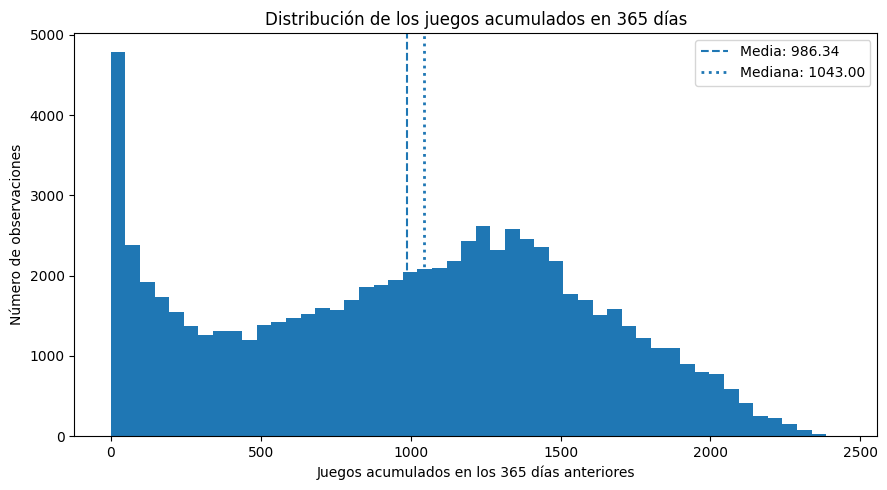

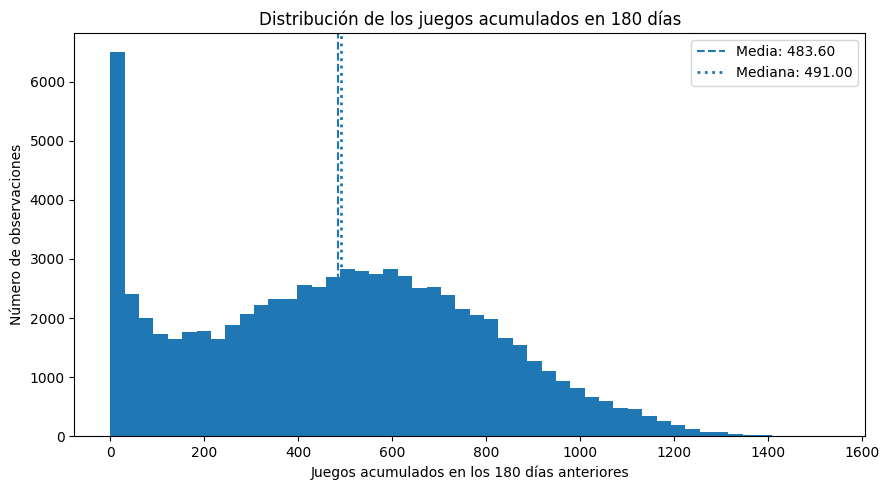

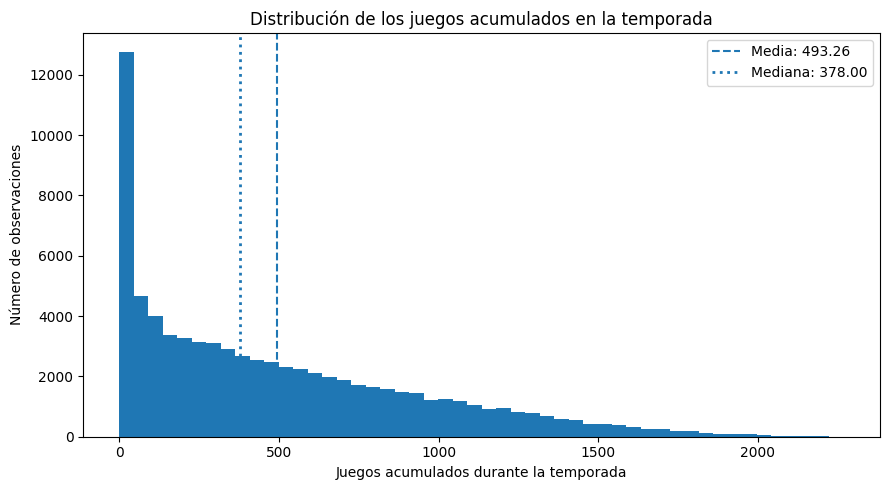

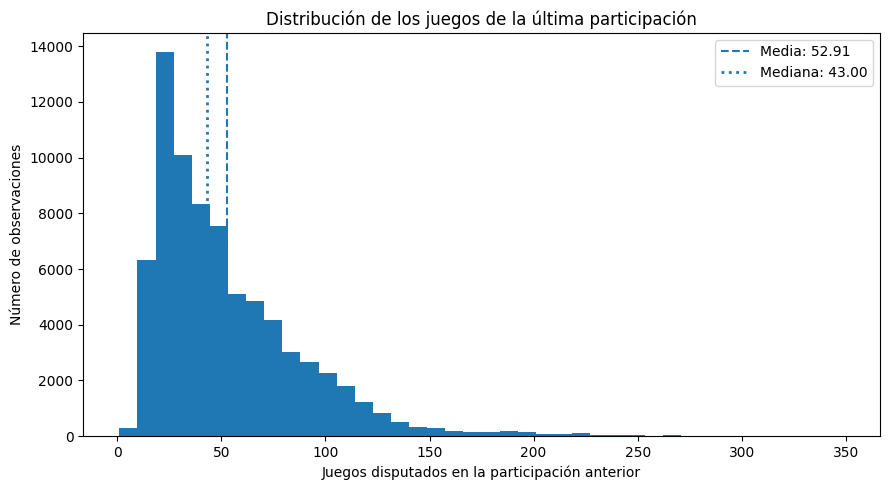

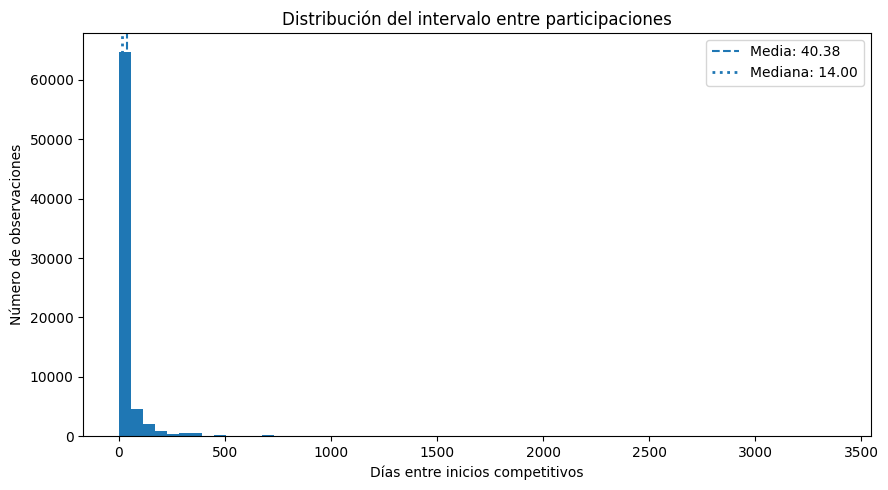

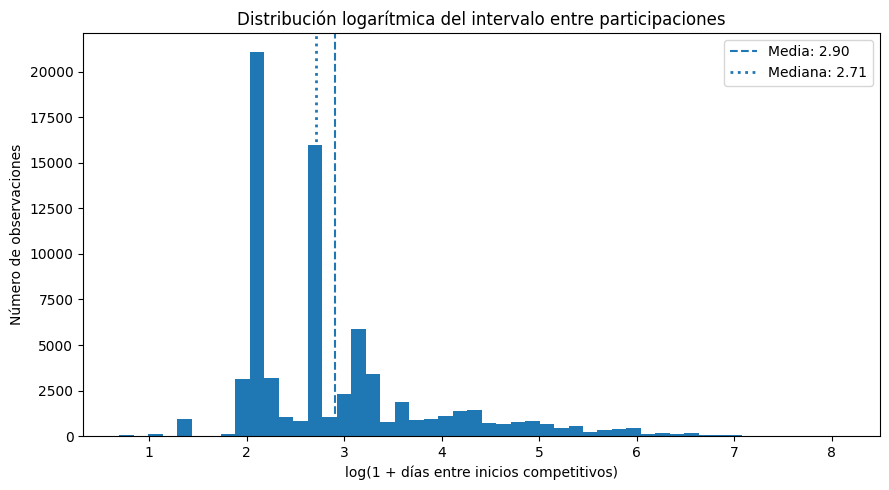

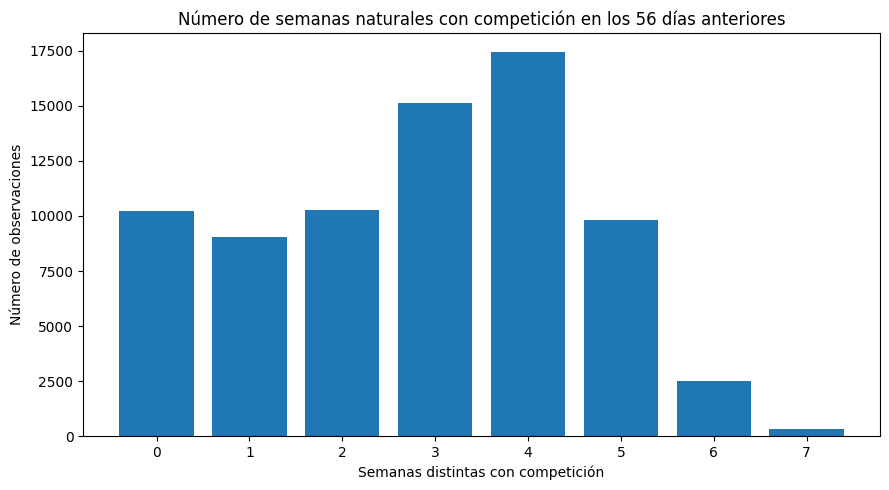

,semanas_con_competicion_56d,observaciones,porcentaje
0,0,"10,227",13.68%
1,1,"9,053",12.11%
2,2,"10,271",13.74%
3,3,"15,135",20.24%
4,4,"17,444",23.33%
5,5,"9,804",13.11%
6,6,"2,515",3.36%
7,7,311,0.42%


Representación gráfica de las distribuciones completada.


In [10]:

# ============================================================
# 7. ANÁLISIS GRÁFICO DE LAS DISTRIBUCIONES
# ============================================================

graficos_carga = [
    {
        "df": data_365d,
        "variable": "juegos_365d",
        "titulo": "Distribución de los juegos acumulados en 365 días",
        "eje_x": "Juegos acumulados en los 365 días anteriores",
        "bins": 50
    },
    {
        "df": data_180d,
        "variable": "juegos_180d",
        "titulo": "Distribución de los juegos acumulados en 180 días",
        "eje_x": "Juegos acumulados en los 180 días anteriores",
        "bins": 50
    },
    {
        "df": data_temporada,
        "variable": "juegos_temporada",
        "titulo": "Distribución de los juegos acumulados en la temporada",
        "eje_x": "Juegos acumulados durante la temporada",
        "bins": 50
    },
    {
        "df": data_analisis_56d,
        "variable": "juegos_ultima_fecha_competitiva",
        "titulo": "Distribución de los juegos de la última participación",
        "eje_x": "Juegos disputados en la participación anterior",
        "bins": 40
    },
    {
        "df": data_analisis_56d,
        "variable": "dias_entre_inicios_competitivos",
        "titulo": "Distribución del intervalo entre participaciones",
        "eje_x": "Días entre inicios competitivos",
        "bins": 60
    },
    {
        "df": data_analisis_56d,
        "variable": "log_dias_entre_inicios_competitivos",
        "titulo": "Distribución logarítmica del intervalo entre participaciones",
        "eje_x": "log(1 + días entre inicios competitivos)",
        "bins": 50
    }
]


for configuracion in graficos_carga:

    variable = configuracion["variable"]

    serie = (
        configuracion["df"][variable]
        .dropna()
        .astype(float)
    )

    media = serie.mean()
    mediana = serie.median()

    plt.figure(figsize=(9, 5))

    plt.hist(
        serie,
        bins=configuracion["bins"]
    )

    plt.axvline(
        media,
        linestyle="--",
        linewidth=1.5,
        label=f"Media: {media:.2f}"
    )

    plt.axvline(
        mediana,
        linestyle=":",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}"
    )

    plt.title(configuracion["titulo"])
    plt.xlabel(configuracion["eje_x"])
    plt.ylabel("Número de observaciones")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Distribución discreta de la densidad de 56 días
# ------------------------------------------------------------

frecuencia_semanas_56d = (
    data_analisis_56d[
        "semanas_con_competicion_56d"
    ]
    .value_counts()
    .sort_index()
)


porcentaje_semanas_56d = (
    frecuencia_semanas_56d
    / frecuencia_semanas_56d.sum()
    * 100
)


plt.figure(figsize=(9, 5))

plt.bar(
    frecuencia_semanas_56d.index.astype(str),
    frecuencia_semanas_56d.values
)

plt.title(
    "Número de semanas naturales con competición "
    "en los 56 días anteriores"
)
plt.xlabel("Semanas distintas con competición")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()


resumen_semanas_56d = pd.DataFrame(
    {
        "semanas_con_competicion_56d": (
            frecuencia_semanas_56d.index
        ),
        "observaciones": frecuencia_semanas_56d.values,
        "porcentaje": porcentaje_semanas_56d.values
    }
)


display(
    resumen_semanas_56d.style.format(
        {
            "observaciones": "{:,.0f}",
            "porcentaje": "{:.2f}%"
        }
    )
)


print(
    "Representación gráfica de las distribuciones completada."
)



### 7.1. Comparación gráfica de la escala original y logarítmica

La variable `dias_entre_inicios_competitivos` presenta una distribución fuertemente
asimétrica hacia la derecha, debido a la existencia de un número reducido de intervalos
competitivos excepcionalmente prolongados.

Para visualizar el efecto de la transformación aplicada previamente, se comparan
la distribución original y la correspondiente a `log(1 + D)` sobre exactamente las
mismas observaciones. La transformación no elimina registros ni pretende normalizar
la variable, sino comprimir la cola derecha y representar de forma más equilibrada
las diferencias entre intervalos competitivos cortos, intermedios y prolongados.

La representación conjunta se utilizará posteriormente como resultado complementario
en el anexo del trabajo.

Observaciones: 74,760
Media original: 40.38
Mediana original: 14.00
P99 original: 504.00
Máximo original: 3375.00
Media logarítmica: 2.90
Mediana logarítmica: 2.71


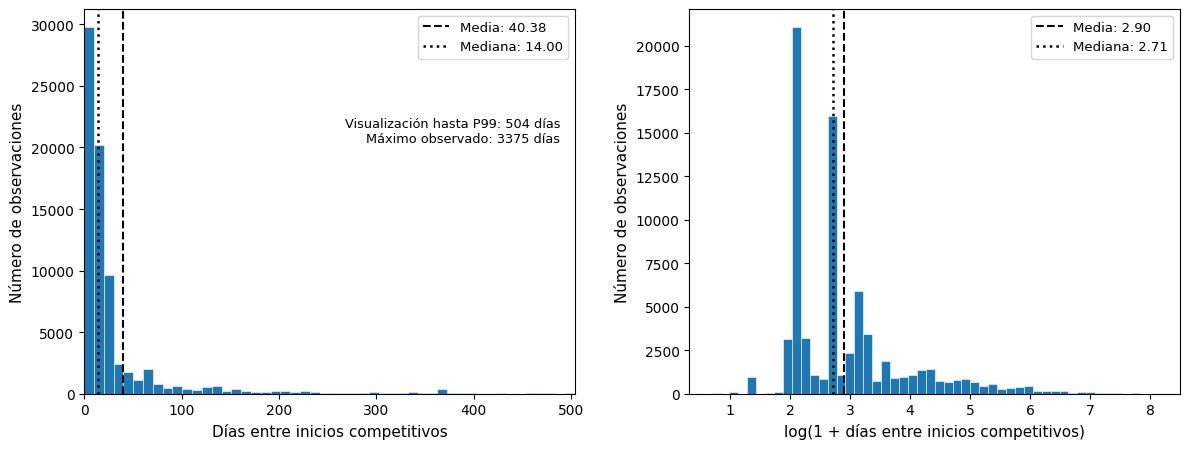

In [11]:
# ============================================================
# FIGURA COMPLEMENTARIA
# INTERVALO ENTRE PARTICIPACIONES:
# ESCALA ORIGINAL VS. TRANSFORMACIÓN LOGARÍTMICA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Preparación de la muestra
# ------------------------------------------------------------

serie_original = (
    data_analisis_56d[
        "dias_entre_inicios_competitivos"
    ]
    .dropna()
    .astype(float)
)


serie_log = (
    data_analisis_56d.loc[
        serie_original.index,
        "log_dias_entre_inicios_competitivos"
    ]
    .astype(float)
)


# ------------------------------------------------------------
# 2. Comprobaciones de coherencia
# ------------------------------------------------------------

assert len(serie_original) == len(serie_log)

assert serie_original.notna().all()
assert serie_log.notna().all()

assert (serie_original >= 0).all()

assert np.allclose(
    serie_log.to_numpy(),
    np.log1p(serie_original.to_numpy())
)


# ------------------------------------------------------------
# 3. Estadísticos descriptivos
# ------------------------------------------------------------

media_original = serie_original.mean()
mediana_original = serie_original.median()

media_log = serie_log.mean()
mediana_log = serie_log.median()

p99_original = serie_original.quantile(0.99)
max_original = serie_original.max()


print(
    f"Observaciones: {len(serie_original):,}"
)

print(
    f"Media original: {media_original:.2f}"
)

print(
    f"Mediana original: {mediana_original:.2f}"
)

print(
    f"P99 original: {p99_original:.2f}"
)

print(
    f"Máximo original: {max_original:.2f}"
)

print(
    f"Media logarítmica: {media_log:.2f}"
)

print(
    f"Mediana logarítmica: {mediana_log:.2f}"
)


# ------------------------------------------------------------
# 4. Límites de los bins del panel original
#
# El panel izquierdo representa hasta P99 para mejorar
# la legibilidad. El 1 % superior NO se elimina del análisis:
# únicamente queda fuera de esta representación concreta.
# ------------------------------------------------------------

bins_original = np.linspace(
    0,
    p99_original,
    51
)


# ------------------------------------------------------------
# 5. Figura conjunta
# ------------------------------------------------------------

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(12, 4.6)
)


# ============================================================
# PANEL IZQUIERDO
# Distribución en la escala original
# ============================================================

ejes[0].hist(
    serie_original,
    bins=bins_original,
    edgecolor="white",
    linewidth=0.4
)

ejes[0].axvline(
    media_original,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Media: {media_original:.2f}"
)

ejes[0].axvline(
    mediana_original,
    color="black",
    linestyle=":",
    linewidth=1.8,
    label=f"Mediana: {mediana_original:.2f}"
)

ejes[0].set_xlim(
    0,
    p99_original
)

ejes[0].set_xlabel(
    "Días entre inicios competitivos",
    fontsize=11
)

ejes[0].set_ylabel(
    "Número de observaciones",
    fontsize=11
)

ejes[0].tick_params(
    axis="both",
    labelsize=10
)

ejes[0].legend(
    fontsize=9.5,
    frameon=True
)


# Información sobre la cola no representada
ejes[0].text(
    0.97,
    0.72,
    (
        f"Visualización hasta P99: "
        f"{p99_original:.0f} días\n"
        f"Máximo observado: "
        f"{max_original:.0f} días"
    ),
    transform=ejes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9.3
)


# ============================================================
# PANEL DERECHO
# Distribución después de log(1 + D)
# ============================================================

ejes[1].hist(
    serie_log,
    bins=50,
    edgecolor="white",
    linewidth=0.4
)

ejes[1].axvline(
    media_log,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Media: {media_log:.2f}"
)

ejes[1].axvline(
    mediana_log,
    color="black",
    linestyle=":",
    linewidth=1.8,
    label=f"Mediana: {mediana_log:.2f}"
)

ejes[1].set_xlabel(
    "log(1 + días entre inicios competitivos)",
    fontsize=11
)

ejes[1].set_ylabel(
    "Número de observaciones",
    fontsize=11
)

ejes[1].tick_params(
    axis="both",
    labelsize=10
)

ejes[1].legend(
    fontsize=9.5,
    frameon=True
)


# ------------------------------------------------------------
# 6. Ajuste final
# ------------------------------------------------------------

fig.tight_layout(
    w_pad=2.2
)

plt.show()

## 8. Dependencia y redundancia entre las variables de carga

La redundancia entre las variables de carga se evaluará mediante diferentes medidas complementarias. No se utilizará un único coeficiente, ya que cada medida identifica un tipo distinto de asociación.

En una primera fase se calcularán:

* la correlación de Pearson, para estudiar relaciones lineales;
* la correlación de Spearman, para estudiar relaciones monótonas a partir de los rangos;
* el coeficiente Kendall tau-b, para medir concordancia teniendo en cuenta los empates.

Posteriormente se incorporarán medidas generales de dependencia no lineal, diagnósticos multivariantes de colinealidad y técnicas de agrupación de variables.

El análisis se realizará inicialmente sobre la muestra principal, formada por observaciones con una ventana completa de 365 días y una participación anterior disponible. Todas las medidas se calcularán sobre las mismas observaciones.

La selección final no se basará en un umbral automático. Se combinarán:

$$
\text{dependencia estadística}
+
\text{estabilidad temporal}
+
\text{significado deportivo}
+
\text{asociación con la variable objetivo}.
$$

Las medidas de significación estadística no constituirán el criterio principal, debido al elevado tamaño muestral y a la dependencia existente entre observaciones del mismo jugador y partido.


Muestra preparada: (74553, 18)
Calculando matriz de Pearson...
Pearson calculado.
Calculando matriz de Spearman...
Spearman calculado.
Calculando Kendall tau-b para 153 pares...
Kendall: 20/153 pares
Kendall: 40/153 pares
Kendall: 60/153 pares
Kendall: 80/153 pares
Kendall: 100/153 pares
Kendall: 120/153 pares
Kendall: 140/153 pares
Kendall: 153/153 pares
Kendall tau-b calculado.
Generando gráfico de Pearson...


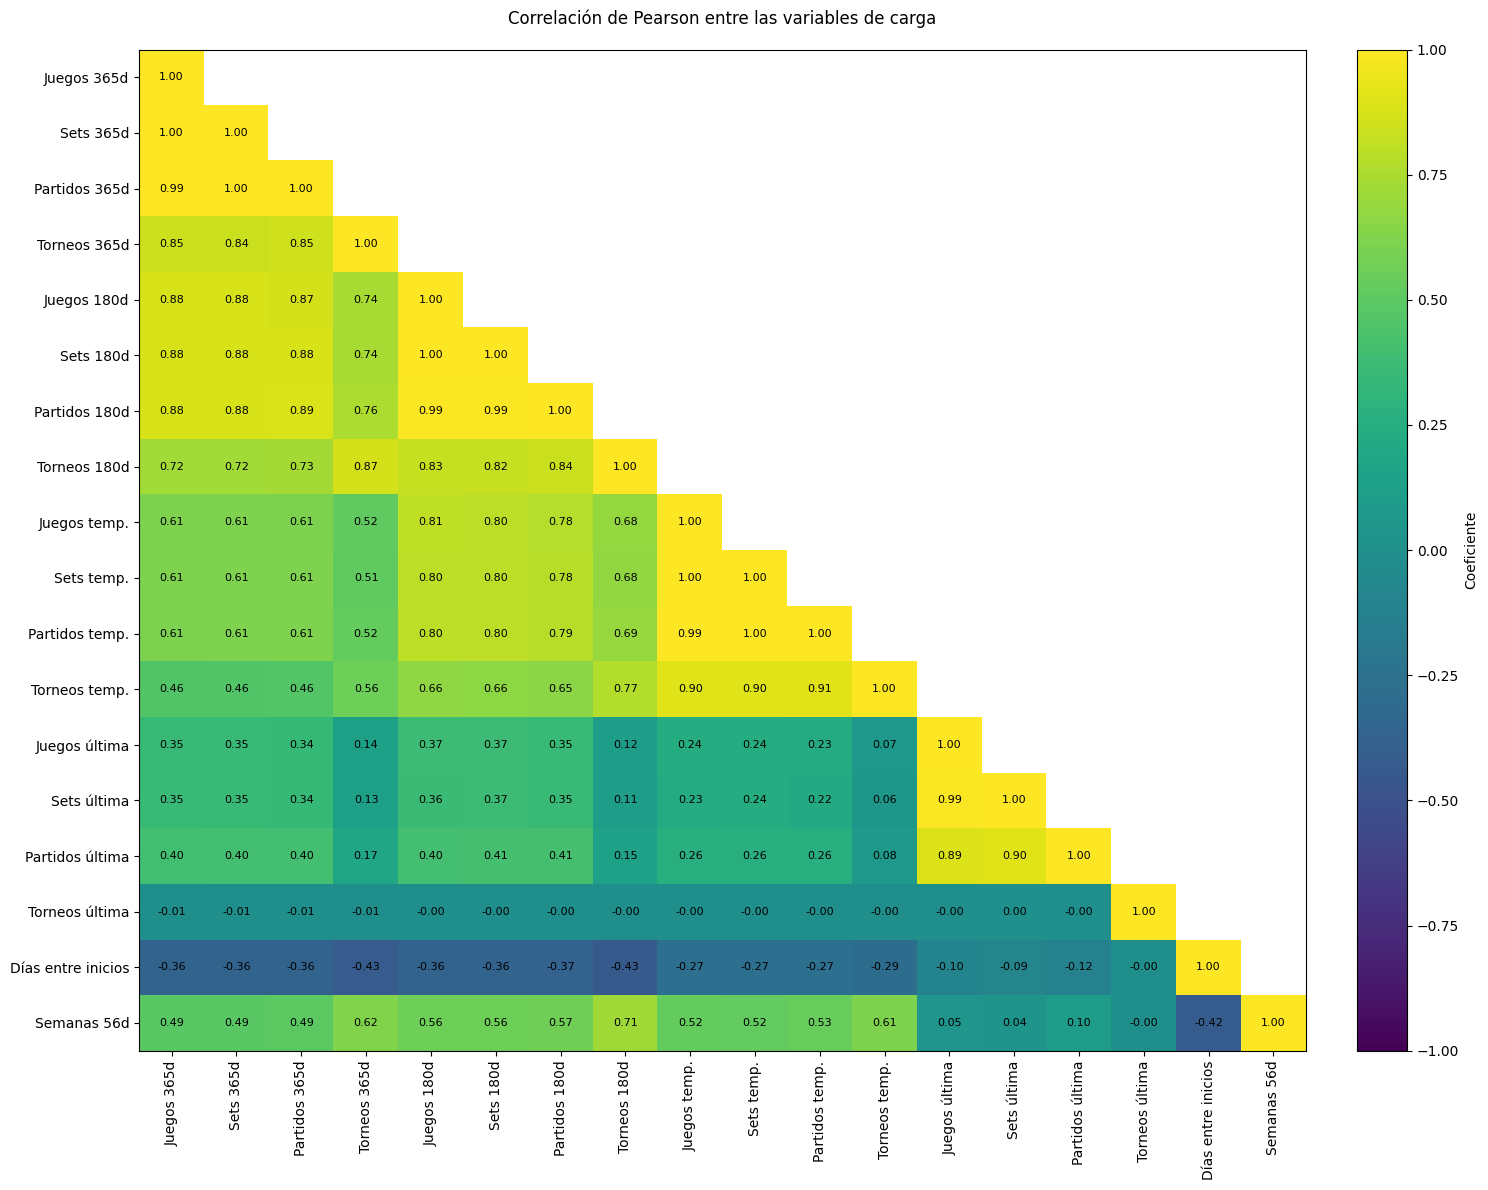

Generando gráfico de Spearman...


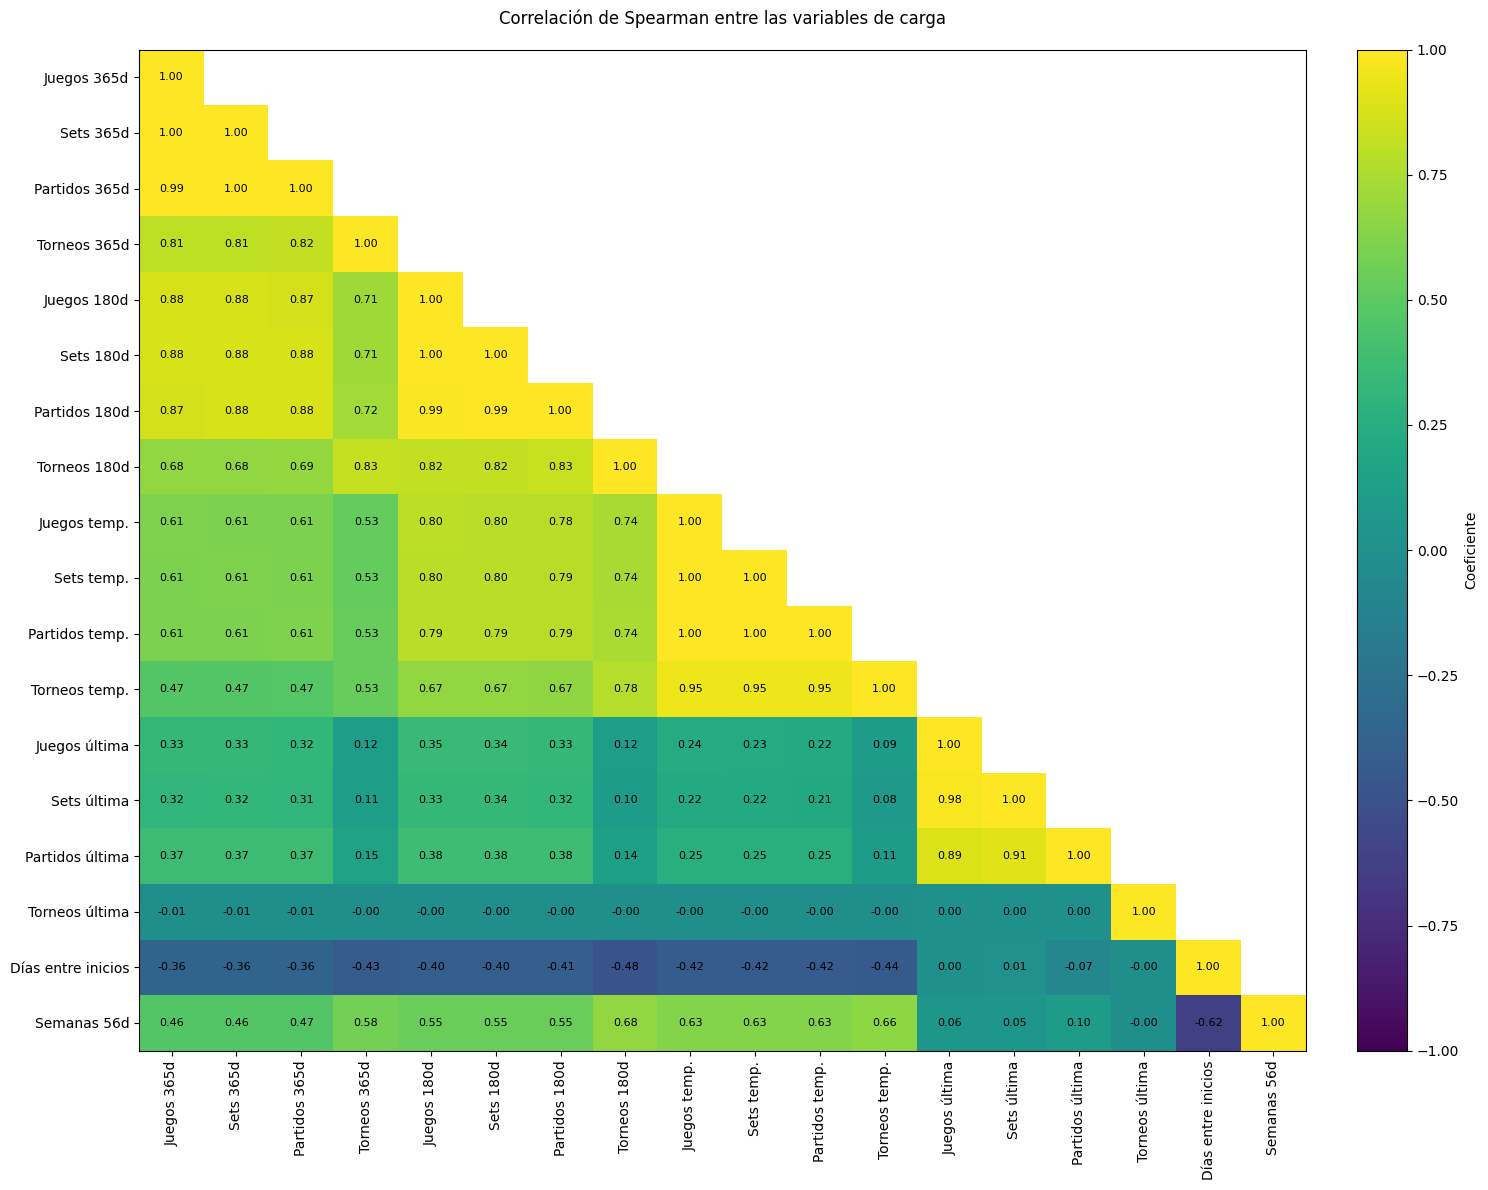

Generando gráfico de Kendall tau-b...


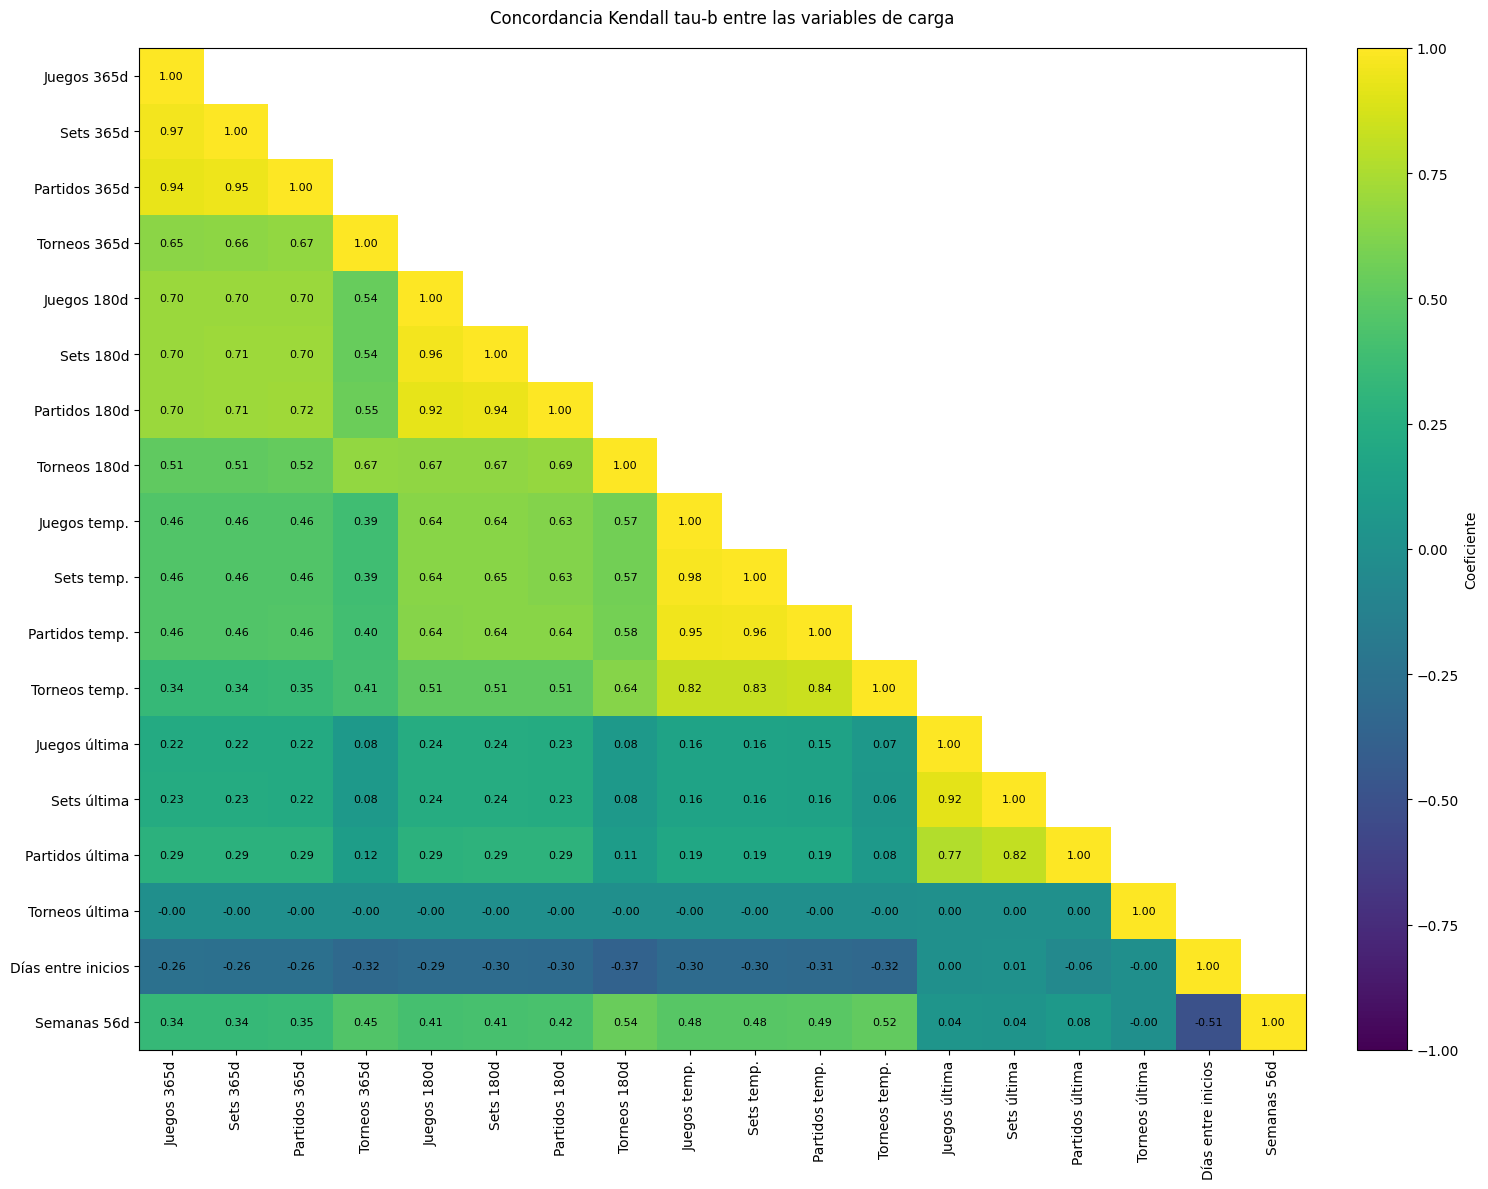

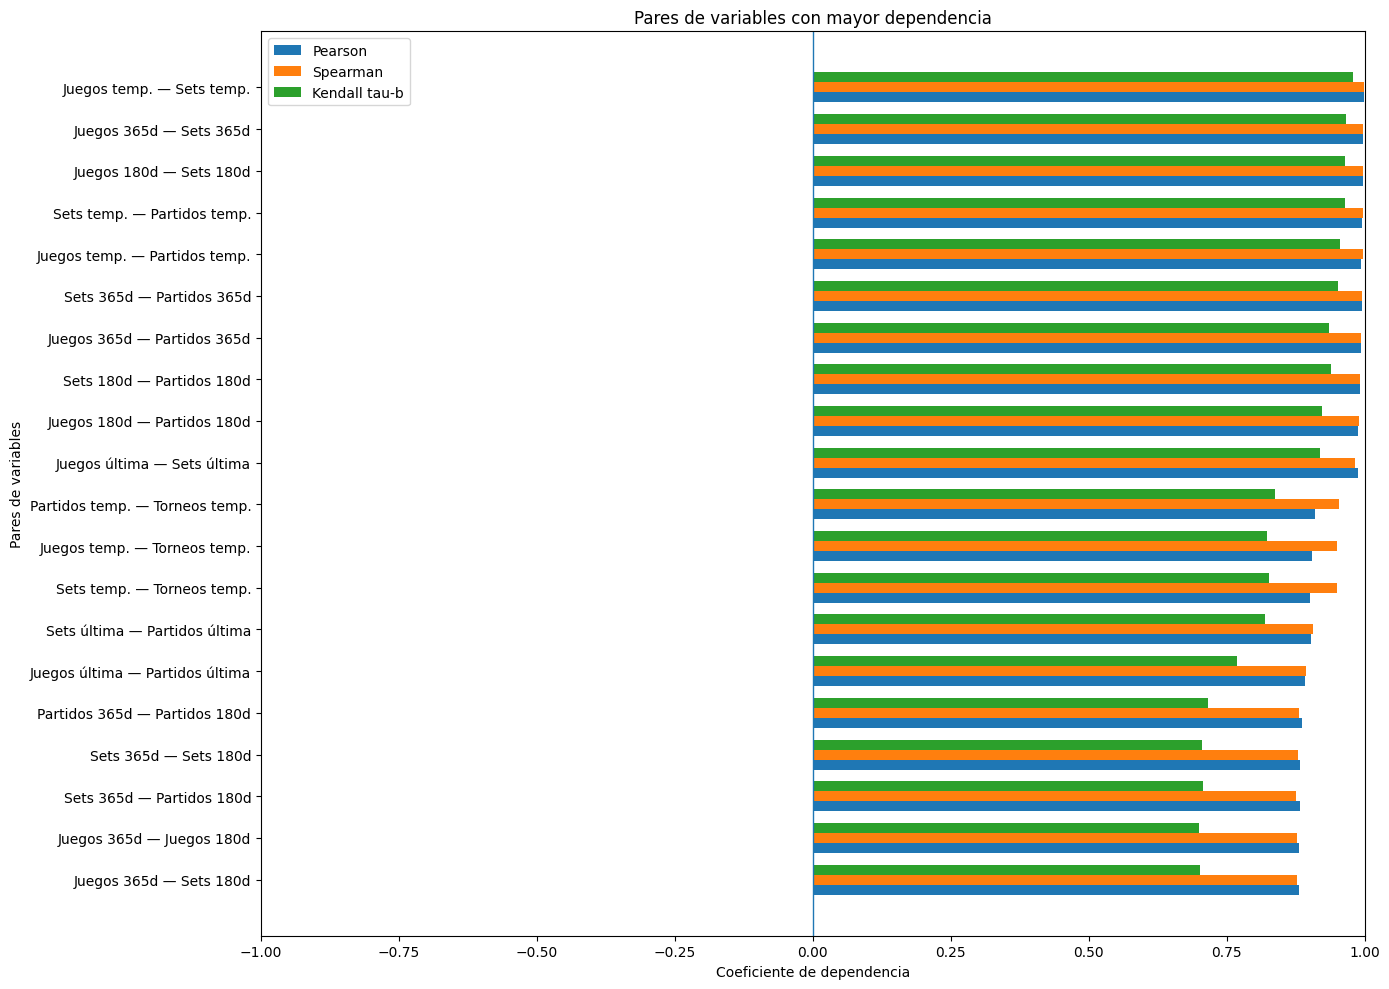

PARES CON MAYOR DEPENDENCIA


,variable_1,variable_2,pearson,spearman,kendall_tau_b,dependencia_maxima
0,juegos_temporada,sets_temporada,0.998,0.999,0.980,0.999
1,juegos_365d,sets_365d,0.998,0.998,0.966,0.998
2,juegos_180d,sets_180d,0.997,0.998,0.965,0.998
3,sets_temporada,partidos_temporada,0.996,0.997,0.964,0.997
4,juegos_temporada,partidos_temporada,0.994,0.996,0.955,0.996
5,sets_365d,partidos_365d,0.996,0.995,0.951,0.996
6,juegos_365d,partidos_365d,0.993,0.993,0.935,0.993
7,sets_180d,partidos_180d,0.991,0.992,0.939,0.992
8,juegos_180d,partidos_180d,0.988,0.989,0.923,0.989
9,juegos_ultima_fecha_competitiva,sets_ultima_fecha_competitiva,0.987,0.983,0.918,0.987


Análisis y visualización completados.


In [12]:

# ============================================================
# 8. DEPENDENCIA ENTRE VARIABLES DE CARGA
# PEARSON, SPEARMAN Y KENDALL TAU-B
# ============================================================

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import kendalltau
from IPython.display import display


# ------------------------------------------------------------
# 1. Variables analizadas
# ------------------------------------------------------------

variables_carga_redundancia = [
    "juegos_365d",
    "sets_365d",
    "partidos_365d",
    "torneos_365d",

    "juegos_180d",
    "sets_180d",
    "partidos_180d",
    "torneos_180d",

    "juegos_temporada",
    "sets_temporada",
    "partidos_temporada",
    "torneos_temporada",

    "juegos_ultima_fecha_competitiva",
    "sets_ultima_fecha_competitiva",
    "partidos_ultima_fecha_competitiva",
    "torneos_ultima_fecha_competitiva",

    "dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d"
]


etiquetas_cortas = {
    "juegos_365d": "Juegos 365d",
    "sets_365d": "Sets 365d",
    "partidos_365d": "Partidos 365d",
    "torneos_365d": "Torneos 365d",

    "juegos_180d": "Juegos 180d",
    "sets_180d": "Sets 180d",
    "partidos_180d": "Partidos 180d",
    "torneos_180d": "Torneos 180d",

    "juegos_temporada": "Juegos temp.",
    "sets_temporada": "Sets temp.",
    "partidos_temporada": "Partidos temp.",
    "torneos_temporada": "Torneos temp.",

    "juegos_ultima_fecha_competitiva": "Juegos última",
    "sets_ultima_fecha_competitiva": "Sets última",
    "partidos_ultima_fecha_competitiva": "Partidos última",
    "torneos_ultima_fecha_competitiva": "Torneos última",

    "dias_entre_inicios_competitivos": "Días entre inicios",
    "semanas_con_competicion_56d": "Semanas 56d"
}


# ------------------------------------------------------------
# 2. Preparación de la muestra común
# ------------------------------------------------------------

datos_dependencia = (
    data_muestra_principal[
        variables_carga_redundancia
    ]
    .astype(float)
    .copy()
)


assert len(datos_dependencia) == len(data_muestra_principal)
assert datos_dependencia.notna().all().all()

print(
    "Muestra preparada:",
    datos_dependencia.shape
)


# ------------------------------------------------------------
# 3. Pearson y Spearman
# ------------------------------------------------------------

print("Calculando matriz de Pearson...")

matriz_pearson = datos_dependencia.corr(
    method="pearson"
)

print("Pearson calculado.")


print("Calculando matriz de Spearman...")

matriz_spearman = datos_dependencia.corr(
    method="spearman"
)

print("Spearman calculado.")


# ------------------------------------------------------------
# 4. Kendall tau-b
# ------------------------------------------------------------

pares_variables = list(
    combinations(
        variables_carga_redundancia,
        2
    )
)

numero_pares = len(pares_variables)

print(
    "Calculando Kendall tau-b para",
    numero_pares,
    "pares..."
)


matriz_kendall = pd.DataFrame(
    np.eye(len(variables_carga_redundancia)),
    index=variables_carga_redundancia,
    columns=variables_carga_redundancia,
    dtype=float
)


for numero, (variable_1, variable_2) in enumerate(
    pares_variables,
    start=1
):

    tau_b = kendalltau(
        datos_dependencia[variable_1],
        datos_dependencia[variable_2],
        variant="b",
        nan_policy="omit"
    ).statistic

    matriz_kendall.loc[
        variable_1,
        variable_2
    ] = tau_b

    matriz_kendall.loc[
        variable_2,
        variable_1
    ] = tau_b

    # Muestro el progreso cada 20 pares.
    if (
        numero % 20 == 0
        or numero == numero_pares
    ):
        print(
            f"Kendall: {numero}/{numero_pares} pares"
        )


print("Kendall tau-b calculado.")


# ------------------------------------------------------------
# 5. Función para representar las matrices
# ------------------------------------------------------------

def graficar_matriz_dependencia(
    matriz,
    titulo,
    umbral_anotacion=0
):
    """
    Representa el triángulo inferior de una matriz.
    Anota la diagonal y los coeficientes con magnitud
    igual o superior al umbral indicado.
    """

    variables = matriz.columns.tolist()

    etiquetas = [
        etiquetas_cortas.get(variable, variable)
        for variable in variables
    ]

    valores = matriz.to_numpy(dtype=float)

    mascara_superior = np.triu(
        np.ones_like(
            valores,
            dtype=bool
        ),
        k=1
    )

    valores_mostrados = np.ma.array(
        valores,
        mask=mascara_superior
    )

    figura, eje = plt.subplots(
        figsize=(15, 12)
    )

    imagen = eje.imshow(
        valores_mostrados,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    eje.set_xticks(
        np.arange(len(etiquetas))
    )

    eje.set_yticks(
        np.arange(len(etiquetas))
    )

    eje.set_xticklabels(
        etiquetas,
        rotation=90
    )

    eje.set_yticklabels(
        etiquetas
    )

    eje.set_title(
        titulo,
        pad=18
    )

    for fila in range(len(variables)):

        for columna in range(fila + 1):

            coeficiente = valores[
                fila,
                columna
            ]

            if (
                fila == columna
                or abs(coeficiente)
                >= umbral_anotacion
            ):
                eje.text(
                    columna,
                    fila,
                    f"{coeficiente:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    barra = figura.colorbar(
        imagen,
        ax=eje,
        fraction=0.046,
        pad=0.04
    )

    barra.set_label(
        "Coeficiente"
    )

    figura.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Mapas de dependencia
# ------------------------------------------------------------

print("Generando gráfico de Pearson...")

graficar_matriz_dependencia(
    matriz_pearson,
    "Correlación de Pearson entre las variables de carga"
)


print("Generando gráfico de Spearman...")

graficar_matriz_dependencia(
    matriz_spearman,
    "Correlación de Spearman entre las variables de carga"
)


print("Generando gráfico de Kendall tau-b...")

graficar_matriz_dependencia(
    matriz_kendall,
    "Concordancia Kendall tau-b entre las variables de carga"
)


# ------------------------------------------------------------
# 7. Tabla conjunta de pares
# ------------------------------------------------------------

resultados_dependencia = []


for variable_1, variable_2 in pares_variables:

    pearson = matriz_pearson.loc[
        variable_1,
        variable_2
    ]

    spearman = matriz_spearman.loc[
        variable_1,
        variable_2
    ]

    kendall = matriz_kendall.loc[
        variable_1,
        variable_2
    ]

    resultados_dependencia.append(
        {
            "variable_1": variable_1,
            "variable_2": variable_2,
            "pearson": pearson,
            "spearman": spearman,
            "kendall_tau_b": kendall,
            "dependencia_maxima": max(
                abs(pearson),
                abs(spearman),
                abs(kendall)
            )
        }
    )


tabla_dependencia = (
    pd.DataFrame(resultados_dependencia)
    .sort_values(
        "dependencia_maxima",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Gráfico de los 20 pares más dependientes
# ------------------------------------------------------------

pares_top = (
    tabla_dependencia
    .head(20)
    .copy()
)


pares_top["par_variables"] = (
    pares_top["variable_1"]
    .map(etiquetas_cortas)
    + " — "
    + pares_top["variable_2"]
    .map(etiquetas_cortas)
)


pares_top = (
    pares_top
    .sort_values(
        "dependencia_maxima",
        ascending=True
    )
    .reset_index(drop=True)
)


posiciones = np.arange(
    len(pares_top)
)

altura = 0.24


figura, eje = plt.subplots(
    figsize=(14, 10)
)


eje.barh(
    posiciones - altura,
    pares_top["pearson"],
    height=altura,
    label="Pearson"
)

eje.barh(
    posiciones,
    pares_top["spearman"],
    height=altura,
    label="Spearman"
)

eje.barh(
    posiciones + altura,
    pares_top["kendall_tau_b"],
    height=altura,
    label="Kendall tau-b"
)


eje.set_yticks(
    posiciones
)

eje.set_yticklabels(
    pares_top["par_variables"]
)

eje.set_xlim(
    -1,
    1
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_xlabel(
    "Coeficiente de dependencia"
)

eje.set_ylabel(
    "Pares de variables"
)

eje.set_title(
    "Pares de variables con mayor dependencia"
)

eje.legend()

figura.tight_layout()
plt.show()


print("PARES CON MAYOR DEPENDENCIA")

display(
    tabla_dependencia
    .head(20)
    .style.format(
        {
            "pearson": "{:.3f}",
            "spearman": "{:.3f}",
            "kendall_tau_b": "{:.3f}",
            "dependencia_maxima": "{:.3f}"
        }
    )
)


print(
    "Análisis y visualización completados."
)



## 8.2. Agrupación jerárquica de las variables de carga

Las correlaciones por pares permiten identificar asociaciones concretas, pero no muestran directamente la estructura global formada por todas las variables.

Para complementar el análisis se aplicará una agrupación jerárquica basada en la correlación de Spearman. La distancia entre dos variables se definirá como:

$$
d(X,Y)
=
1-
\left|
\rho_s(X,Y)
\right|.
$$

El valor absoluto permite considerar como próximas tanto las asociaciones positivas como las negativas de elevada magnitud, ya que ambas pueden representar información redundante.

La agrupación se realizará mediante enlace promedio. El resultado se representará mediante un dendrograma y una matriz de Spearman reordenada según la estructura obtenida.

Este procedimiento no eliminará variables automáticamente. Su finalidad será comprobar si las medidas se organizan en familias coherentes y respaldar la posterior selección de una variable representativa de cada dimensión.


Coeficiente de correlación cofenética: 0.957


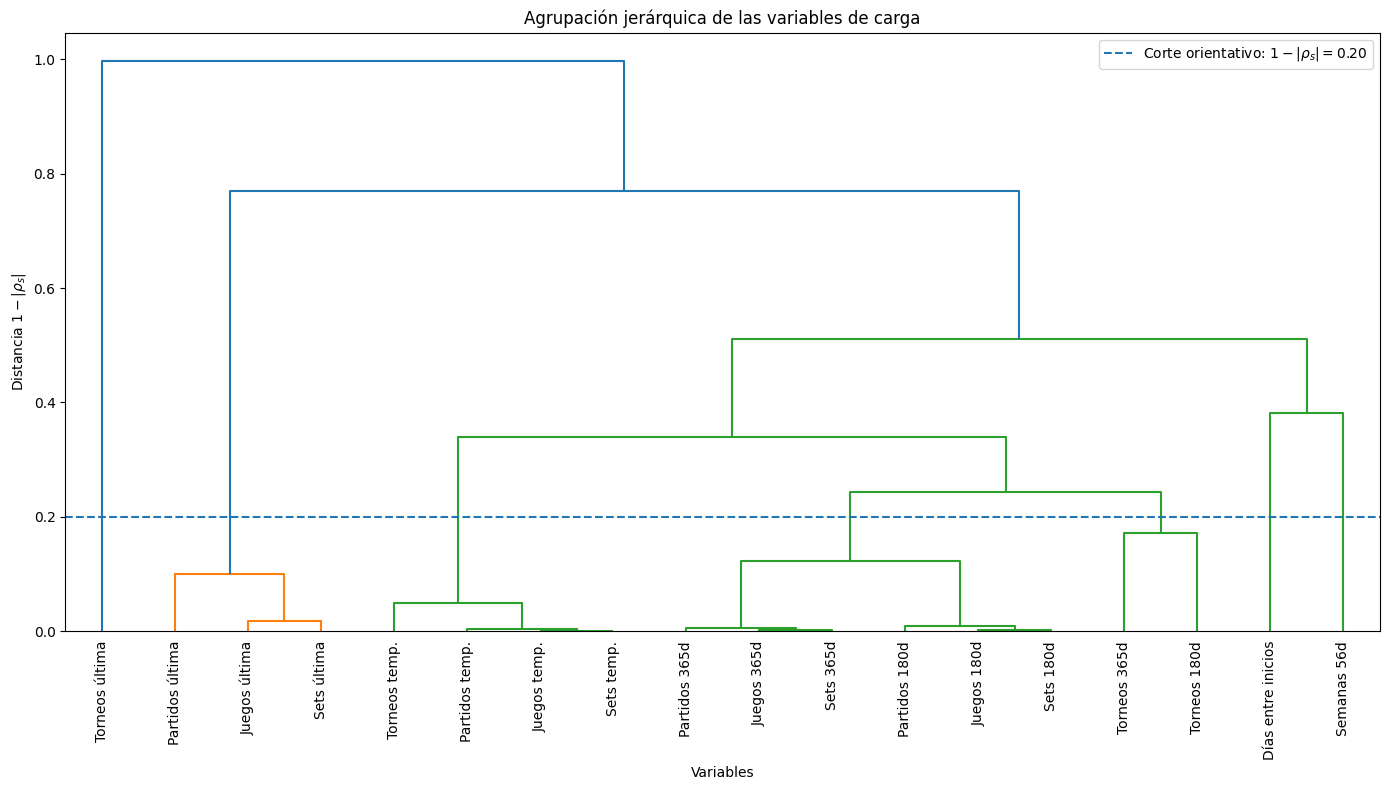

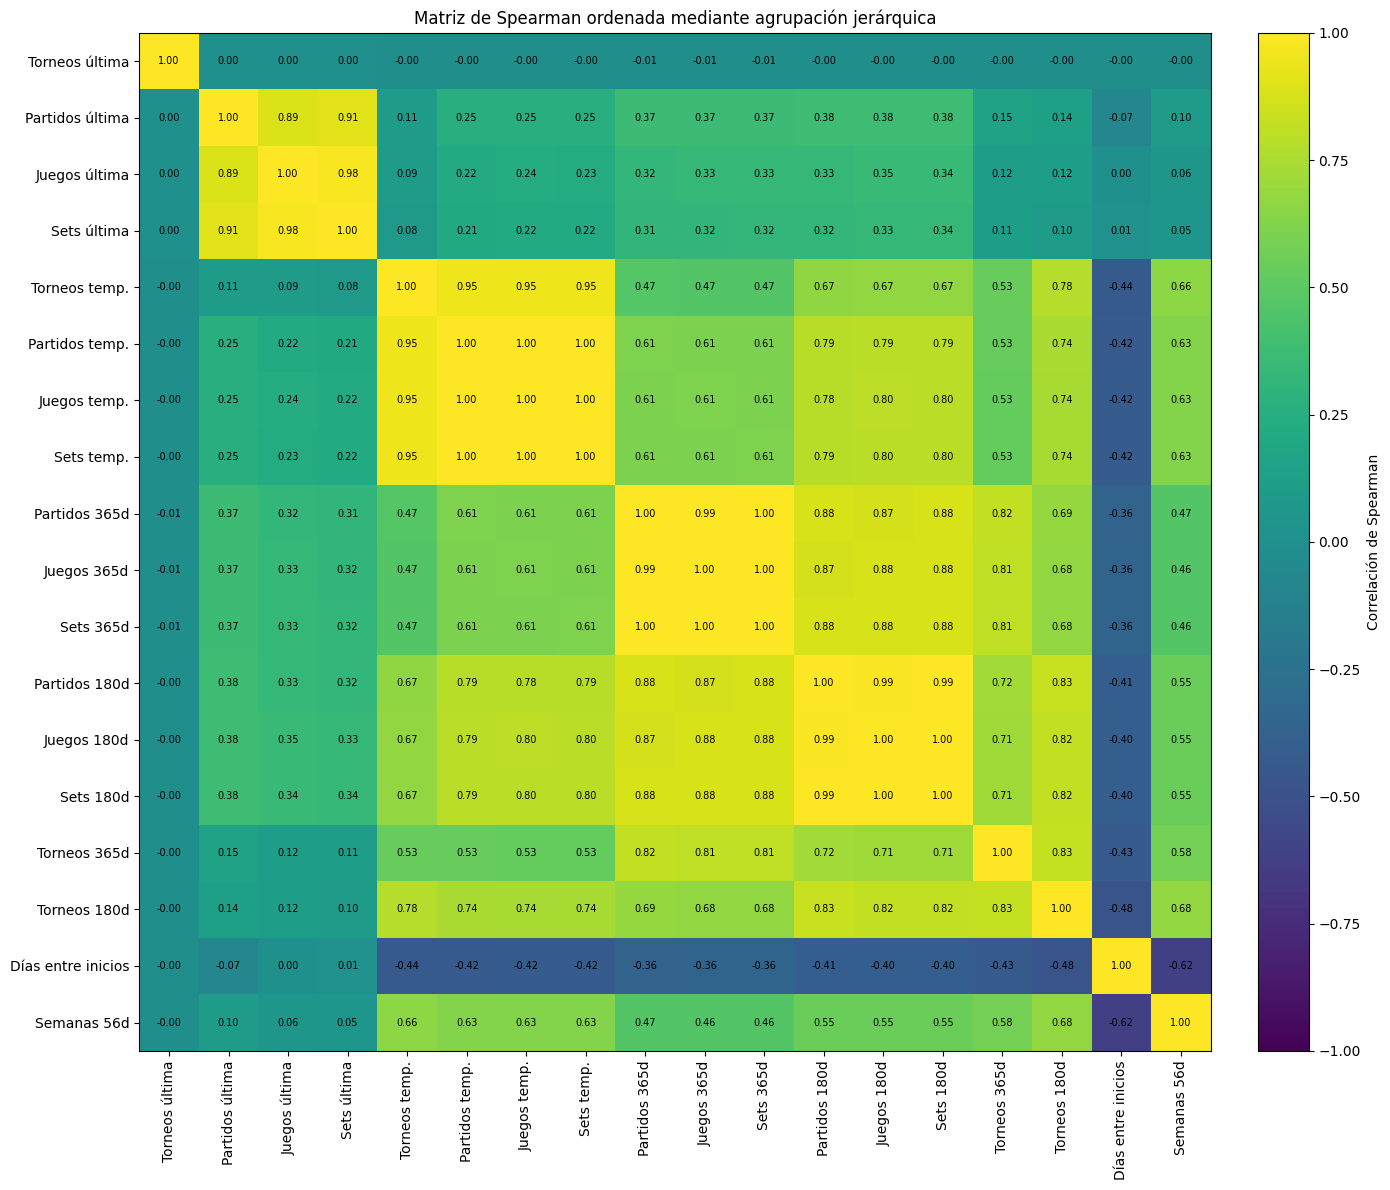

,variable,etiqueta,grupo
0,juegos_ultima_fecha_competitiva,Juegos última,1
1,partidos_ultima_fecha_competitiva,Partidos última,1
2,sets_ultima_fecha_competitiva,Sets última,1
3,juegos_temporada,Juegos temp.,2
4,partidos_temporada,Partidos temp.,2
5,sets_temporada,Sets temp.,2
6,torneos_temporada,Torneos temp.,2
7,juegos_180d,Juegos 180d,3
8,juegos_365d,Juegos 365d,3
9,partidos_180d,Partidos 180d,3


Número de grupos obtenidos con el corte: 7
Agrupación jerárquica completada correctamente.


In [13]:

# ============================================================
# 8.2. AGRUPACIÓN JERÁRQUICA DE LAS VARIABLES DE CARGA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    cophenet,
    fcluster
)

from scipy.spatial.distance import squareform


# ------------------------------------------------------------
# 1. Matriz de distancia basada en Spearman
# ------------------------------------------------------------

# La redundancia se estudia mediante la magnitud absoluta
# de la asociación monótona.
matriz_distancia_spearman = (
    1
    - matriz_spearman.abs()
)


# La diagonal debe ser exactamente cero.
np.fill_diagonal(
    matriz_distancia_spearman.values,
    0
)


# Corrijo posibles errores numéricos mínimos.
matriz_distancia_spearman = (
    matriz_distancia_spearman
    .clip(
        lower=0,
        upper=1
    )
)


assert np.allclose(
    matriz_distancia_spearman.values,
    matriz_distancia_spearman.values.T
)

assert np.allclose(
    np.diag(matriz_distancia_spearman),
    0
)


# ------------------------------------------------------------
# 2. Conversión al formato condensado
# ------------------------------------------------------------

distancias_condensadas = squareform(
    matriz_distancia_spearman.values,
    checks=True
)


# ------------------------------------------------------------
# 3. Agrupación jerárquica mediante enlace promedio
# ------------------------------------------------------------

matriz_linkage = linkage(
    distancias_condensadas,
    method="average"
)


# Correlación cofenética:
# evalúa cuánto conserva el dendrograma las distancias originales.
coeficiente_cofenetico, _ = cophenet(
    matriz_linkage,
    distancias_condensadas
)


print(
    "Coeficiente de correlación cofenética:",
    round(coeficiente_cofenetico, 3)
)


# ------------------------------------------------------------
# 4. Dendrograma
# ------------------------------------------------------------

etiquetas_variables = [
    etiquetas_cortas.get(variable, variable)
    for variable in matriz_spearman.columns
]


figura, eje = plt.subplots(
    figsize=(14, 8)
)


resultado_dendrograma = dendrogram(
    matriz_linkage,
    labels=etiquetas_variables,
    leaf_rotation=90,
    leaf_font_size=10,
    ax=eje
)


eje.set_title(
    "Agrupación jerárquica de las variables de carga"
)

eje.set_xlabel(
    "Variables"
)

eje.set_ylabel(
    r"Distancia $1-|\rho_s|$"
)

eje.axhline(
    y=0.20,
    linestyle="--",
    linewidth=1.5,
    label=r"Corte orientativo: $1-|\rho_s|=0.20$"
)

eje.legend()

figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Orden de las variables según el dendrograma
# ------------------------------------------------------------

orden_hojas = (
    resultado_dendrograma["leaves"]
)


variables_ordenadas = [
    matriz_spearman.columns[indice]
    for indice in orden_hojas
]


matriz_spearman_ordenada = (
    matriz_spearman
    .loc[
        variables_ordenadas,
        variables_ordenadas
    ]
)


etiquetas_ordenadas = [
    etiquetas_cortas.get(variable, variable)
    for variable in variables_ordenadas
]


# ------------------------------------------------------------
# 6. Matriz de Spearman reordenada
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(14, 12)
)


imagen = eje.imshow(
    matriz_spearman_ordenada.to_numpy(),
    vmin=-1,
    vmax=1,
    aspect="auto"
)


eje.set_xticks(
    np.arange(len(etiquetas_ordenadas))
)

eje.set_yticks(
    np.arange(len(etiquetas_ordenadas))
)

eje.set_xticklabels(
    etiquetas_ordenadas,
    rotation=90
)

eje.set_yticklabels(
    etiquetas_ordenadas
)


for fila in range(len(etiquetas_ordenadas)):

    for columna in range(len(etiquetas_ordenadas)):

        coeficiente = (
            matriz_spearman_ordenada
            .iloc[fila, columna]
        )

        eje.text(
            columna,
            fila,
            f"{coeficiente:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )


eje.set_title(
    "Matriz de Spearman ordenada mediante agrupación jerárquica"
)


barra = figura.colorbar(
    imagen,
    ax=eje,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Correlación de Spearman"
)


figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Obtención de grupos mediante un corte orientativo
# ------------------------------------------------------------

umbral_distancia = 0.20


identificadores_grupo = fcluster(
    matriz_linkage,
    t=umbral_distancia,
    criterion="distance"
)


tabla_grupos_variables = pd.DataFrame(
    {
        "variable": matriz_spearman.columns,
        "etiqueta": [
            etiquetas_cortas.get(variable, variable)
            for variable in matriz_spearman.columns
        ],
        "grupo": identificadores_grupo
    }
)


tabla_grupos_variables = (
    tabla_grupos_variables
    .sort_values(
        [
            "grupo",
            "variable"
        ]
    )
    .reset_index(drop=True)
)


display(tabla_grupos_variables)


print(
    "Número de grupos obtenidos con el corte:",
    tabla_grupos_variables["grupo"].nunique()
)

print(
    "Agrupación jerárquica completada correctamente."
)



### Visualización del dendrograma para la memoria

A partir de la matriz de Spearman y de la agrupación jerárquica calculadas en el bloque anterior, se genera una representación específica para su incorporación a la memoria del TFG.

La figura reutiliza exactamente la estructura jerárquica obtenida mediante la distancia

$$
d(X,Y)=1-\left|\rho_s(X,Y)\right|
$$

y enlace promedio (`average linkage`), sin recalcular ni modificar el análisis original.

Se representan las 18 variables consideradas en el estudio de redundancia, ya que el objetivo del dendrograma es mostrar las familias de variables que justificaron posteriormente la selección de medidas representativas. Se mantiene además el corte orientativo de distancia $0.20$, utilizado únicamente como apoyo para interpretar agrupaciones con una asociación de Spearman elevada en valor absoluto.

El dendrograma se presenta horizontalmente para mejorar la legibilidad de las etiquetas en la memoria.

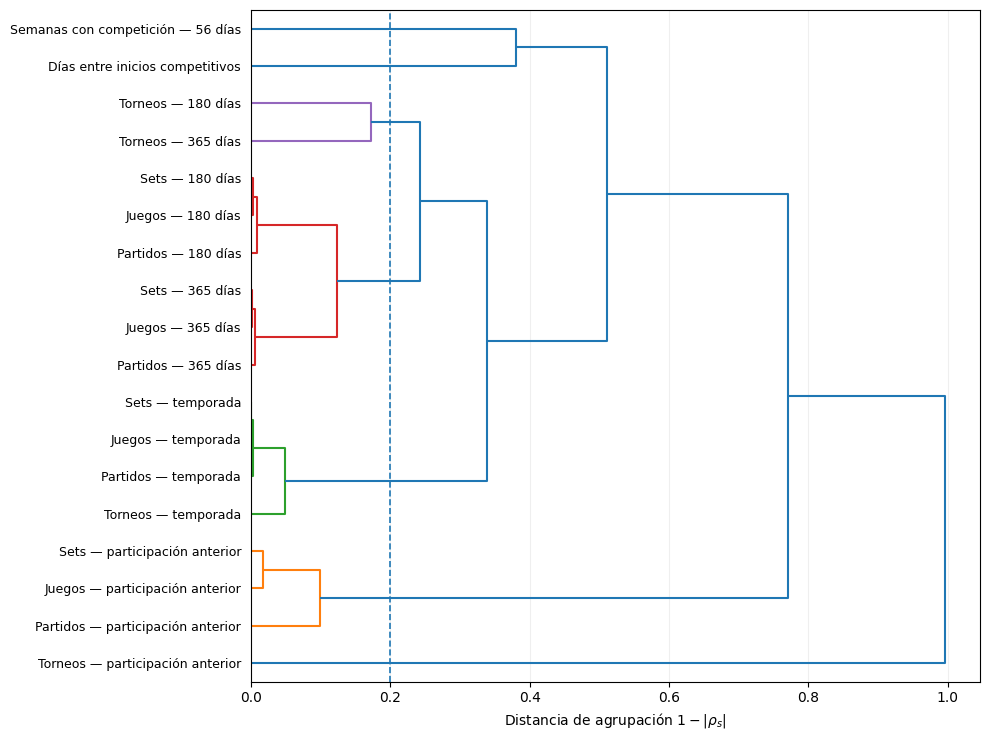

In [14]:
# ============================================================
# FIGURA PARA LA MEMORIA — DENDROGRAMA DE VARIABLES DE CARGA
# ============================================================

etiquetas_dendrograma = {
    "juegos_365d": "Juegos — 365 días",
    "sets_365d": "Sets — 365 días",
    "partidos_365d": "Partidos — 365 días",
    "torneos_365d": "Torneos — 365 días",

    "juegos_180d": "Juegos — 180 días",
    "sets_180d": "Sets — 180 días",
    "partidos_180d": "Partidos — 180 días",
    "torneos_180d": "Torneos — 180 días",

    "juegos_temporada": "Juegos — temporada",
    "sets_temporada": "Sets — temporada",
    "partidos_temporada": "Partidos — temporada",
    "torneos_temporada": "Torneos — temporada",

    "juegos_ultima_fecha_competitiva": "Juegos — participación anterior",
    "sets_ultima_fecha_competitiva": "Sets — participación anterior",
    "partidos_ultima_fecha_competitiva": "Partidos — participación anterior",
    "torneos_ultima_fecha_competitiva": "Torneos — participación anterior",

    "dias_entre_inicios_competitivos": "Días entre inicios competitivos",
    "semanas_con_competicion_56d": "Semanas con competición — 56 días"
}

etiquetas_figura = [
    etiquetas_dendrograma[variable]
    for variable in matriz_spearman.columns
]

figura_dendrograma, eje = plt.subplots(
    figsize=(10, 7.5)
)

dendrogram(
    matriz_linkage,
    labels=etiquetas_figura,
    orientation="right",
    leaf_font_size=9,
    color_threshold=0.20,
    ax=eje
)

eje.axvline(
    x=0.20,
    linestyle="--",
    linewidth=1.2
)

eje.set_xlabel(
    r"Distancia de agrupación $1-|\rho_s|$"

)

eje.set_ylabel("")

eje.grid(
    axis="x",
    alpha=0.2
)

figura_dendrograma.tight_layout()

plt.show()

## 8.3. Relación entre la carga de temporada y el avance del calendario

Las variables acumuladas durante la temporada aumentan necesariamente conforme transcurre el año competitivo. Por tanto, `juegos_temporada` puede representar simultáneamente:

$$
\text{actividad competitiva del jugador}
+
\text{momento de la temporada}.
$$

Antes de mantener esta variable como candidata, se analizará su relación con los días transcurridos desde el comienzo observable de cada temporada.

El análisis se realizará a nivel jugador–torneo para evitar que un mismo valor de carga quede repetido tantas veces como partidos dispute el jugador dentro del torneo.

Se estudiarán:

* las correlaciones de Pearson, Spearman y Kendall tau-b;
* la estabilidad de la relación en cada temporada;
* la evolución de la media y la mediana por periodos de 30 días;
* la proporción de cargas iguales a cero a medida que avanza la temporada.

Una asociación elevada no implicará que la variable sea inútil, pero obligará a controlar el momento del calendario para evitar interpretar como carga una variación puramente temporal.


Observaciones jugador–torneo: 40579
Rango de días desde el comienzo de temporada: 0 - 334
RELACIÓN GLOBAL ENTRE EL AVANCE DE LA TEMPORADA Y LOS JUEGOS ACUMULADOS


,medida,coeficiente
0,Pearson,0.668
1,Spearman,0.654
2,Kendall tau-b,0.505


,match_year,observaciones,spearman_dias_juegos_temporada
0,2009,3282,0.635
1,2010,3212,0.650
2,2011,3191,0.636
3,2012,3183,0.686
4,2013,3112,0.676
5,2014,3071,0.682
6,2015,3116,0.636
7,2016,3089,0.650
8,2017,3059,0.683
9,2018,3059,0.725


,periodo_30d,observaciones,dias_medianos,media_juegos,mediana_juegos,percentil_25,percentil_75,porcentaje_ceros
0,1,"4,204",14,33.28,8.00,0.00,55.00,49.88%
1,2,"5,175",42,127.30,120.00,25.00,202.00,22.80%
2,3,"3,505",67,215.84,228.00,59.00,332.00,19.63%
3,4,"4,194",105,298.09,314.00,115.00,449.00,8.75%
4,5,"3,802",140,427.21,449.00,257.00,597.00,5.23%
5,6,"3,252",168,502.54,521.00,277.75,721.00,4.31%
6,7,"4,129",196,448.78,432.00,92.00,744.00,9.91%
7,8,"4,723",224,729.68,777.00,438.00,1018.00,2.65%
8,9,"2,896",259,578.46,520.00,74.00,1007.25,12.36%
9,10,"3,460",287,963.27,1047.00,655.75,1310.00,2.40%


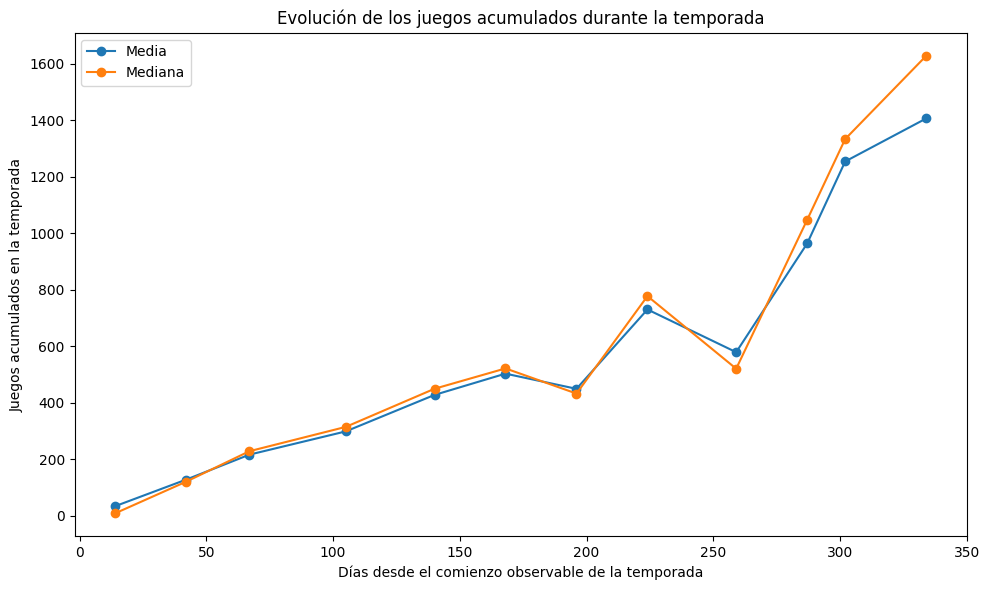

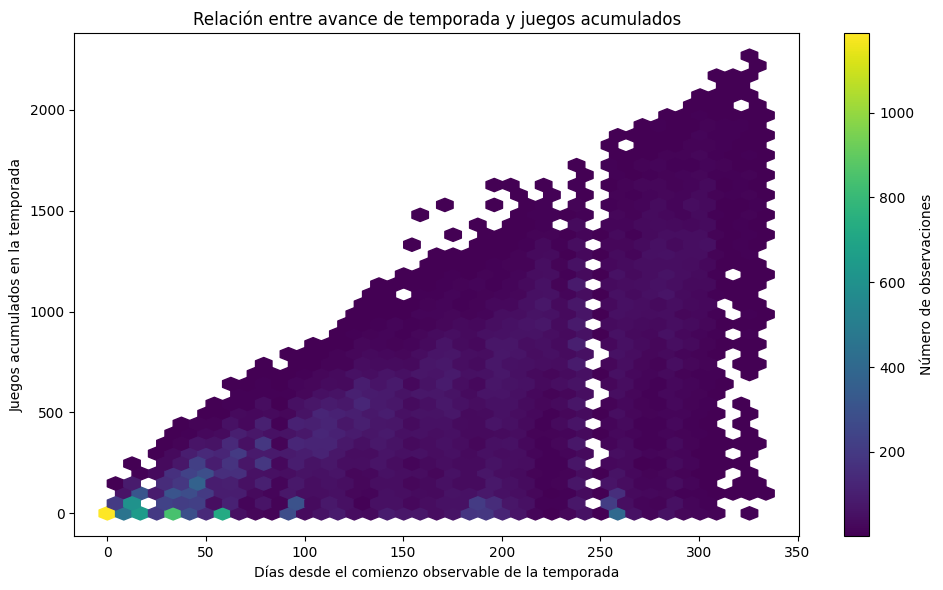

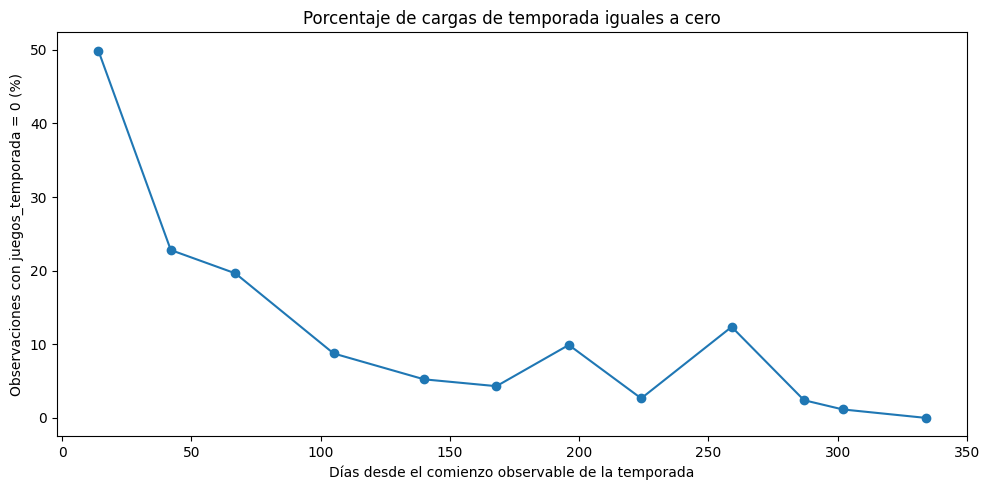

Análisis de la dependencia respecto al calendario completado.


In [15]:

# ============================================================
# 8.3. CARGA DE TEMPORADA Y AVANCE DEL CALENDARIO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau
)


# ------------------------------------------------------------
# 1. Preparación a nivel jugador–torneo
# ------------------------------------------------------------

analisis_temporada = (
    data_jugador_torneo[
        [
            "jugador_id",
            "identificador_torneo",
            "match_year",
            "fecha_torneo",
            "juegos_temporada"
        ]
    ]
    .copy()
)


assert not analisis_temporada.duplicated(
    subset=[
        "jugador_id",
        "identificador_torneo"
    ]
).any()


# Primera fecha observable de cada temporada deportiva.
analisis_temporada[
    "fecha_inicio_temporada_observada"
] = (
    analisis_temporada
    .groupby("match_year")["fecha_torneo"]
    .transform("min")
)


# Número de días transcurridos desde el comienzo
# observable de la temporada correspondiente.
analisis_temporada[
    "dias_desde_inicio_temporada"
] = (
    analisis_temporada["fecha_torneo"]
    - analisis_temporada[
        "fecha_inicio_temporada_observada"
    ]
).dt.days


assert analisis_temporada[
    "dias_desde_inicio_temporada"
].ge(0).all()


# Periodos consecutivos de aproximadamente 30 días.
analisis_temporada["periodo_30d"] = (
    analisis_temporada[
        "dias_desde_inicio_temporada"
    ]
    // 30
    + 1
).astype(int)


print(
    "Observaciones jugador–torneo:",
    len(analisis_temporada)
)

print(
    "Rango de días desde el comienzo de temporada:",
    analisis_temporada[
        "dias_desde_inicio_temporada"
    ].min(),
    "-",
    analisis_temporada[
        "dias_desde_inicio_temporada"
    ].max()
)


# ------------------------------------------------------------
# 2. Correlaciones globales
# ------------------------------------------------------------

x = analisis_temporada[
    "dias_desde_inicio_temporada"
].astype(float)

y = analisis_temporada[
    "juegos_temporada"
].astype(float)


correlaciones_calendario = pd.DataFrame(
    {
        "medida": [
            "Pearson",
            "Spearman",
            "Kendall tau-b"
        ],
        "coeficiente": [
            pearsonr(x, y).statistic,
            spearmanr(x, y).statistic,
            kendalltau(
                x,
                y,
                variant="b"
            ).statistic
        ]
    }
)


print(
    "RELACIÓN GLOBAL ENTRE EL AVANCE DE LA TEMPORADA "
    "Y LOS JUEGOS ACUMULADOS"
)

display(
    correlaciones_calendario.style.format(
        {
            "coeficiente": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 3. Correlación de Spearman por temporada
# ------------------------------------------------------------

resultados_por_ano = []


for ano, grupo in analisis_temporada.groupby(
    "match_year"
):

    correlacion = spearmanr(
        grupo["dias_desde_inicio_temporada"],
        grupo["juegos_temporada"]
    ).statistic

    resultados_por_ano.append(
        {
            "match_year": ano,
            "observaciones": len(grupo),
            "spearman_dias_juegos_temporada": correlacion
        }
    )


correlacion_por_ano = pd.DataFrame(
    resultados_por_ano
)


display(
    correlacion_por_ano.style.format(
        {
            "spearman_dias_juegos_temporada": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 4. Resumen por periodos de 30 días
# ------------------------------------------------------------

resumen_periodos_temporada = (
    analisis_temporada
    .groupby(
        "periodo_30d",
        as_index=False
    )
    .agg(
        observaciones=(
            "juegos_temporada",
            "size"
        ),
        dias_medianos=(
            "dias_desde_inicio_temporada",
            "median"
        ),
        media_juegos=(
            "juegos_temporada",
            "mean"
        ),
        mediana_juegos=(
            "juegos_temporada",
            "median"
        ),
        percentil_25=(
            "juegos_temporada",
            lambda serie: serie.quantile(0.25)
        ),
        percentil_75=(
            "juegos_temporada",
            lambda serie: serie.quantile(0.75)
        ),
        porcentaje_ceros=(
            "juegos_temporada",
            lambda serie: serie.eq(0).mean() * 100
        )
    )
)


display(
    resumen_periodos_temporada.style.format(
        {
            "observaciones": "{:,.0f}",
            "dias_medianos": "{:.0f}",
            "media_juegos": "{:.2f}",
            "mediana_juegos": "{:.2f}",
            "percentil_25": "{:.2f}",
            "percentil_75": "{:.2f}",
            "porcentaje_ceros": "{:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# 5. Evolución de la media y la mediana
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(10, 6)
)


eje.plot(
    resumen_periodos_temporada["dias_medianos"],
    resumen_periodos_temporada["media_juegos"],
    marker="o",
    label="Media"
)

eje.plot(
    resumen_periodos_temporada["dias_medianos"],
    resumen_periodos_temporada["mediana_juegos"],
    marker="o",
    label="Mediana"
)


eje.set_title(
    "Evolución de los juegos acumulados "
    "durante la temporada"
)

eje.set_xlabel(
    "Días desde el comienzo observable de la temporada"
)

eje.set_ylabel(
    "Juegos acumulados en la temporada"
)

eje.legend()

figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Distribución conjunta mediante hexágonos
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(10, 6)
)


grafico_hexagonal = eje.hexbin(
    analisis_temporada[
        "dias_desde_inicio_temporada"
    ],
    analisis_temporada[
        "juegos_temporada"
    ],
    gridsize=40,
    mincnt=1
)


eje.set_title(
    "Relación entre avance de temporada "
    "y juegos acumulados"
)

eje.set_xlabel(
    "Días desde el comienzo observable de la temporada"
)

eje.set_ylabel(
    "Juegos acumulados en la temporada"
)


barra = figura.colorbar(
    grafico_hexagonal,
    ax=eje
)

barra.set_label(
    "Número de observaciones"
)


figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Evolución del porcentaje de ceros
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(10, 5)
)


eje.plot(
    resumen_periodos_temporada["dias_medianos"],
    resumen_periodos_temporada["porcentaje_ceros"],
    marker="o"
)


eje.set_title(
    "Porcentaje de cargas de temporada iguales a cero"
)

eje.set_xlabel(
    "Días desde el comienzo observable de la temporada"
)

eje.set_ylabel(
    "Observaciones con juegos_temporada = 0 (%)"
)


figura.tight_layout()
plt.show()


print(
    "Análisis de la dependencia respecto "
    "al calendario completado."
)



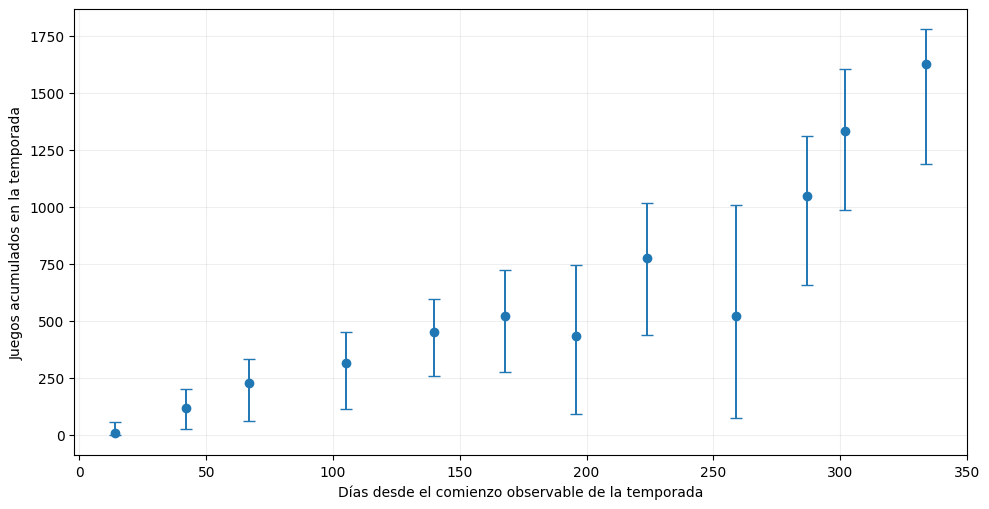

In [16]:
# ============================================================
# FIGURA PARA LA MEMORIA
# CARGA ESTACIONAL SEGÚN EL AVANCE DEL CALENDARIO
# ============================================================

figura, eje = plt.subplots(
    figsize=(10, 5.2)
)


# Distancias desde la mediana hasta P25 y P75
error_inferior = (
    resumen_periodos_temporada["mediana_juegos"]
    - resumen_periodos_temporada["percentil_25"]
)

error_superior = (
    resumen_periodos_temporada["percentil_75"]
    - resumen_periodos_temporada["mediana_juegos"]
)


# Mediana e intervalo intercuartílico de cada periodo
eje.errorbar(
    resumen_periodos_temporada["dias_medianos"],
    resumen_periodos_temporada["mediana_juegos"],
    yerr=[
        error_inferior,
        error_superior
    ],
    fmt="o",
    capsize=4,
    linewidth=1.4
)


eje.set_xlabel(
    "Días desde el comienzo observable de la temporada"
)

eje.set_ylabel(
    "Juegos acumulados en la temporada"
)

eje.grid(
    axis="both",
    alpha=0.20
)

eje.set_axisbelow(True)

figura.tight_layout()

plt.show()

## 8.4. Dependencia no lineal mediante información mutua

Las correlaciones de Pearson, Spearman y Kendall permiten estudiar asociaciones lineales, monótonas y de concordancia. Sin embargo, pueden no detectar adecuadamente relaciones más complejas.

Para complementar estos resultados se utilizará la información mutua, que cuantifica la información compartida entre dos variables sin imponer una forma funcional concreta.

El análisis se realizará sobre las variables provisionalmente representativas de cada dimensión de carga:

* volumen anual;
* frecuencia anual de torneos;
* carga acumulada durante la temporada;
* carga de la última participación;
* separación entre participaciones;
* densidad competitiva reciente.

Se calcularán dos medidas:

1. **Información mutua estimada mediante vecinos próximos**, adecuada para variables numéricas y capaz de detectar relaciones no lineales.
2. **Información mutua ajustada**, calculada después de discretizar las variables y corregida por la dependencia que podría aparecer por azar.

La información mutua no proporciona la dirección de la relación. Por tanto, no distingue entre asociaciones positivas y negativas. Sus resultados deberán interpretarse conjuntamente con Pearson, Spearman y Kendall.

No se utilizará un umbral automático de eliminación. El objetivo es comprobar si existen dependencias importantes que no hayan sido detectadas por las correlaciones anteriores.


Muestra utilizada: (74553, 6)


,variable,valores_unicos,tratamiento
0,juegos_365d,2270,Continua
1,torneos_365d,36,Discreta
2,juegos_temporada,1915,Continua
3,juegos_ultima_fecha_competitiva,270,Continua
4,log_dias_entre_inicios_competitivos,638,Continua
5,semanas_con_competicion_56d,8,Discreta


Calculando información mutua para 15 pares...
Par 1/15 completado
Par 2/15 completado
Par 3/15 completado
Par 4/15 completado
Par 5/15 completado
Par 6/15 completado
Par 7/15 completado
Par 8/15 completado
Par 9/15 completado
Par 10/15 completado
Par 11/15 completado
Par 12/15 completado
Par 13/15 completado
Par 14/15 completado
Par 15/15 completado


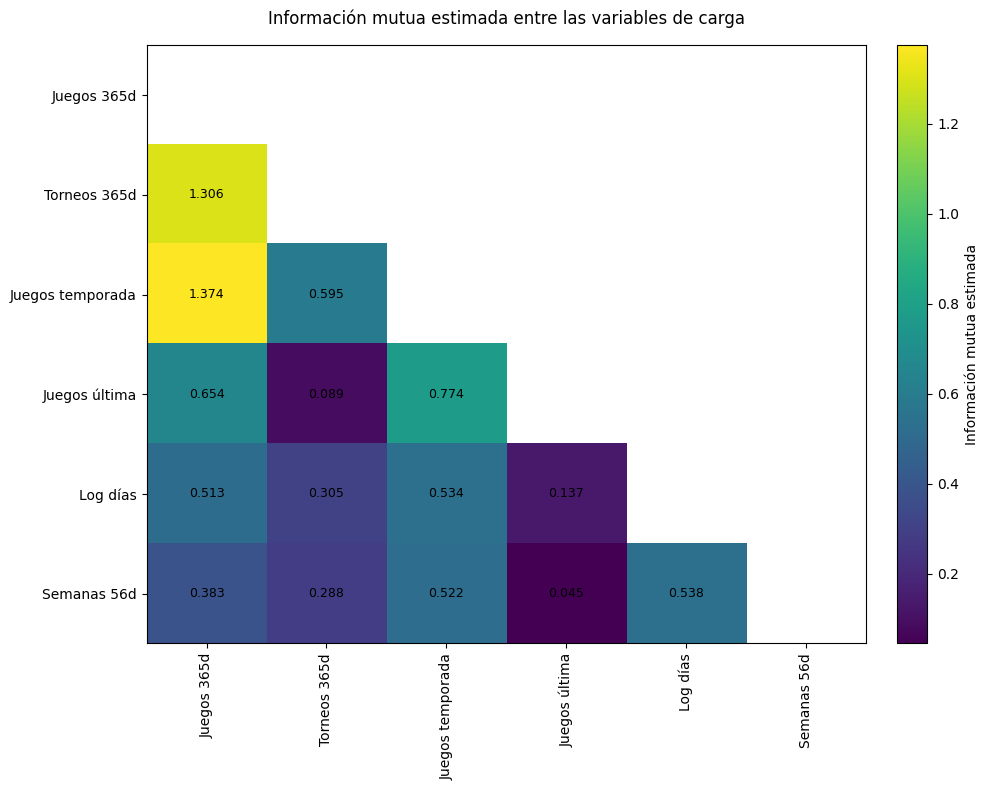

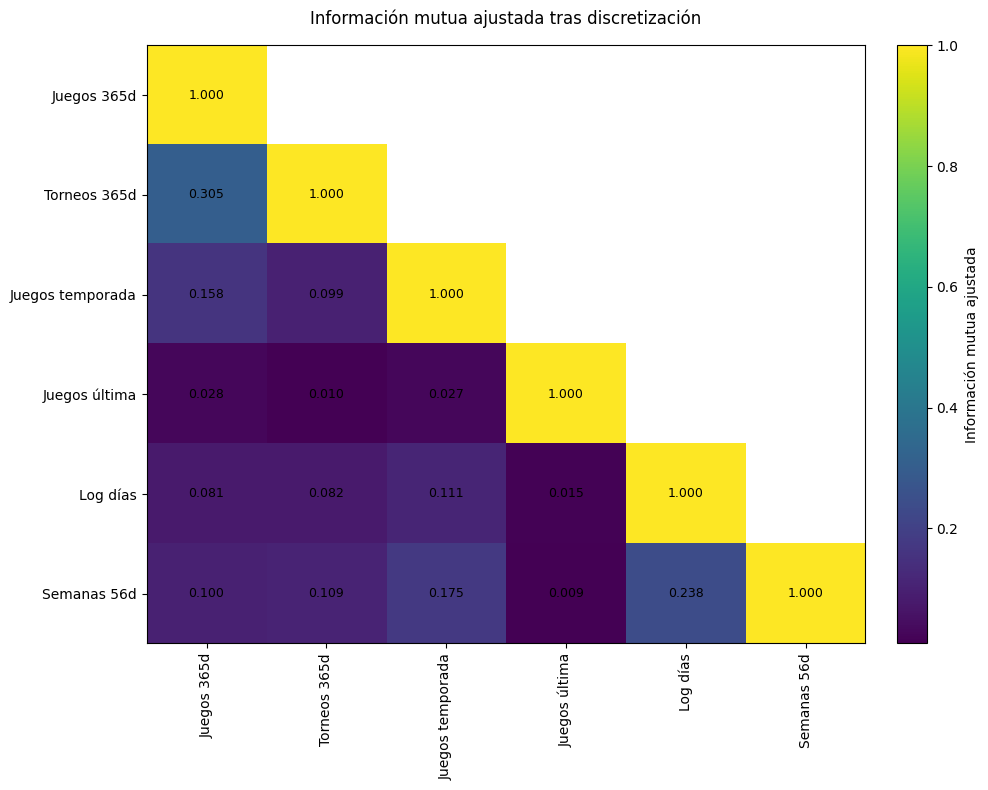

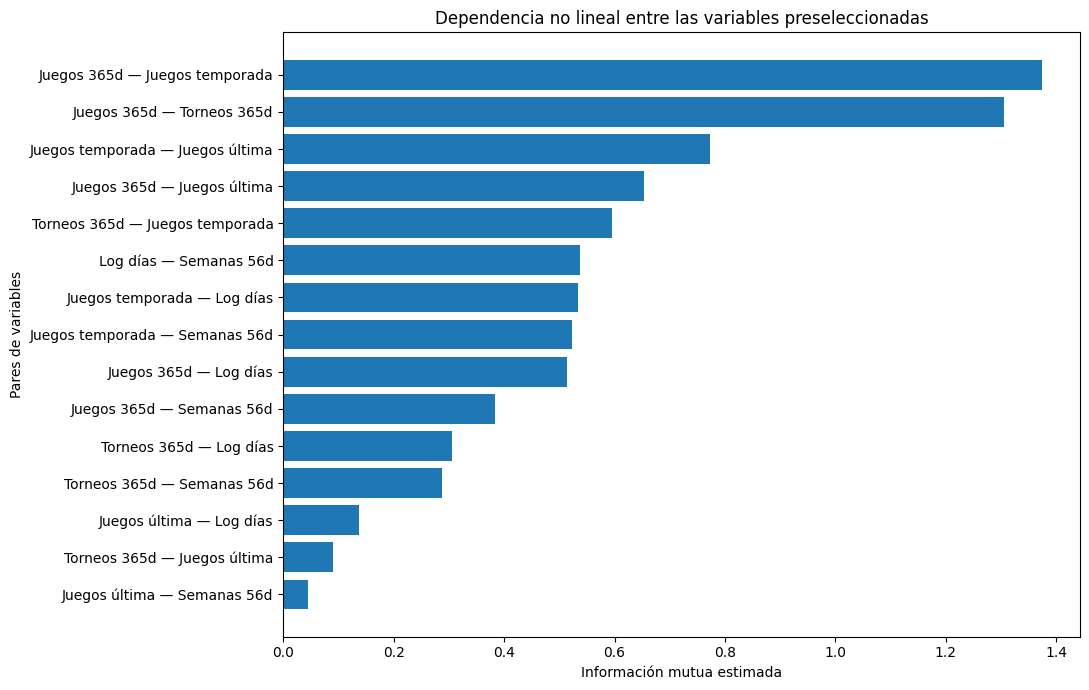

RESULTADOS DE INFORMACIÓN MUTUA


,variable_1,variable_2,mi_direccion_1_2,mi_direccion_2_1,mi_media,diferencia_direcciones,ami_discretizada
0,juegos_365d,juegos_temporada,1.3742,1.3745,1.3744,0.0003,0.1582
1,juegos_365d,torneos_365d,1.3058,1.3058,1.3058,0.0000,0.3046
2,juegos_temporada,juegos_ultima_fecha_competitiva,0.7739,0.7735,0.7737,0.0003,0.0273
3,juegos_365d,juegos_ultima_fecha_competitiva,0.6538,0.6534,0.6536,0.0004,0.0277
4,torneos_365d,juegos_temporada,0.5946,0.5946,0.5946,0.0000,0.0990
5,log_dias_entre_inicios_competitivos,semanas_con_competicion_56d,0.5378,0.5378,0.5378,0.0000,0.2382
6,juegos_temporada,log_dias_entre_inicios_competitivos,0.5348,0.5341,0.5344,0.0007,0.1108
7,juegos_temporada,semanas_con_competicion_56d,0.5223,0.5223,0.5223,0.0000,0.1747
8,juegos_365d,log_dias_entre_inicios_competitivos,0.5117,0.5143,0.5130,0.0026,0.0810
9,juegos_365d,semanas_con_competicion_56d,0.3829,0.3829,0.3829,0.0000,0.0996


Análisis de información mutua completado correctamente.


In [17]:

# ============================================================
# 8.4. INFORMACIÓN MUTUA ENTRE LAS VARIABLES PRESELECCIONADAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.feature_selection import (
    mutual_info_regression,
    mutual_info_classif
)
from sklearn.metrics import adjusted_mutual_info_score


# ------------------------------------------------------------
# 1. Variables provisionalmente representativas
# ------------------------------------------------------------

variables_carga_preseleccion_principal = [
    "juegos_365d",
    "torneos_365d",
    "juegos_temporada",
    "juegos_ultima_fecha_competitiva",
    "log_dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d"
]


etiquetas_mi = {
    "juegos_365d": "Juegos 365d",
    "torneos_365d": "Torneos 365d",
    "juegos_temporada": "Juegos temporada",
    "juegos_ultima_fecha_competitiva": "Juegos última",
    "log_dias_entre_inicios_competitivos": "Log días",
    "semanas_con_competicion_56d": "Semanas 56d"
}


datos_mi = (
    data_muestra_principal[
        variables_carga_preseleccion_principal
    ]
    .astype(float)
    .copy()
)


assert len(datos_mi) == len(data_muestra_principal)
assert datos_mi.notna().all().all()

print("Muestra utilizada:", datos_mi.shape)


# ------------------------------------------------------------
# 2. Identificación operativa de variables discretas
# ------------------------------------------------------------

# Las variables con un máximo de 50 valores distintos
# se tratarán como discretas en el estimador.
def es_variable_discreta(serie, umbral=50):

    return serie.nunique() <= umbral


tipo_variables = pd.DataFrame(
    {
        "variable": variables_carga_preseleccion_principal,
        "valores_unicos": [
            datos_mi[variable].nunique()
            for variable in variables_carga_preseleccion_principal
        ],
        "tratamiento": [
            (
                "Discreta"
                if es_variable_discreta(datos_mi[variable])
                else "Continua"
            )
            for variable in variables_carga_preseleccion_principal
        ]
    }
)


display(tipo_variables)


# ------------------------------------------------------------
# 3. Estimación direccional de información mutua
# ------------------------------------------------------------

def estimar_mi_direccional(
    variable_x,
    variable_y,
    n_neighbors=5,
    random_state=42
):
    """
    Estima I(X;Y).

    Se utiliza mutual_info_classif cuando Y es discreta
    y mutual_info_regression cuando Y se trata como continua.
    """

    x = datos_mi[variable_x]
    y = datos_mi[variable_y]

    x_discreta = es_variable_discreta(x)
    y_discreta = es_variable_discreta(y)

    X = x.to_numpy().reshape(-1, 1)

    if y_discreta:

        y_codificada = pd.factorize(
            y,
            sort=True
        )[0]

        resultado = mutual_info_classif(
            X,
            y_codificada,
            discrete_features=[x_discreta],
            n_neighbors=n_neighbors,
            random_state=random_state
        )[0]

    else:

        resultado = mutual_info_regression(
            X,
            y.to_numpy(),
            discrete_features=[x_discreta],
            n_neighbors=n_neighbors,
            random_state=random_state
        )[0]

    return float(resultado)


# ------------------------------------------------------------
# 4. Matriz simétrica de información mutua
# ------------------------------------------------------------

numero_variables = len(
    variables_carga_preseleccion_principal
)


matriz_mi = pd.DataFrame(
    np.nan,
    index=variables_carga_preseleccion_principal,
    columns=variables_carga_preseleccion_principal,
    dtype=float
)


pares_mi = list(
    combinations(
        variables_carga_preseleccion_principal,
        2
    )
)


resultados_mi = []


print(
    "Calculando información mutua para",
    len(pares_mi),
    "pares..."
)


for numero, (variable_1, variable_2) in enumerate(
    pares_mi,
    start=1
):

    # La información mutua es simétrica en teoría.
    # Se promedian las dos estimaciones direccionales
    # para reducir pequeñas diferencias del estimador.
    mi_1_2 = estimar_mi_direccional(
        variable_1,
        variable_2
    )

    mi_2_1 = estimar_mi_direccional(
        variable_2,
        variable_1
    )

    mi_media = (
        mi_1_2 + mi_2_1
    ) / 2


    matriz_mi.loc[
        variable_1,
        variable_2
    ] = mi_media

    matriz_mi.loc[
        variable_2,
        variable_1
    ] = mi_media


    resultados_mi.append(
        {
            "variable_1": variable_1,
            "variable_2": variable_2,
            "mi_direccion_1_2": mi_1_2,
            "mi_direccion_2_1": mi_2_1,
            "mi_media": mi_media,
            "diferencia_direcciones": abs(
                mi_1_2 - mi_2_1
            )
        }
    )


    print(
        f"Par {numero}/{len(pares_mi)} completado"
    )


tabla_mi = (
    pd.DataFrame(resultados_mi)
    .sort_values(
        "mi_media",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Información mutua ajustada tras discretización
# ------------------------------------------------------------

def discretizar_variable(
    serie,
    numero_intervalos=20
):
    """
    Conserva las categorías originales si la variable
    tiene pocos valores distintos. En caso contrario,
    utiliza intervalos definidos mediante cuantiles.
    """

    if es_variable_discreta(serie):

        return pd.factorize(
            serie,
            sort=True
        )[0]

    categorias = pd.qcut(
        serie,
        q=numero_intervalos,
        labels=False,
        duplicates="drop"
    )

    return categorias.astype(int)


datos_discretizados = pd.DataFrame(
    {
        variable: discretizar_variable(
            datos_mi[variable]
        )
        for variable
        in variables_carga_preseleccion_principal
    }
)


matriz_ami = pd.DataFrame(
    np.eye(numero_variables),
    index=variables_carga_preseleccion_principal,
    columns=variables_carga_preseleccion_principal,
    dtype=float
)


for variable_1, variable_2 in pares_mi:

    ami = adjusted_mutual_info_score(
        datos_discretizados[variable_1],
        datos_discretizados[variable_2],
        average_method="arithmetic"
    )

    matriz_ami.loc[
        variable_1,
        variable_2
    ] = ami

    matriz_ami.loc[
        variable_2,
        variable_1
    ] = ami


tabla_mi["ami_discretizada"] = [
    matriz_ami.loc[
        fila.variable_1,
        fila.variable_2
    ]
    for fila in tabla_mi.itertuples()
]


# ------------------------------------------------------------
# 6. Función de representación
# ------------------------------------------------------------

def representar_matriz(
    matriz,
    titulo,
    etiqueta_barra,
    diagonal=False
):
    """
    Representa el triángulo inferior de una matriz.
    """

    variables = matriz.columns.tolist()

    etiquetas = [
        etiquetas_mi.get(variable, variable)
        for variable in variables
    ]

    valores = matriz.to_numpy(dtype=float)

    mascara = np.triu(
        np.ones_like(
            valores,
            dtype=bool
        ),
        k=0 if not diagonal else 1
    )

    valores_mostrados = np.ma.array(
        valores,
        mask=mascara
    )

    figura, eje = plt.subplots(
        figsize=(10, 8)
    )

    imagen = eje.imshow(
        valores_mostrados,
        aspect="auto"
    )

    eje.set_xticks(
        np.arange(len(etiquetas))
    )

    eje.set_yticks(
        np.arange(len(etiquetas))
    )

    eje.set_xticklabels(
        etiquetas,
        rotation=90
    )

    eje.set_yticklabels(
        etiquetas
    )

    eje.set_title(
        titulo,
        pad=15
    )


    for fila in range(len(variables)):

        limite_columnas = (
            fila + 1
            if diagonal
            else fila
        )

        for columna in range(
            limite_columnas
        ):

            valor = valores[
                fila,
                columna
            ]

            if np.isfinite(valor):

                eje.text(
                    columna,
                    fila,
                    f"{valor:.3f}",
                    ha="center",
                    va="center",
                    fontsize=9
                )


    barra = figura.colorbar(
        imagen,
        ax=eje,
        fraction=0.046,
        pad=0.04
    )

    barra.set_label(
        etiqueta_barra
    )

    figura.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. Representación de resultados
# ------------------------------------------------------------

representar_matriz(
    matriz_mi,
    "Información mutua estimada entre las variables de carga",
    "Información mutua estimada"
)


representar_matriz(
    matriz_ami,
    "Información mutua ajustada tras discretización",
    "Información mutua ajustada",
    diagonal=True
)


# ------------------------------------------------------------
# 8. Comparación de los pares
# ------------------------------------------------------------

tabla_mi_grafico = (
    tabla_mi
    .sort_values(
        "mi_media",
        ascending=True
    )
    .copy()
)


tabla_mi_grafico["par"] = (
    tabla_mi_grafico["variable_1"]
    .map(etiquetas_mi)
    + " — "
    + tabla_mi_grafico["variable_2"]
    .map(etiquetas_mi)
)


figura, eje = plt.subplots(
    figsize=(11, 7)
)


eje.barh(
    tabla_mi_grafico["par"],
    tabla_mi_grafico["mi_media"]
)


eje.set_title(
    "Dependencia no lineal entre las variables preseleccionadas"
)

eje.set_xlabel(
    "Información mutua estimada"
)

eje.set_ylabel(
    "Pares de variables"
)


figura.tight_layout()
plt.show()


print("RESULTADOS DE INFORMACIÓN MUTUA")

display(
    tabla_mi.style.format(
        {
            "mi_direccion_1_2": "{:.4f}",
            "mi_direccion_2_1": "{:.4f}",
            "mi_media": "{:.4f}",
            "diferencia_direcciones": "{:.4f}",
            "ami_discretizada": "{:.4f}"
        }
    )
)


print(
    "Análisis de información mutua completado correctamente."
)



### 8.4.1. Síntesis gráfica para resultados complementarios

A partir de la estimación principal de información mutua ya calculada, se representan
conjuntamente los 15 pares posibles entre las seis variables de carga preseleccionadas.

La información mutua permite identificar dependencias estadísticas que no tienen por
qué ser lineales ni monótonas. Sus valores se interpretan de forma comparativa y no
como coeficientes normalizados ni como umbrales automáticos de selección.

La figura utiliza la estimación principal con cinco vecinos y la media de las dos
estimaciones direccionales de cada par. Las comprobaciones posteriores de sensibilidad
se mantienen como diagnóstico de robustez del notebook.

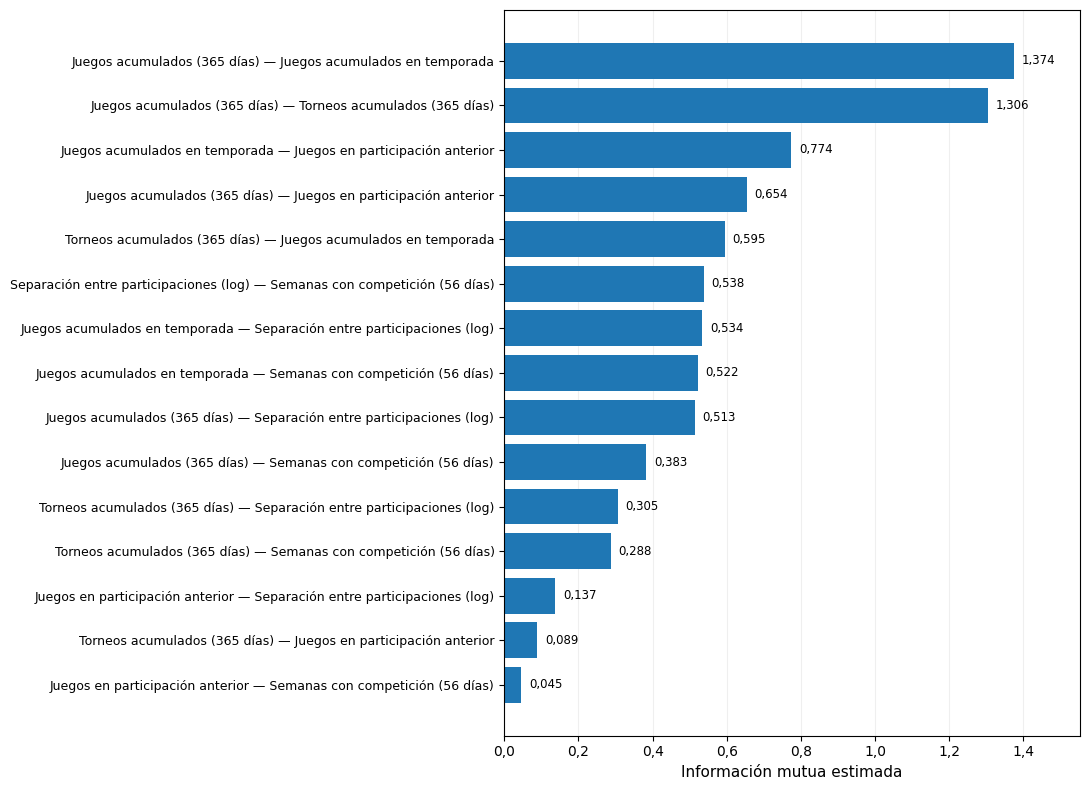

In [18]:
# ============================================================
# FIGURA COMPLEMENTARIA
# DEPENDENCIAS NO LINEALES ENTRE VARIABLES DE CARGA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ------------------------------------------------------------
# 1. Etiquetas interpretables
# ------------------------------------------------------------

etiquetas_mi_anexo = {
    "juegos_365d":
        "Juegos acumulados (365 días)",

    "torneos_365d":
        "Torneos acumulados (365 días)",

    "juegos_temporada":
        "Juegos acumulados en temporada",

    "juegos_ultima_fecha_competitiva":
        "Juegos en participación anterior",

    "log_dias_entre_inicios_competitivos":
        "Separación entre participaciones (log)",

    "semanas_con_competicion_56d":
        "Semanas con competición (56 días)"
}


# ------------------------------------------------------------
# 2. Recuperación de los resultados YA calculados
# ------------------------------------------------------------

tabla_mi_anexo = (
    tabla_mi[
        [
            "variable_1",
            "variable_2",
            "mi_media"
        ]
    ]
    .copy()
    .sort_values(
        "mi_media",
        ascending=False
    )
    .reset_index(drop=True)
)


# Deben existir exactamente los 15 pares posibles entre
# las seis variables preseleccionadas.
assert len(tabla_mi_anexo) == 15

assert tabla_mi_anexo[
    "mi_media"
].notna().all()


# ------------------------------------------------------------
# 3. Construcción de etiquetas de cada par
# ------------------------------------------------------------

tabla_mi_anexo["par"] = (
    tabla_mi_anexo["variable_1"]
    .map(etiquetas_mi_anexo)
    + " — "
    + tabla_mi_anexo["variable_2"]
    .map(etiquetas_mi_anexo)
)

assert tabla_mi_anexo[
    "par"
].notna().all()


# ------------------------------------------------------------
# 4. Formato decimal español
# ------------------------------------------------------------

def formato_decimal_coma(x, pos=None):
    return f"{x:.1f}".replace(".", ",")


# ------------------------------------------------------------
# 5. Figura
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(11, 8)
)


eje.barh(
    tabla_mi_anexo["par"],
    tabla_mi_anexo["mi_media"]
)


# El par con mayor MI queda arriba.
eje.invert_yaxis()


eje.set_xlabel(
    "Información mutua estimada",
    fontsize=11
)

eje.set_ylabel(
    "",
    fontsize=11
)


eje.tick_params(
    axis="x",
    labelsize=10
)

eje.tick_params(
    axis="y",
    labelsize=9
)


eje.xaxis.set_major_formatter(
    FuncFormatter(formato_decimal_coma)
)


# ------------------------------------------------------------
# 6. Valores exactos al final de cada barra
# ------------------------------------------------------------

max_mi = tabla_mi_anexo[
    "mi_media"
].max()

margen = max_mi * 0.015


for posicion, valor in enumerate(
    tabla_mi_anexo["mi_media"]
):

    eje.text(
        valor + margen,
        posicion,
        f"{valor:.3f}".replace(".", ","),
        va="center",
        fontsize=8.5
    )


eje.set_xlim(
    0,
    max_mi * 1.13
)


eje.grid(
    axis="x",
    alpha=0.20
)

eje.set_axisbelow(True)


# ------------------------------------------------------------
# 7. Ajuste final
# ------------------------------------------------------------

figura.tight_layout()

plt.show()

## 8.5. Análisis de sensibilidad de la información mutua

La estimación de la información mutua mediante vecinos próximos depende del parámetro (k), que determina el número de observaciones vecinas utilizadas para aproximar las densidades locales.

Se repetirán los cálculos utilizando:

$$
k\in\{3,5,10,20\}
$$

Asimismo, la información mutua ajustada se volverá a calcular discretizando las variables continuas mediante:

$$
q\in\{10,15,20,30\}.
$$

intervalos definidos por cuantiles.

El objetivo no será obtener valores idénticos, sino comprobar si:

* los pares con mayor dependencia mantienen aproximadamente el mismo orden;
* las conclusiones generales son estables ante diferentes valores de (k);
* la AMI no cambia sustancialmente por una elección concreta del número de intervalos.

Se analizarán tanto las variaciones absolutas de las medidas como la concordancia de los rankings entre las distintas configuraciones.

Este análisis constituye una comprobación de robustez del estimador y no un nuevo procedimiento automático de selección de variables.


Variables analizadas: 6
Pares analizados: 15
Calculando información mutua con k = 3...
k = 3 completado (15 pares).
Calculando información mutua con k = 5...
k = 5 completado (15 pares).
Calculando información mutua con k = 10...
k = 10 completado (15 pares).
Calculando información mutua con k = 20...
k = 20 completado (15 pares).
Tiempo total de la sensibilidad de MI: 80.95 segundos
Calculando AMI con 10 intervalos...
AMI con 10 intervalos completada.
Calculando AMI con 15 intervalos...
AMI con 15 intervalos completada.
Calculando AMI con 20 intervalos...
AMI con 20 intervalos completada.
Calculando AMI con 30 intervalos...
AMI con 30 intervalos completada.


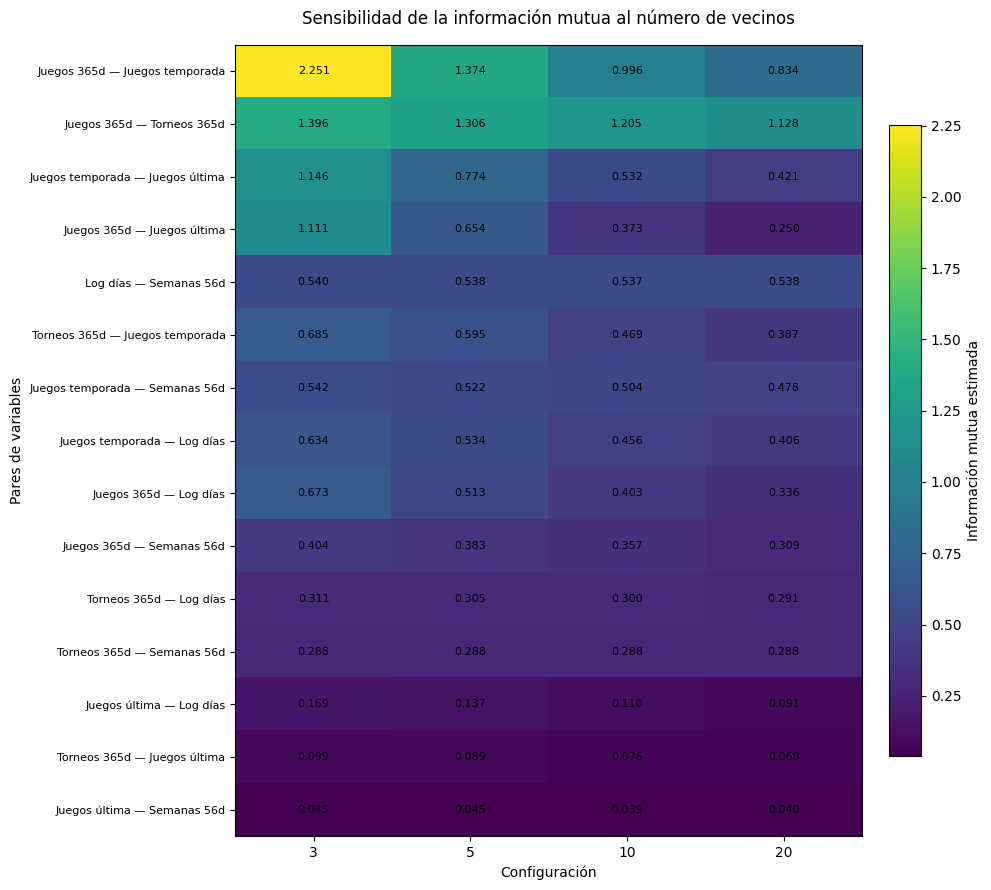

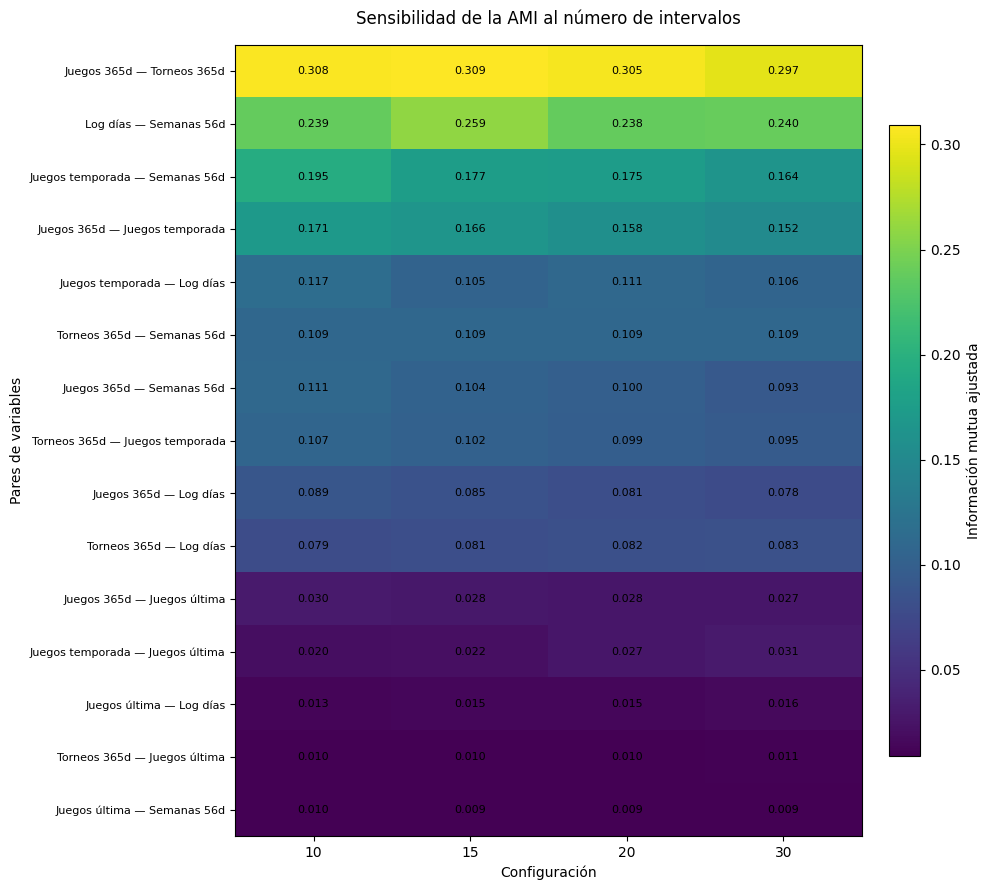

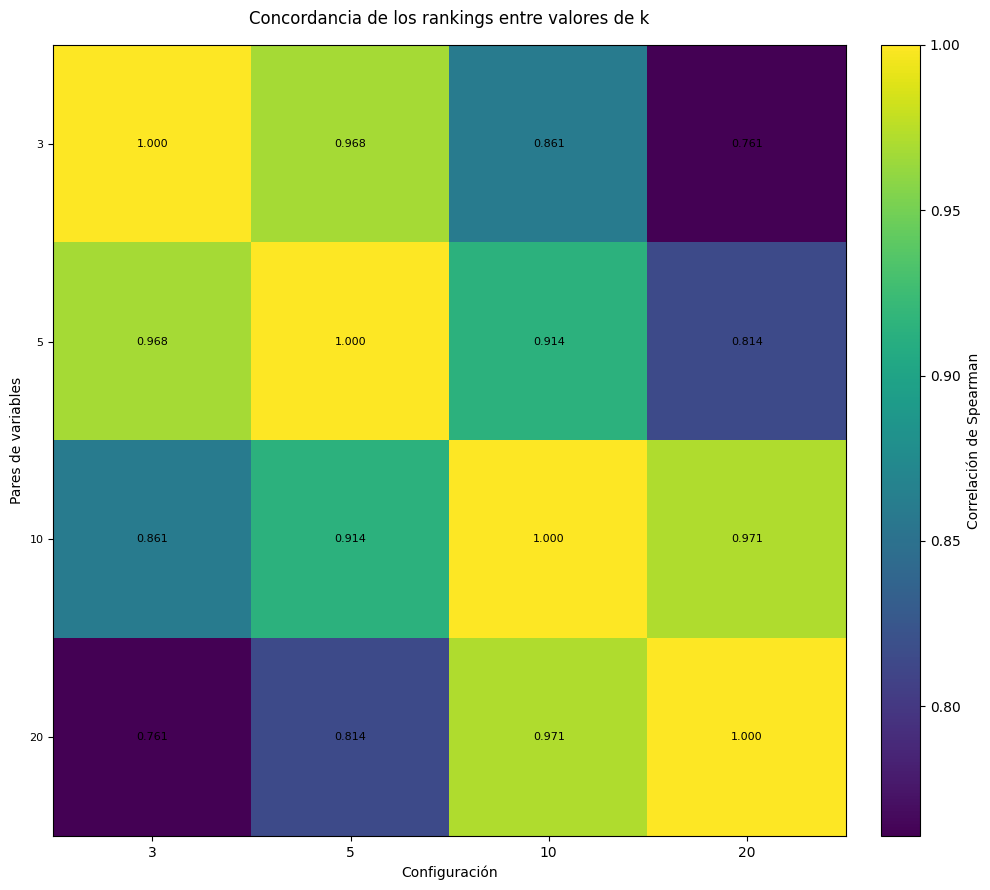

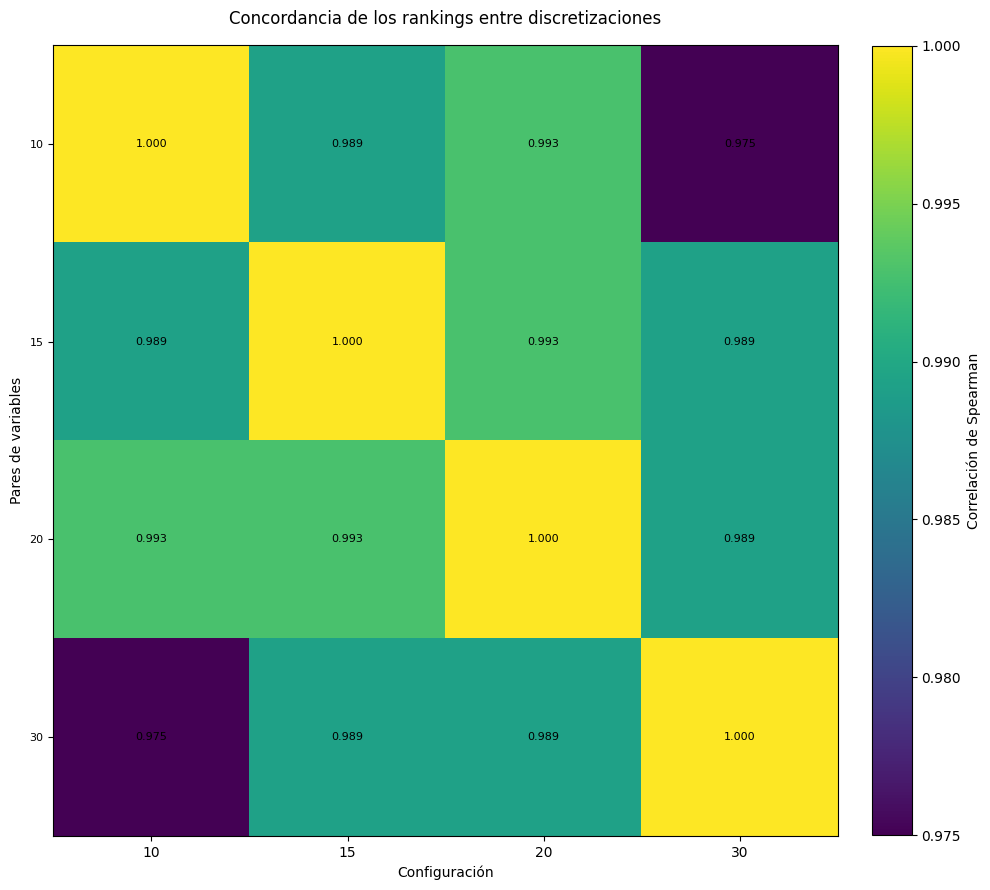

SENSIBILIDAD DE LA INFORMACIÓN MUTUA


,variable_1,variable_2,par,mi_media_global,desviacion_mi,mi_minima,mi_maxima,diferencia_direccional_maxima,rango_mi
0,juegos_365d,juegos_temporada,Juegos 365d — Juegos temporada,1.3639,0.6335,0.8343,2.2515,0.0005,1.4172
1,juegos_365d,torneos_365d,Juegos 365d — Torneos 365d,1.2589,0.1168,1.1285,1.3962,0.0000,0.2678
2,juegos_temporada,juegos_ultima_fecha_competitiva,Juegos temporada — Juegos última,0.7184,0.3211,0.4212,1.1464,0.0013,0.7252
3,juegos_365d,juegos_ultima_fecha_competitiva,Juegos 365d — Juegos última,0.5968,0.3822,0.2495,1.1110,0.0009,0.8615
4,log_dias_entre_inicios_competitivos,semanas_con_competicion_56d,Log días — Semanas 56d,0.5382,0.0013,0.5370,0.5401,0.0000,0.0031
5,torneos_365d,juegos_temporada,Torneos 365d — Juegos temporada,0.5338,0.1319,0.3873,0.6848,0.0000,0.2975
6,juegos_temporada,semanas_con_competicion_56d,Juegos temporada — Semanas 56d,0.5115,0.0273,0.4778,0.5419,0.0000,0.0641
7,juegos_temporada,log_dias_entre_inicios_competitivos,Juegos temporada — Log días,0.5077,0.0994,0.4059,0.6338,0.0012,0.2280
8,juegos_365d,log_dias_entre_inicios_competitivos,Juegos 365d — Log días,0.4811,0.1472,0.3356,0.6727,0.0026,0.3371
9,juegos_365d,semanas_con_competicion_56d,Juegos 365d — Semanas 56d,0.3631,0.0408,0.3090,0.4037,0.0000,0.0947


SENSIBILIDAD DE LA AMI


,variable_1,variable_2,par,ami_media,desviacion_ami,ami_minima,ami_maxima,rango_ami
0,juegos_365d,torneos_365d,Juegos 365d — Torneos 365d,0.3045,0.0055,0.2967,0.3091,0.0124
1,log_dias_entre_inicios_competitivos,semanas_con_competicion_56d,Log días — Semanas 56d,0.2439,0.0100,0.2382,0.2588,0.0206
2,juegos_temporada,semanas_con_competicion_56d,Juegos temporada — Semanas 56d,0.1776,0.0130,0.1639,0.1952,0.0313
3,juegos_365d,juegos_temporada,Juegos 365d — Juegos temporada,0.1620,0.0084,0.1523,0.1714,0.0192
4,juegos_temporada,log_dias_entre_inicios_competitivos,Juegos temporada — Log días,0.1095,0.0056,0.1048,0.1169,0.0121
5,torneos_365d,semanas_con_competicion_56d,Torneos 365d — Semanas 56d,0.1088,0.0000,0.1088,0.1088,0.0000
6,juegos_365d,semanas_con_competicion_56d,Juegos 365d — Semanas 56d,0.1019,0.0076,0.0929,0.1110,0.0181
7,torneos_365d,juegos_temporada,Torneos 365d — Juegos temporada,0.1007,0.0050,0.0950,0.1069,0.0119
8,juegos_365d,log_dias_entre_inicios_competitivos,Juegos 365d — Log días,0.0831,0.0050,0.0776,0.0891,0.0115
9,torneos_365d,log_dias_entre_inicios_competitivos,Torneos 365d — Log días,0.0815,0.0019,0.0791,0.0835,0.0044


CONCORDANCIA ENTRE VALORES DE k


,3,5,10,20
3,1.000,0.968,0.861,0.761
5,0.968,1.000,0.914,0.814
10,0.861,0.914,1.000,0.971
20,0.761,0.814,0.971,1.000


CONCORDANCIA ENTRE NÚMEROS DE INTERVALOS


,10,15,20,30
10,1.000,0.989,0.993,0.975
15,0.989,1.000,0.993,0.989
20,0.993,0.993,1.000,0.989
30,0.975,0.989,0.989,1.000


Análisis de sensibilidad completado correctamente.


In [19]:

# ============================================================
# 8.5. SENSIBILIDAD DE LA INFORMACIÓN MUTUA Y DE LA AMI
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import spearmanr
from sklearn.feature_selection import (
    mutual_info_regression,
    mutual_info_classif
)
from sklearn.metrics import adjusted_mutual_info_score


# ------------------------------------------------------------
# 1. Configuraciones analizadas
# ------------------------------------------------------------

valores_vecinos = [3, 5, 10, 20]
valores_intervalos = [10, 15, 20, 30]


pares_sensibilidad = list(
    combinations(
        variables_carga_preseleccion_principal,
        2
    )
)


def nombre_corto(variable):

    return etiquetas_mi.get(
        variable,
        variable
    )


def nombre_par(variable_1, variable_2):

    return (
        nombre_corto(variable_1)
        + " — "
        + nombre_corto(variable_2)
    )


print(
    "Variables analizadas:",
    len(variables_carga_preseleccion_principal)
)

print(
    "Pares analizados:",
    len(pares_sensibilidad)
)


# ------------------------------------------------------------
# 2. Función de información mutua direccional
# ------------------------------------------------------------

def estimar_mi_sensibilidad(
    variable_x,
    variable_y,
    n_neighbors,
    random_state=42
):
    """
    Estima la información mutua entre X e Y utilizando
    el número de vecinos indicado.

    Se utiliza mutual_info_classif cuando Y es discreta
    y mutual_info_regression cuando Y es continua.
    """

    x = datos_mi[variable_x]
    y = datos_mi[variable_y]

    x_discreta = es_variable_discreta(x)
    y_discreta = es_variable_discreta(y)

    X = x.to_numpy().reshape(-1, 1)

    if y_discreta:

        y_codificada = pd.factorize(
            y,
            sort=True
        )[0]

        resultado = mutual_info_classif(
            X,
            y_codificada,
            discrete_features=[x_discreta],
            n_neighbors=n_neighbors,
            random_state=random_state
        )[0]

    else:

        resultado = mutual_info_regression(
            X,
            y.to_numpy(),
            discrete_features=[x_discreta],
            n_neighbors=n_neighbors,
            random_state=random_state
        )[0]

    return float(resultado)


# ------------------------------------------------------------
# 3. Sensibilidad al número de vecinos
# ------------------------------------------------------------

resultados_sensibilidad_mi = []

inicio_mi = time.time()


for numero_vecinos in valores_vecinos:

    print(
        f"Calculando información mutua con "
        f"k = {numero_vecinos}..."
    )

    for numero_par, (
        variable_1,
        variable_2
    ) in enumerate(
        pares_sensibilidad,
        start=1
    ):

        mi_1_2 = estimar_mi_sensibilidad(
            variable_1,
            variable_2,
            n_neighbors=numero_vecinos
        )

        mi_2_1 = estimar_mi_sensibilidad(
            variable_2,
            variable_1,
            n_neighbors=numero_vecinos
        )

        mi_media = (
            mi_1_2
            + mi_2_1
        ) / 2


        resultados_sensibilidad_mi.append(
            {
                "variable_1": variable_1,
                "variable_2": variable_2,
                "par": nombre_par(
                    variable_1,
                    variable_2
                ),
                "n_neighbors": numero_vecinos,
                "mi_1_2": mi_1_2,
                "mi_2_1": mi_2_1,
                "mi_media": mi_media,
                "diferencia_direcciones": abs(
                    mi_1_2 - mi_2_1
                )
            }
        )


    print(
        f"k = {numero_vecinos} completado "
        f"({len(pares_sensibilidad)} pares)."
    )


tabla_sensibilidad_mi = pd.DataFrame(
    resultados_sensibilidad_mi
)


print(
    "Tiempo total de la sensibilidad de MI:",
    round(time.time() - inicio_mi, 2),
    "segundos"
)


# Matriz: pares en filas y valores de k en columnas.
matriz_sensibilidad_mi = (
    tabla_sensibilidad_mi
    .pivot(
        index="par",
        columns="n_neighbors",
        values="mi_media"
    )
)


# Ordeno los pares según la media global.
orden_pares_mi = (
    matriz_sensibilidad_mi
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
    .index
)


matriz_sensibilidad_mi = (
    matriz_sensibilidad_mi
    .loc[orden_pares_mi]
)


# ------------------------------------------------------------
# 4. Resumen de variación de la MI
# ------------------------------------------------------------

resumen_sensibilidad_mi = (
    tabla_sensibilidad_mi
    .groupby(
        [
            "variable_1",
            "variable_2",
            "par"
        ],
        as_index=False
    )
    .agg(
        mi_media_global=(
            "mi_media",
            "mean"
        ),
        desviacion_mi=(
            "mi_media",
            "std"
        ),
        mi_minima=(
            "mi_media",
            "min"
        ),
        mi_maxima=(
            "mi_media",
            "max"
        ),
        diferencia_direccional_maxima=(
            "diferencia_direcciones",
            "max"
        )
    )
)


resumen_sensibilidad_mi[
    "rango_mi"
] = (
    resumen_sensibilidad_mi["mi_maxima"]
    - resumen_sensibilidad_mi["mi_minima"]
)


resumen_sensibilidad_mi = (
    resumen_sensibilidad_mi
    .sort_values(
        "mi_media_global",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Concordancia de los rankings entre valores de k
# ------------------------------------------------------------

matriz_concordancia_k = pd.DataFrame(
    np.eye(len(valores_vecinos)),
    index=valores_vecinos,
    columns=valores_vecinos,
    dtype=float
)


for k_1, k_2 in combinations(
    valores_vecinos,
    2
):

    concordancia = spearmanr(
        matriz_sensibilidad_mi[k_1],
        matriz_sensibilidad_mi[k_2]
    ).statistic

    matriz_concordancia_k.loc[
        k_1,
        k_2
    ] = concordancia

    matriz_concordancia_k.loc[
        k_2,
        k_1
    ] = concordancia


# ------------------------------------------------------------
# 6. Sensibilidad de la AMI al número de intervalos
# ------------------------------------------------------------

resultados_sensibilidad_ami = []


for numero_intervalos in valores_intervalos:

    print(
        f"Calculando AMI con "
        f"{numero_intervalos} intervalos..."
    )

    datos_discretizados_sensibilidad = pd.DataFrame(
        {
            variable: discretizar_variable(
                datos_mi[variable],
                numero_intervalos=numero_intervalos
            )
            for variable
            in variables_carga_preseleccion_principal
        }
    )


    for variable_1, variable_2 in pares_sensibilidad:

        ami = adjusted_mutual_info_score(
            datos_discretizados_sensibilidad[
                variable_1
            ],
            datos_discretizados_sensibilidad[
                variable_2
            ],
            average_method="arithmetic"
        )


        resultados_sensibilidad_ami.append(
            {
                "variable_1": variable_1,
                "variable_2": variable_2,
                "par": nombre_par(
                    variable_1,
                    variable_2
                ),
                "numero_intervalos": numero_intervalos,
                "ami": ami
            }
        )


    print(
        f"AMI con {numero_intervalos} "
        f"intervalos completada."
    )


tabla_sensibilidad_ami = pd.DataFrame(
    resultados_sensibilidad_ami
)


matriz_sensibilidad_ami = (
    tabla_sensibilidad_ami
    .pivot(
        index="par",
        columns="numero_intervalos",
        values="ami"
    )
)


orden_pares_ami = (
    matriz_sensibilidad_ami
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
    .index
)


matriz_sensibilidad_ami = (
    matriz_sensibilidad_ami
    .loc[orden_pares_ami]
)


# ------------------------------------------------------------
# 7. Resumen de sensibilidad de la AMI
# ------------------------------------------------------------

resumen_sensibilidad_ami = (
    tabla_sensibilidad_ami
    .groupby(
        [
            "variable_1",
            "variable_2",
            "par"
        ],
        as_index=False
    )
    .agg(
        ami_media=(
            "ami",
            "mean"
        ),
        desviacion_ami=(
            "ami",
            "std"
        ),
        ami_minima=(
            "ami",
            "min"
        ),
        ami_maxima=(
            "ami",
            "max"
        )
    )
)


resumen_sensibilidad_ami[
    "rango_ami"
] = (
    resumen_sensibilidad_ami["ami_maxima"]
    - resumen_sensibilidad_ami["ami_minima"]
)


resumen_sensibilidad_ami = (
    resumen_sensibilidad_ami
    .sort_values(
        "ami_media",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Concordancia de rankings entre discretizaciones
# ------------------------------------------------------------

matriz_concordancia_intervalos = pd.DataFrame(
    np.eye(len(valores_intervalos)),
    index=valores_intervalos,
    columns=valores_intervalos,
    dtype=float
)


for q_1, q_2 in combinations(
    valores_intervalos,
    2
):

    concordancia = spearmanr(
        matriz_sensibilidad_ami[q_1],
        matriz_sensibilidad_ami[q_2]
    ).statistic

    matriz_concordancia_intervalos.loc[
        q_1,
        q_2
    ] = concordancia

    matriz_concordancia_intervalos.loc[
        q_2,
        q_1
    ] = concordancia


# ------------------------------------------------------------
# 9. Función gráfica para las matrices de sensibilidad
# ------------------------------------------------------------

def graficar_matriz_sensibilidad(
    matriz,
    titulo,
    etiqueta_barra
):
    """
    Representa una matriz con los pares en filas y
    las configuraciones metodológicas en columnas.
    """

    valores = matriz.to_numpy(dtype=float)

    figura, eje = plt.subplots(
        figsize=(10, 9)
    )

    imagen = eje.imshow(
        valores,
        aspect="auto"
    )


    eje.set_xticks(
        np.arange(matriz.shape[1])
    )

    eje.set_yticks(
        np.arange(matriz.shape[0])
    )

    eje.set_xticklabels(
        matriz.columns
    )

    eje.set_yticklabels(
        matriz.index,
        fontsize=8
    )


    for fila in range(matriz.shape[0]):

        for columna in range(matriz.shape[1]):

            eje.text(
                columna,
                fila,
                f"{valores[fila, columna]:.3f}",
                ha="center",
                va="center",
                fontsize=8
            )


    eje.set_title(
        titulo,
        pad=15
    )

    eje.set_xlabel(
        "Configuración"
    )

    eje.set_ylabel(
        "Pares de variables"
    )


    barra = figura.colorbar(
        imagen,
        ax=eje,
        fraction=0.046,
        pad=0.04
    )

    barra.set_label(
        etiqueta_barra
    )


    figura.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Gráficos de sensibilidad
# ------------------------------------------------------------

graficar_matriz_sensibilidad(
    matriz_sensibilidad_mi,
    (
        "Sensibilidad de la información mutua "
        "al número de vecinos"
    ),
    "Información mutua estimada"
)


graficar_matriz_sensibilidad(
    matriz_sensibilidad_ami,
    (
        "Sensibilidad de la AMI "
        "al número de intervalos"
    ),
    "Información mutua ajustada"
)


# ------------------------------------------------------------
# 11. Gráficos de concordancia de rankings
# ------------------------------------------------------------

graficar_matriz_sensibilidad(
    matriz_concordancia_k,
    (
        "Concordancia de los rankings "
        "entre valores de k"
    ),
    "Correlación de Spearman"
)


graficar_matriz_sensibilidad(
    matriz_concordancia_intervalos,
    (
        "Concordancia de los rankings "
        "entre discretizaciones"
    ),
    "Correlación de Spearman"
)


# ------------------------------------------------------------
# 12. Resultados tabulares
# ------------------------------------------------------------

print("SENSIBILIDAD DE LA INFORMACIÓN MUTUA")

display(
    resumen_sensibilidad_mi.style.format(
        {
            "mi_media_global": "{:.4f}",
            "desviacion_mi": "{:.4f}",
            "mi_minima": "{:.4f}",
            "mi_maxima": "{:.4f}",
            "rango_mi": "{:.4f}",
            "diferencia_direccional_maxima": "{:.4f}"
        }
    )
)


print("SENSIBILIDAD DE LA AMI")

display(
    resumen_sensibilidad_ami.style.format(
        {
            "ami_media": "{:.4f}",
            "desviacion_ami": "{:.4f}",
            "ami_minima": "{:.4f}",
            "ami_maxima": "{:.4f}",
            "rango_ami": "{:.4f}"
        }
    )
)


print("CONCORDANCIA ENTRE VALORES DE k")

display(
    matriz_concordancia_k.style.format(
        "{:.3f}"
    )
)


print("CONCORDANCIA ENTRE NÚMEROS DE INTERVALOS")

display(
    matriz_concordancia_intervalos.style.format(
        "{:.3f}"
    )
)


print(
    "Análisis de sensibilidad completado correctamente."
)



### 8.5.1. Resumen de la estabilidad de las ordenaciones

La sensibilidad de las dependencias identificadas se resume mediante la concordancia
de los rankings de los 15 pares de variables entre las distintas parametrizaciones.

Para la información mutua basada en vecinos próximos se comparan las ordenaciones
obtenidas con `k = 3, 5, 10 y 20`. Para la información mutua ajustada tras
discretización se comparan las ordenaciones correspondientes a `q = 10, 15, 20 y 30`
intervalos definidos por cuantiles.

La correlación de Spearman entre rankings se utiliza únicamente como medida
descriptiva de estabilidad: valores próximos a uno indican que los pares conservan
una ordenación similar al modificar la parametrización del estimador.

In [20]:
# ============================================================
# RESUMEN PARA EL ANEXO:
# ESTABILIDAD DE LOS RANKINGS DE INFORMACIÓN MUTUA
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Extraer únicamente las comparaciones distintas
#    de la diagonal en cada matriz de concordancia
# ------------------------------------------------------------

def extraer_concordancias_unicas(matriz):
    """
    Recupera una sola vez cada comparación entre
    configuraciones, excluyendo la diagonal.
    """

    valores = matriz.to_numpy(dtype=float)

    indices_superiores = np.triu_indices_from(
        valores,
        k=1
    )

    return valores[indices_superiores]


concordancias_k = extraer_concordancias_unicas(
    matriz_concordancia_k
)

concordancias_q = extraer_concordancias_unicas(
    matriz_concordancia_intervalos
)


# ------------------------------------------------------------
# 2. Comprobaciones
# ------------------------------------------------------------

# Con cuatro configuraciones existen 4*3/2 = 6
# comparaciones distintas.
assert len(concordancias_k) == 6
assert len(concordancias_q) == 6

assert np.isfinite(concordancias_k).all()
assert np.isfinite(concordancias_q).all()


# ------------------------------------------------------------
# 3. Construcción del cuadro-resumen
# ------------------------------------------------------------

tabla_estabilidad_mi = pd.DataFrame(
    {
        "Análisis": [
            "MI mediante vecinos próximos",
            "AMI tras discretización por cuantiles"
        ],

        "Configuraciones": [
            "k = {3, 5, 10, 20}",
            "q = {10, 15, 20, 30}"
        ],

        "Concordancia_media": [
            concordancias_k.mean(),
            concordancias_q.mean()
        ],

        "Concordancia_minima": [
            concordancias_k.min(),
            concordancias_q.min()
        ],

        "Concordancia_maxima": [
            concordancias_k.max(),
            concordancias_q.max()
        ]
    }
)


# ------------------------------------------------------------
# 4. Presentación
# ------------------------------------------------------------

display(
    tabla_estabilidad_mi.style.format(
        {
            "Concordancia_media": "{:.3f}",
            "Concordancia_minima": "{:.3f}",
            "Concordancia_maxima": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 5. Matrices completas de control
# ------------------------------------------------------------

print(
    "\nConcordancia completa entre valores de k:"
)

display(
    matriz_concordancia_k.style.format(
        "{:.3f}"
    )
)


print(
    "\nConcordancia completa entre números de intervalos:"
)

display(
    matriz_concordancia_intervalos.style.format(
        "{:.3f}"
    )
)

,Análisis,Configuraciones,Concordancia_media,Concordancia_minima,Concordancia_maxima
0,MI mediante vecinos próximos,"k = {3, 5, 10, 20}",0.882,0.761,0.971
1,AMI tras discretización por cuantiles,"q = {10, 15, 20, 30}",0.988,0.975,0.993



Concordancia completa entre valores de k:


,3,5,10,20
3,1.000,0.968,0.861,0.761
5,0.968,1.000,0.914,0.814
10,0.861,0.914,1.000,0.971
20,0.761,0.814,0.971,1.000



Concordancia completa entre números de intervalos:


,10,15,20,30
10,1.000,0.989,0.993,0.975
15,0.989,1.000,0.993,0.989
20,0.993,0.993,1.000,0.989
30,0.975,0.989,0.989,1.000


## 8.6. Dependencia mediante correlación de distancias

La correlación de distancias complementa las medidas anteriores al permitir detectar relaciones lineales y no lineales entre variables numéricas.

Su valor se encuentra entre cero y uno:

$$
0\leq \operatorname{dCor}(X,Y)\leq 1.
$$

Valores próximos a cero indican una dependencia débil, mientras que valores elevados indican que las distancias observadas en una variable están relacionadas con las distancias observadas en la otra.

Debido al coste computacional cuadrático de la formulación matricial, el cálculo se realizará sobre varias submuestras reproducibles a nivel jugador–torneo. Esta estructura evita que una misma carga quede repetida por cada partido disputado dentro del torneo.

Se realizarán cinco repeticiones independientes y se presentarán:

* la correlación de distancias media;
* su desviación típica;
* el mínimo y el máximo obtenidos;
* su comparación con la correlación absoluta de Spearman.

La correlación de distancias no proporciona el signo de la asociación. La dirección continuará interpretándose mediante Pearson, Spearman y Kendall.


Observaciones jugador–torneo disponibles: 39266
Repetición 1/5...
Repetición 1 completada.
Repetición 2/5...
Repetición 2 completada.
Repetición 3/5...
Repetición 3 completada.
Repetición 4/5...
Repetición 4 completada.
Repetición 5/5...
Repetición 5 completada.


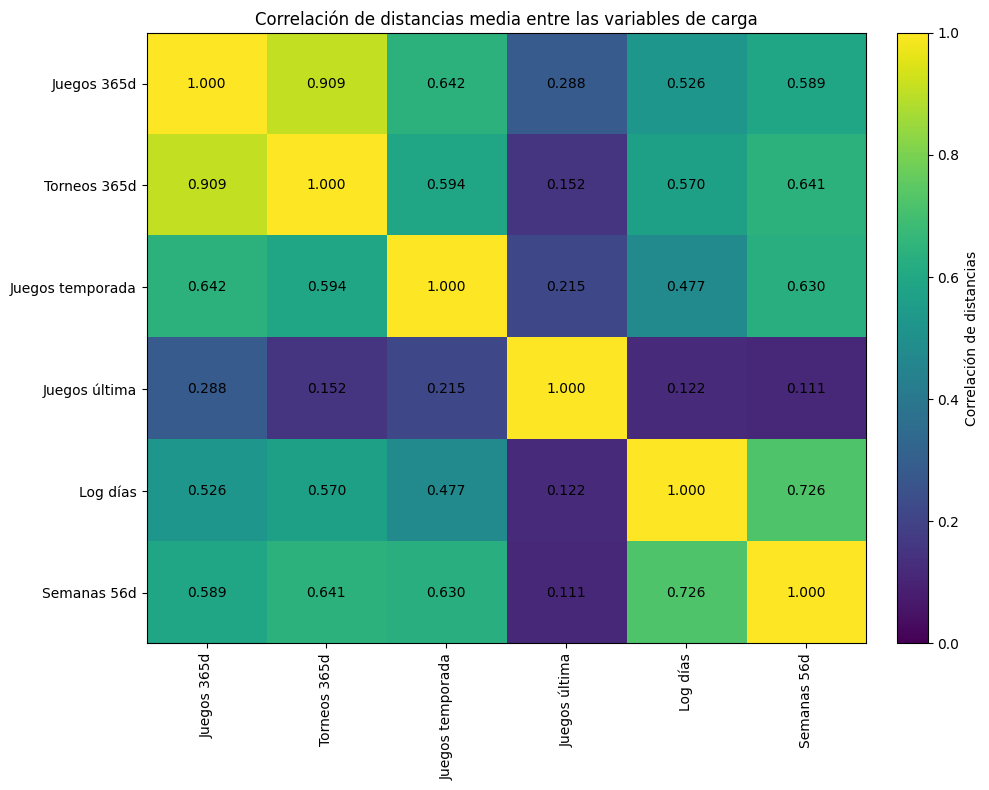

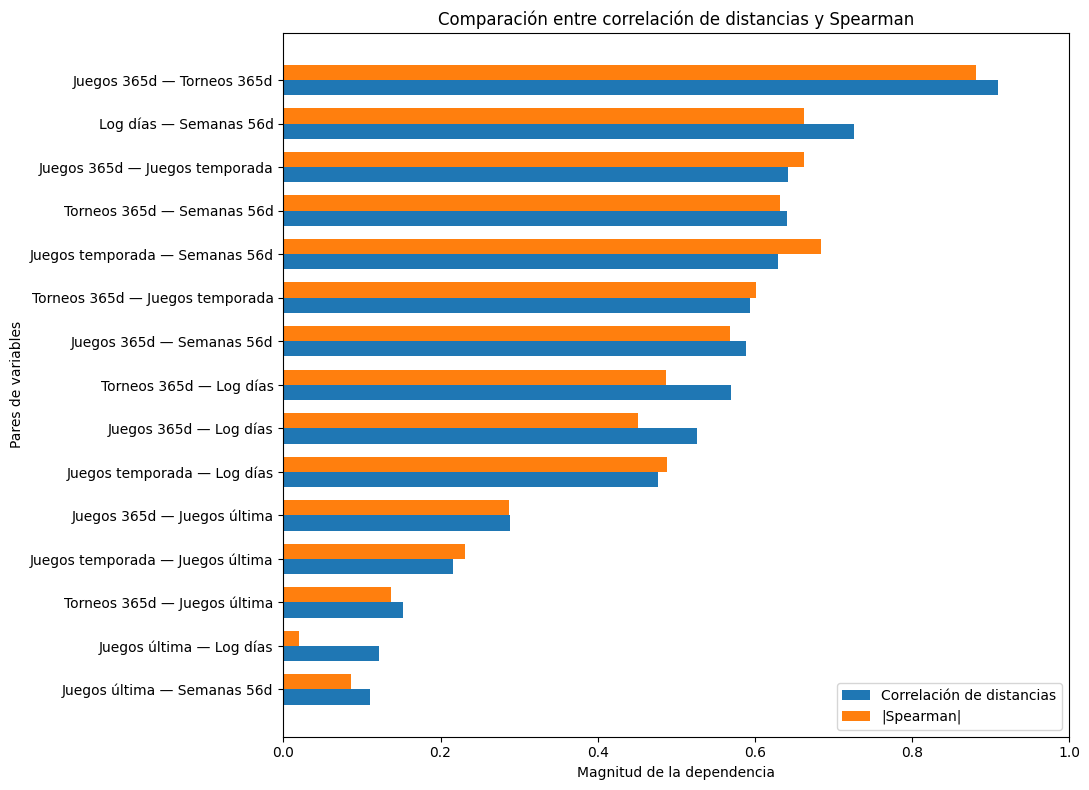

,variable_1,variable_2,dcor_media,desviacion_dcor,dcor_minima,dcor_maxima,rango_dcor,spearman_absoluta
0,juegos_365d,torneos_365d,0.9092,0.0014,0.9081,0.9113,0.0031,0.8812
1,log_dias_entre_inicios_competitivos,semanas_con_competicion_56d,0.7260,0.0038,0.7211,0.7309,0.0097,0.6624
2,juegos_365d,juegos_temporada,0.6423,0.0098,0.6300,0.6501,0.0201,0.6626
3,torneos_365d,semanas_con_competicion_56d,0.6415,0.0112,0.6284,0.6546,0.0262,0.6322
4,juegos_temporada,semanas_con_competicion_56d,0.6299,0.0141,0.6182,0.6537,0.0356,0.6849
5,torneos_365d,juegos_temporada,0.5936,0.0106,0.5760,0.6035,0.0275,0.6014
6,juegos_365d,semanas_con_competicion_56d,0.5891,0.0165,0.5613,0.6009,0.0396,0.5682
7,torneos_365d,log_dias_entre_inicios_competitivos,0.5697,0.0103,0.5576,0.5851,0.0276,0.4871
8,juegos_365d,log_dias_entre_inicios_competitivos,0.5261,0.0057,0.5204,0.5347,0.0143,0.4509
9,juegos_temporada,log_dias_entre_inicios_competitivos,0.4769,0.0092,0.4636,0.4849,0.0212,0.4877


Análisis mediante correlación de distancias completado.


In [21]:

# ============================================================
# 8.6. CORRELACIÓN DE DISTANCIAS
# ============================================================

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations


# ------------------------------------------------------------
# 1. Preparación a nivel jugador–torneo
# ------------------------------------------------------------

datos_dcor_base = (
    data_muestra_principal
    .sort_values(
        [
            "jugador_id",
            "fecha_torneo",
            "identificador_torneo"
        ]
    )
    .drop_duplicates(
        subset=[
            "jugador_id",
            "identificador_torneo"
        ]
    )
    [
        variables_carga_preseleccion_principal
    ]
    .astype(float)
    .copy()
)


assert datos_dcor_base.notna().all().all()


print(
    "Observaciones jugador–torneo disponibles:",
    len(datos_dcor_base)
)


# ------------------------------------------------------------
# 2. Funciones para la correlación de distancias
# ------------------------------------------------------------

def matriz_distancias_centrada(valores):
    """
    Construye y centra la matriz de distancias euclídeas
    de una variable unidimensional.
    """

    valores = np.asarray(
        valores,
        dtype=np.float64
    )

    distancias = np.abs(
        valores[:, None]
        - valores[None, :]
    )

    media_filas = distancias.mean(
        axis=1,
        keepdims=True
    )

    media_columnas = distancias.mean(
        axis=0,
        keepdims=True
    )

    media_global = distancias.mean()

    return (
        distancias
        - media_filas
        - media_columnas
        + media_global
    )


def correlacion_distancias_matrices(
    matriz_x,
    matriz_y
):
    """
    Calcula la correlación de distancias a partir
    de dos matrices de distancias centradas.
    """

    covarianza_distancias_cuadrada = np.mean(
        matriz_x * matriz_y
    )

    varianza_x_cuadrada = np.mean(
        matriz_x * matriz_x
    )

    varianza_y_cuadrada = np.mean(
        matriz_y * matriz_y
    )


    if (
        varianza_x_cuadrada <= 0
        or varianza_y_cuadrada <= 0
    ):
        return np.nan


    correlacion_cuadrada = (
        covarianza_distancias_cuadrada
        / np.sqrt(
            varianza_x_cuadrada
            * varianza_y_cuadrada
        )
    )


    return float(
        np.sqrt(
            max(correlacion_cuadrada, 0)
        )
    )


# ------------------------------------------------------------
# 3. Configuración de las submuestras
# ------------------------------------------------------------

tamano_submuestra = 1500
numero_repeticiones = 5

semillas = [
    2025,
    2026,
    2027,
    2028,
    2029
]


assert len(datos_dcor_base) >= tamano_submuestra


pares_dcor = list(
    combinations(
        variables_carga_preseleccion_principal,
        2
    )
)


resultados_dcor = []


# ------------------------------------------------------------
# 4. Cálculo repetido
# ------------------------------------------------------------

for repeticion, semilla in enumerate(
    semillas,
    start=1
):

    print(
        f"Repetición {repeticion}/{numero_repeticiones}..."
    )


    muestra_dcor = (
        datos_dcor_base
        .sample(
            n=tamano_submuestra,
            replace=False,
            random_state=semilla
        )
        .reset_index(drop=True)
    )


    matrices_centradas = {}


    for variable in variables_carga_preseleccion_principal:

        matrices_centradas[variable] = (
            matriz_distancias_centrada(
                muestra_dcor[variable].to_numpy()
            )
        )


    for variable_1, variable_2 in pares_dcor:

        dcor_valor = correlacion_distancias_matrices(
            matrices_centradas[variable_1],
            matrices_centradas[variable_2]
        )


        resultados_dcor.append(
            {
                "repeticion": repeticion,
                "semilla": semilla,
                "variable_1": variable_1,
                "variable_2": variable_2,
                "dcor": dcor_valor
            }
        )


    del matrices_centradas
    del muestra_dcor

    gc.collect()

    print(
        f"Repetición {repeticion} completada."
    )


tabla_dcor_repeticiones = pd.DataFrame(
    resultados_dcor
)


# ------------------------------------------------------------
# 5. Resumen de estabilidad
# ------------------------------------------------------------

resumen_dcor = (
    tabla_dcor_repeticiones
    .groupby(
        [
            "variable_1",
            "variable_2"
        ],
        as_index=False
    )
    .agg(
        dcor_media=("dcor", "mean"),
        desviacion_dcor=("dcor", "std"),
        dcor_minima=("dcor", "min"),
        dcor_maxima=("dcor", "max")
    )
)


resumen_dcor["rango_dcor"] = (
    resumen_dcor["dcor_maxima"]
    - resumen_dcor["dcor_minima"]
)


# Correlación absoluta de Spearman sobre la misma
# estructura jugador–torneo completa.
matriz_spearman_dcor = (
    datos_dcor_base
    .corr(method="spearman")
)


resumen_dcor["spearman_absoluta"] = [
    abs(
        matriz_spearman_dcor.loc[
            fila.variable_1,
            fila.variable_2
        ]
    )
    for fila in resumen_dcor.itertuples()
]


resumen_dcor = (
    resumen_dcor
    .sort_values(
        "dcor_media",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Matriz media de correlación de distancias
# ------------------------------------------------------------

matriz_dcor_media = pd.DataFrame(
    np.eye(
        len(
            variables_carga_preseleccion_principal
        )
    ),
    index=variables_carga_preseleccion_principal,
    columns=variables_carga_preseleccion_principal,
    dtype=float
)


for fila in resumen_dcor.itertuples():

    matriz_dcor_media.loc[
        fila.variable_1,
        fila.variable_2
    ] = fila.dcor_media

    matriz_dcor_media.loc[
        fila.variable_2,
        fila.variable_1
    ] = fila.dcor_media


etiquetas_dcor = [
    etiquetas_mi.get(variable, variable)
    for variable
    in variables_carga_preseleccion_principal
]


figura, eje = plt.subplots(
    figsize=(10, 8)
)


imagen = eje.imshow(
    matriz_dcor_media.to_numpy(),
    vmin=0,
    vmax=1,
    aspect="auto"
)


eje.set_xticks(
    np.arange(len(etiquetas_dcor))
)

eje.set_yticks(
    np.arange(len(etiquetas_dcor))
)

eje.set_xticklabels(
    etiquetas_dcor,
    rotation=90
)

eje.set_yticklabels(
    etiquetas_dcor
)


for fila in range(len(etiquetas_dcor)):

    for columna in range(len(etiquetas_dcor)):

        eje.text(
            columna,
            fila,
            f"{matriz_dcor_media.iloc[fila, columna]:.3f}",
            ha="center",
            va="center"
        )


eje.set_title(
    "Correlación de distancias media "
    "entre las variables de carga"
)


barra = figura.colorbar(
    imagen,
    ax=eje,
    fraction=0.046,
    pad=0.04
)

barra.set_label(
    "Correlación de distancias"
)


figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Comparación con Spearman
# ------------------------------------------------------------

resumen_dcor_grafico = (
    resumen_dcor
    .sort_values(
        "dcor_media",
        ascending=True
    )
    .copy()
)


resumen_dcor_grafico["par"] = (
    resumen_dcor_grafico["variable_1"]
    .map(etiquetas_mi)
    + " — "
    + resumen_dcor_grafico["variable_2"]
    .map(etiquetas_mi)
)


posiciones = np.arange(
    len(resumen_dcor_grafico)
)

altura = 0.35


figura, eje = plt.subplots(
    figsize=(11, 8)
)


eje.barh(
    posiciones - altura / 2,
    resumen_dcor_grafico["dcor_media"],
    height=altura,
    label="Correlación de distancias"
)

eje.barh(
    posiciones + altura / 2,
    resumen_dcor_grafico["spearman_absoluta"],
    height=altura,
    label="|Spearman|"
)


eje.set_yticks(
    posiciones
)

eje.set_yticklabels(
    resumen_dcor_grafico["par"]
)

eje.set_xlim(
    0,
    1
)

eje.set_xlabel(
    "Magnitud de la dependencia"
)

eje.set_ylabel(
    "Pares de variables"
)

eje.set_title(
    "Comparación entre correlación de distancias "
    "y Spearman"
)

eje.legend()


figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Resultados tabulares
# ------------------------------------------------------------

display(
    resumen_dcor.style.format(
        {
            "dcor_media": "{:.4f}",
            "desviacion_dcor": "{:.4f}",
            "dcor_minima": "{:.4f}",
            "dcor_maxima": "{:.4f}",
            "rango_dcor": "{:.4f}",
            "spearman_absoluta": "{:.4f}"
        }
    )
)


print(
    "Análisis mediante correlación de distancias completado."
)



### 8.6.1 Síntesis de las principales dependencias entre variables de carga

Como síntesis de los análisis complementarios de dependencia, se comparan tres
aproximaciones: la información mutua estimada directamente sobre variables continuas
mediante vecinos próximos, la información mutua ajustada obtenida tras discretización
por cuantiles y la correlación de distancias.

Las tres medidas se mantienen por separado, ya que utilizan procedimientos y escalas
diferentes y sus valores no son directamente comparables entre sí. Para identificar las
relaciones que aparecen de forma más consistente entre métodos, los 15 pares se ordenan
independientemente según cada medida y se utiliza únicamente la posición media de las
tres ordenaciones como criterio auxiliar de selección.

Para la representación discretizada se adopta q = 20 como configuración de referencia,
situada en una posición intermedia dentro de las parametrizaciones evaluadas. La
estabilidad de los resultados frente a otros números de intervalos se comprobó previamente
mediante el análisis de sensibilidad.

In [22]:
# ============================================================
# SÍNTESIS DE DEPENDENCIAS:
# MI CONTINUA + AMI DISCRETIZADA + dCor
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Función para identificar cada par sin depender
#    del orden de las variables
# ------------------------------------------------------------

def crear_clave_par(variable_1, variable_2):

    return " || ".join(
        sorted(
            [
                variable_1,
                variable_2
            ]
        )
    )


# ------------------------------------------------------------
# 2. MI principal sobre variables continuas
#    Configuración principal: k = 5
# ------------------------------------------------------------

mi_principal = (
    tabla_mi[
        [
            "variable_1",
            "variable_2",
            "mi_media"
        ]
    ]
    .copy()
)

mi_principal["clave_par"] = [
    crear_clave_par(v1, v2)
    for v1, v2 in zip(
        mi_principal["variable_1"],
        mi_principal["variable_2"]
    )
]

mi_principal = (
    mi_principal
    .rename(
        columns={
            "mi_media": "MI_k5"
        }
    )
)


# ------------------------------------------------------------
# 3. AMI tras discretización por cuantiles
#    Configuración de referencia: q = 20
# ------------------------------------------------------------

ami_q20 = (
    tabla_sensibilidad_ami[
        tabla_sensibilidad_ami[
            "numero_intervalos"
        ] == 20
    ]
    [
        [
            "variable_1",
            "variable_2",
            "ami"
        ]
    ]
    .copy()
)

ami_q20["clave_par"] = [
    crear_clave_par(v1, v2)
    for v1, v2 in zip(
        ami_q20["variable_1"],
        ami_q20["variable_2"]
    )
]

ami_q20 = (
    ami_q20
    .rename(
        columns={
            "ami": "AMI_q20"
        }
    )
)


# ------------------------------------------------------------
# 4. Correlación de distancias
# ------------------------------------------------------------

dcor = (
    resumen_dcor[
        [
            "variable_1",
            "variable_2",
            "dcor_media"
        ]
    ]
    .copy()
)

dcor["clave_par"] = [
    crear_clave_par(v1, v2)
    for v1, v2 in zip(
        dcor["variable_1"],
        dcor["variable_2"]
    )
]


# ------------------------------------------------------------
# 5. Unificación
# ------------------------------------------------------------

tabla_dependencias = (
    mi_principal[
        [
            "variable_1",
            "variable_2",
            "clave_par",
            "MI_k5"
        ]
    ]
    .merge(
        ami_q20[
            [
                "clave_par",
                "AMI_q20"
            ]
        ],
        on="clave_par",
        how="inner"
    )
    .merge(
        dcor[
            [
                "clave_par",
                "dcor_media"
            ]
        ],
        on="clave_par",
        how="inner"
    )
)


# ------------------------------------------------------------
# 6. Comprobaciones
# ------------------------------------------------------------

assert len(tabla_dependencias) == 15

assert tabla_dependencias[
    [
        "MI_k5",
        "AMI_q20",
        "dcor_media"
    ]
].notna().all().all()


# ------------------------------------------------------------
# 7. Ranking independiente dentro de cada método
# ------------------------------------------------------------

tabla_dependencias["rank_MI"] = (
    tabla_dependencias["MI_k5"]
    .rank(
        method="average",
        ascending=False
    )
)

tabla_dependencias["rank_AMI"] = (
    tabla_dependencias["AMI_q20"]
    .rank(
        method="average",
        ascending=False
    )
)

tabla_dependencias["rank_dCor"] = (
    tabla_dependencias["dcor_media"]
    .rank(
        method="average",
        ascending=False
    )
)


# ------------------------------------------------------------
# 8. Posición media como criterio auxiliar
# ------------------------------------------------------------

tabla_dependencias["rank_medio"] = (
    tabla_dependencias[
        [
            "rank_MI",
            "rank_AMI",
            "rank_dCor"
        ]
    ]
    .mean(axis=1)
)


# ------------------------------------------------------------
# 9. Etiquetas legibles
# ------------------------------------------------------------

etiquetas = {
    "juegos_365d":
        "Juegos acumulados (365 días)",

    "torneos_365d":
        "Torneos acumulados (365 días)",

    "juegos_temporada":
        "Juegos acumulados en temporada",

    "juegos_ultima_fecha_competitiva":
        "Juegos en participación anterior",

    "log_dias_entre_inicios_competitivos":
        "Separación entre participaciones (log)",

    "semanas_con_competicion_56d":
        "Semanas con competición (56 días)"
}


tabla_dependencias["Par de variables"] = (
    tabla_dependencias["variable_1"]
    .map(etiquetas)
    + " — "
    + tabla_dependencias["variable_2"]
    .map(etiquetas)
)


# ------------------------------------------------------------
# 10. Selección de los seis pares más consistentes
# ------------------------------------------------------------

tabla_dependencias_anexo = (
    tabla_dependencias
    .sort_values(
        [
            "rank_medio",
            "rank_MI"
        ],
        ascending=True
    )
    .head(6)
    [
        [
            "Par de variables",
            "MI_k5",
            "AMI_q20",
            "dcor_media",
            "rank_medio"
        ]
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Presentación
# ------------------------------------------------------------

display(
    tabla_dependencias_anexo.style.format(
        {
            "MI_k5": "{:.3f}",
            "AMI_q20": "{:.3f}",
            "dcor_media": "{:.3f}",
            "rank_medio": "{:.2f}"
        }
    )
)

,Par de variables,MI_k5,AMI_q20,dcor_media,rank_medio
0,Juegos acumulados (365 días) — Torneos acumulados (365 días),1.306,0.305,0.909,1.33
1,Juegos acumulados (365 días) — Juegos acumulados en temporada,1.374,0.158,0.642,2.67
2,Separación entre participaciones (log) — Semanas con competición (56 días),0.538,0.238,0.726,3.33
3,Juegos acumulados en temporada — Semanas con competición (56 días),0.522,0.175,0.630,5.33
4,Torneos acumulados (365 días) — Juegos acumulados en temporada,0.595,0.099,0.594,6.33
5,Juegos acumulados en temporada — Separación entre participaciones (log),0.534,0.111,0.477,7.33


## 8.7. Diagnóstico multivariante de colinealidad

Las medidas anteriores han estudiado la dependencia entre pares de variables. Sin embargo, una variable también puede quedar explicada por la combinación conjunta de varios predictores aunque ninguna correlación individual sea perfecta.

Para estudiar esta cuestión se utilizarán:

* el factor de inflación de la varianza;
* la tolerancia;
* los índices de condición;
* las proporciones de descomposición de la varianza.

Para cada variable ($X_j$), el factor de inflación de la varianza se define como:

$$
\operatorname{VIF}_j
=
\frac{1}{1-R_j^2},
$$

donde ($R_j^2$) procede de la regresión de ($X_j$) sobre el resto de los predictores.

La tolerancia será:

$$
\operatorname{Tolerancia}_j
=
1-R_j^2
=
\frac{1}{\operatorname{VIF}_j}.
$$

Los índices de condición se obtendrán mediante la descomposición en valores singulares de la matriz estandarizada. Valores elevados indican que existe alguna combinación casi lineal entre los predictores.

Los umbrales habituales se utilizarán únicamente como señales de diagnóstico. La decisión final tendrá en cuenta también el significado deportivo, la estabilidad temporal y la asociación con la variable objetivo.


FACTOR DE INFLACIÓN DE LA VARIANZA


,variable,VIF,tolerancia,R2_auxiliar
0,juegos_365d,5.136,0.195,0.805
1,torneos_365d,4.940,0.202,0.798
2,semanas_con_competicion_56d,2.556,0.391,0.609
3,log_dias_entre_inicios_competitivos,2.071,0.483,0.517
4,juegos_temporada,1.851,0.540,0.460
5,juegos_ultima_fecha_competitiva,1.273,0.785,0.215


ÍNDICES DE CONDICIÓN


,dimension,autovalor,valor_singular,indice_condicion
0,1,3.370285,1.835833,1.000
1,2,1.107896,1.052566,1.744
2,3,0.592144,0.769509,2.386
3,4,0.534614,0.731173,2.511
4,5,0.291267,0.539691,3.402
5,6,0.103795,0.322172,5.698


PROPORCIONES DE DESCOMPOSICIÓN DE LA VARIANZA


,dimension,indice_condicion,juegos_365d,torneos_365d,juegos_temporada,juegos_ultima_fecha_competitiva,log_dias_entre_inicios_competitivos,semanas_con_competicion_56d
0,1,1.000,0.013,0.014,0.027,0.005,0.024,0.022
1,2,1.744,0.010,0.000,0.012,0.488,0.055,0.036
2,3,2.386,0.059,0.056,0.017,0.319,0.211,0.094
3,4,2.511,0.020,0.054,0.730,0.034,0.040,0.011
4,5,3.402,0.008,0.016,0.080,0.018,0.669,0.687
5,6,5.698,0.890,0.861,0.135,0.136,0.001,0.150


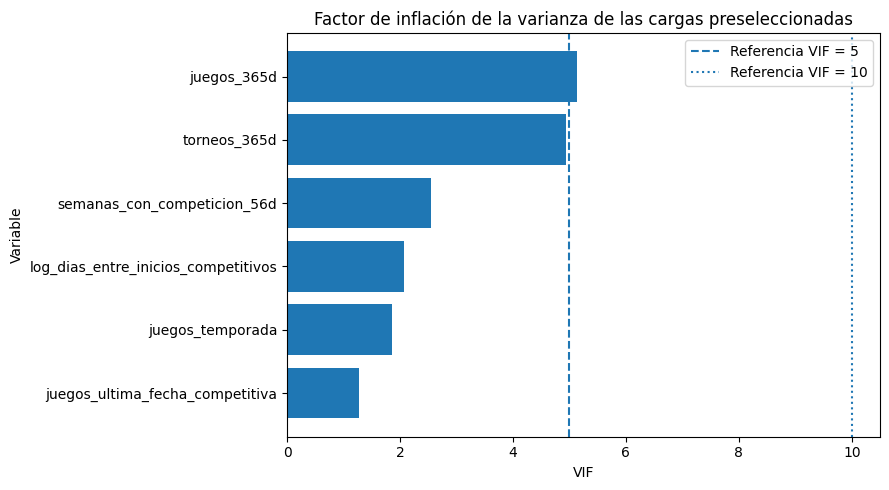

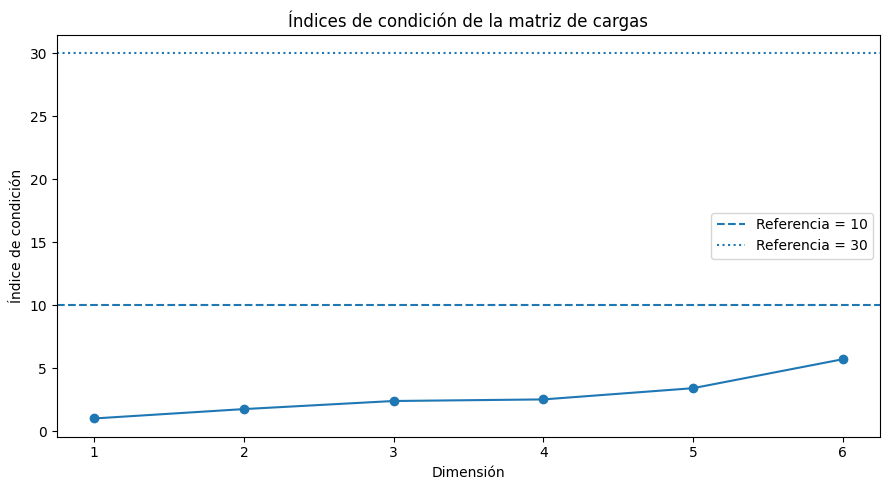

Diagnóstico multivariante de colinealidad completado.


In [23]:

# ============================================================
# 8.7. VIF, TOLERANCIA E ÍNDICES DE CONDICIÓN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


# ------------------------------------------------------------
# 1. Preparación de la matriz de predictores
# ------------------------------------------------------------

X_colinealidad = (
    data_muestra_principal[
        variables_carga_preseleccion_principal
    ]
    .astype(float)
    .copy()
)


assert len(X_colinealidad) == len(data_muestra_principal)
assert X_colinealidad.notna().all().all()
assert X_colinealidad.nunique().gt(1).all()


# Estandarización para mejorar la comparabilidad numérica.
escalador_colinealidad = StandardScaler()

X_estandarizada = pd.DataFrame(
    escalador_colinealidad.fit_transform(
        X_colinealidad
    ),
    columns=variables_carga_preseleccion_principal,
    index=X_colinealidad.index
)


assert np.allclose(
    X_estandarizada.mean().to_numpy(),
    0,
    atol=1e-10
)


# ------------------------------------------------------------
# 2. Factor de inflación de la varianza
# ------------------------------------------------------------

# Se incorpora una constante para que las regresiones auxiliares
# utilizadas en el VIF tengan intercepto.
X_vif = sm.add_constant(
    X_estandarizada,
    has_constant="add"
)


resultados_vif = []


for posicion, variable in enumerate(
    variables_carga_preseleccion_principal,
    start=1
):

    vif = variance_inflation_factor(
        X_vif.to_numpy(),
        posicion
    )

    resultados_vif.append(
        {
            "variable": variable,
            "VIF": vif,
            "tolerancia": 1 / vif,
            "R2_auxiliar": 1 - (1 / vif)
        }
    )


tabla_vif = (
    pd.DataFrame(resultados_vif)
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


print("FACTOR DE INFLACIÓN DE LA VARIANZA")

display(
    tabla_vif.style.format(
        {
            "VIF": "{:.3f}",
            "tolerancia": "{:.3f}",
            "R2_auxiliar": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 3. Índices de condición
# ------------------------------------------------------------

# Se escalan las columnas a norma euclídea igual a uno,
# como preparación para la descomposición en valores singulares.
normas_columnas = np.linalg.norm(
    X_estandarizada.to_numpy(),
    axis=0
)


X_norma_unidad = (
    X_estandarizada.to_numpy()
    / normas_columnas
)


U, valores_singulares, Vt = np.linalg.svd(
    X_norma_unidad,
    full_matrices=False
)


autovalores = valores_singulares ** 2

indices_condicion = (
    valores_singulares.max()
    / valores_singulares
)


tabla_indices_condicion = pd.DataFrame(
    {
        "dimension": np.arange(
            1,
            len(valores_singulares) + 1
        ),
        "autovalor": autovalores,
        "valor_singular": valores_singulares,
        "indice_condicion": indices_condicion
    }
)


print("ÍNDICES DE CONDICIÓN")

display(
    tabla_indices_condicion.style.format(
        {
            "autovalor": "{:.6f}",
            "valor_singular": "{:.6f}",
            "indice_condicion": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 4. Proporciones de descomposición de la varianza
# ------------------------------------------------------------

# Cada elemento representa la contribución de una dimensión
# a la varianza del coeficiente asociado a una variable.
V = Vt.T


componentes_varianza = (
    V ** 2
    / autovalores[np.newaxis, :]
)


proporciones_varianza = (
    componentes_varianza
    / componentes_varianza.sum(
        axis=1,
        keepdims=True
    )
)


tabla_proporciones_varianza = pd.DataFrame(
    proporciones_varianza.T,
    columns=variables_carga_preseleccion_principal
)


tabla_proporciones_varianza.insert(
    0,
    "indice_condicion",
    indices_condicion
)

tabla_proporciones_varianza.insert(
    0,
    "dimension",
    np.arange(
        1,
        len(indices_condicion) + 1
    )
)


print("PROPORCIONES DE DESCOMPOSICIÓN DE LA VARIANZA")

display(
    tabla_proporciones_varianza.style.format(
        {
            columna: "{:.3f}"
            for columna
            in tabla_proporciones_varianza.columns
            if columna != "dimension"
        }
    )
)


# ------------------------------------------------------------
# 5. Representación del VIF
# ------------------------------------------------------------

tabla_vif_grafico = (
    tabla_vif
    .sort_values(
        "VIF",
        ascending=True
    )
)


figura, eje = plt.subplots(
    figsize=(9, 5)
)


eje.barh(
    tabla_vif_grafico["variable"],
    tabla_vif_grafico["VIF"]
)


eje.axvline(
    5,
    linestyle="--",
    linewidth=1.5,
    label="Referencia VIF = 5"
)

eje.axvline(
    10,
    linestyle=":",
    linewidth=1.5,
    label="Referencia VIF = 10"
)


eje.set_title(
    "Factor de inflación de la varianza "
    "de las cargas preseleccionadas"
)

eje.set_xlabel("VIF")
eje.set_ylabel("Variable")
eje.legend()


figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Representación de los índices de condición
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(9, 5)
)


eje.plot(
    tabla_indices_condicion["dimension"],
    tabla_indices_condicion["indice_condicion"],
    marker="o"
)


eje.axhline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="Referencia = 10"
)

eje.axhline(
    30,
    linestyle=":",
    linewidth=1.5,
    label="Referencia = 30"
)


eje.set_title(
    "Índices de condición de la matriz de cargas"
)

eje.set_xlabel("Dimensión")
eje.set_ylabel("Índice de condición")
eje.legend()


figura.tight_layout()
plt.show()


print(
    "Diagnóstico multivariante de colinealidad completado."
)



## 9. Relación descriptiva entre la carga competitiva y el rendimiento

Una vez estudiada la redundancia entre las variables de carga, se analizará su relación con la variable objetivo principal:

```text
porcentaje_juegos_ganados
```

En una primera aproximación se calcularán:

* la correlación de Pearson, para identificar asociaciones lineales;
* la correlación de Spearman, para identificar asociaciones monótonas;
* el coeficiente Kendall tau-b, para medir concordancia considerando los empates.

El análisis se complementará dividiendo cada variable de carga en grupos ordenados y calculando el rendimiento medio dentro de cada grupo. Esto permitirá detectar relaciones no lineales que podrían quedar ocultas en un único coeficiente de correlación.

Para las variables continuas se utilizarán deciles. Las variables con pocos valores distintos, como `semanas_con_competicion_56d`, se analizarán utilizando directamente sus categorías observadas.

Los resultados de esta sección serán exclusivamente descriptivos. Una asociación entre carga y rendimiento no podrá interpretarse directamente como un efecto de fatiga, ya que las cargas también pueden reflejar:

* el nivel competitivo del jugador;
* su continuidad en el circuito;
* su capacidad para avanzar rondas;
* la calidad del rival;
* el momento de la temporada.

Además, las dos observaciones correspondientes a un mismo partido no son independientes. Por este motivo, no se utilizarán los valores (p) como criterio de selección.

La utilidad real de las cargas deberá evaluarse posteriormente mediante modelos que incorporen los predictores tradicionales y mediante variables relativas respecto al rival.


Observaciones utilizadas: 74553
Media global del rendimiento: 0.5018
ASOCIACIÓN ENTRE LAS CARGAS Y EL PORCENTAJE DE JUEGOS GANADOS


,variable,pearson,spearman,kendall_tau_b,abs_pearson,abs_spearman,abs_kendall_tau_b
0,juegos_365d,0.2080,0.2150,0.1460,0.2080,0.2150,0.1460
1,juegos_ultima_fecha_competitiva,0.1423,0.1447,0.0979,0.1423,0.1447,0.0979
2,juegos_temporada,0.1125,0.1180,0.0799,0.1125,0.1180,0.0799
3,torneos_365d,0.1120,0.0989,0.0675,0.1120,0.0989,0.0675
4,semanas_con_competicion_56d,0.0625,0.0602,0.0435,0.0625,0.0602,0.0435
5,log_dias_entre_inicios_competitivos,-0.0769,-0.0461,-0.0324,0.0769,0.0461,0.0324


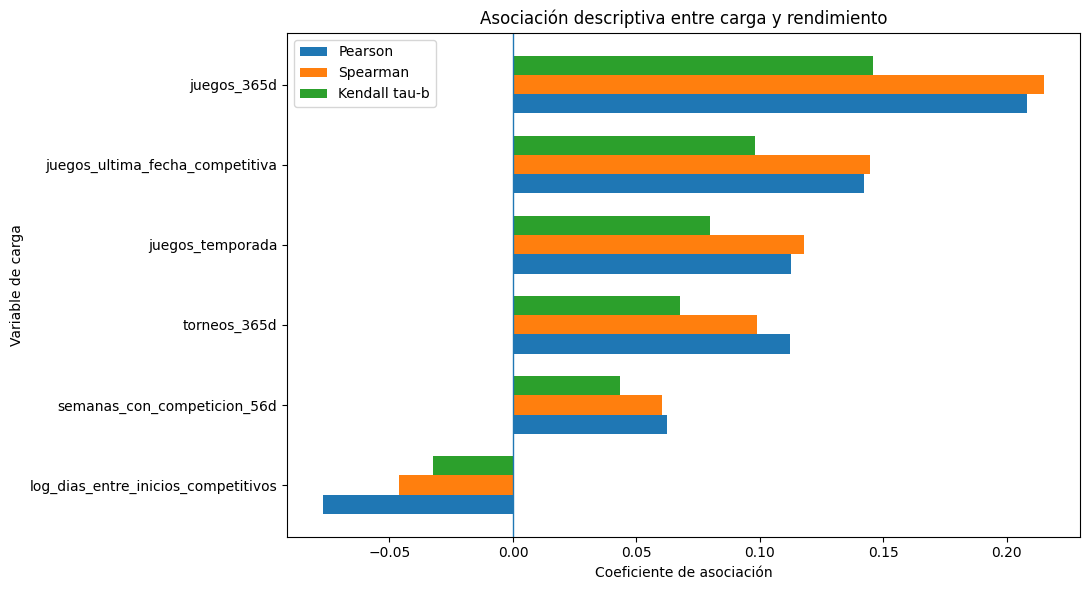

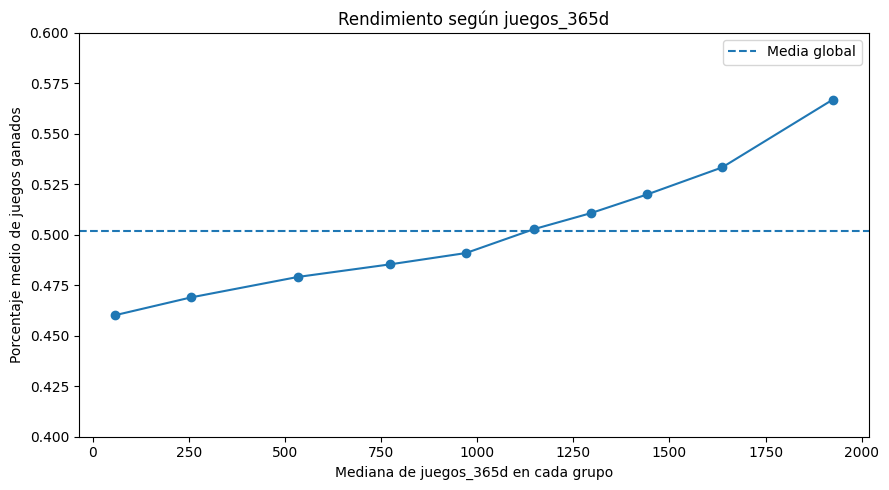

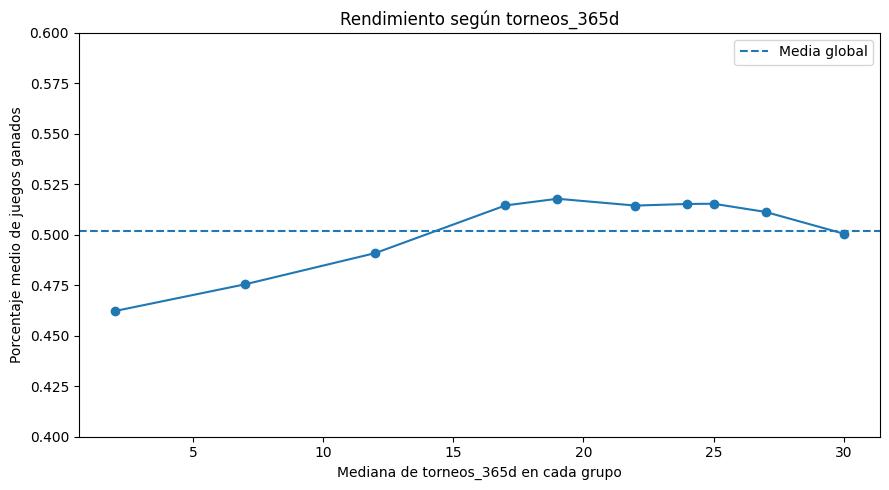

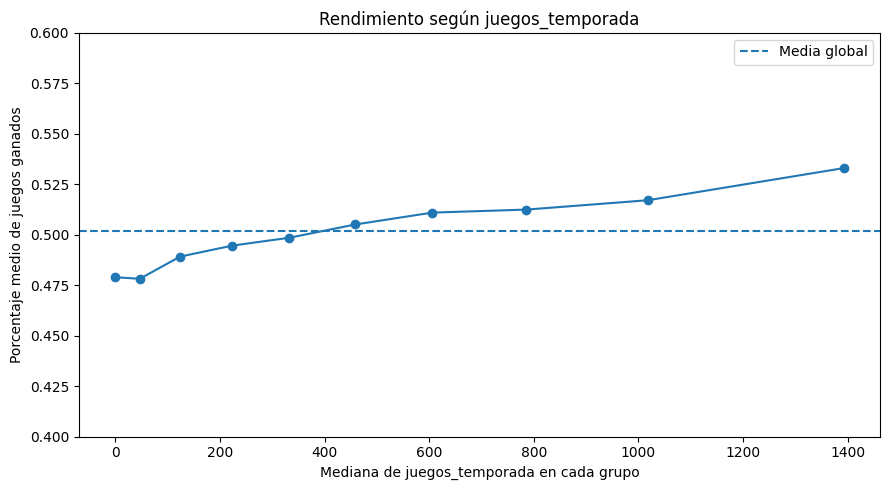

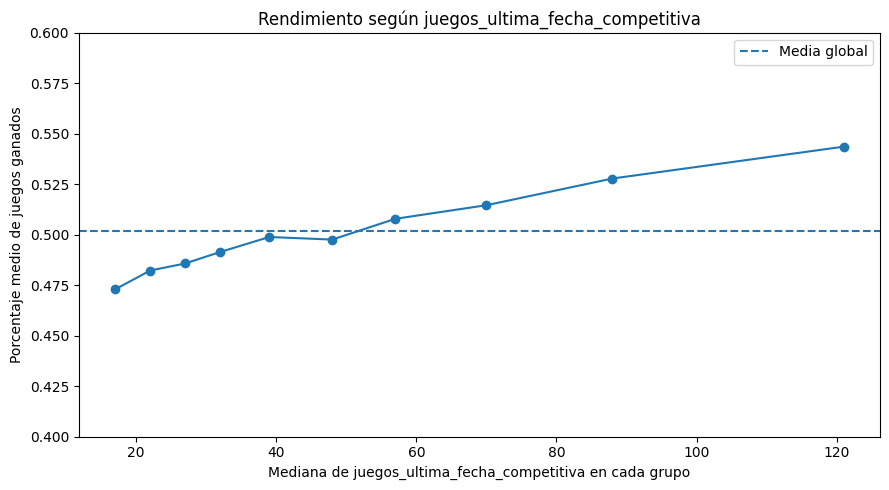

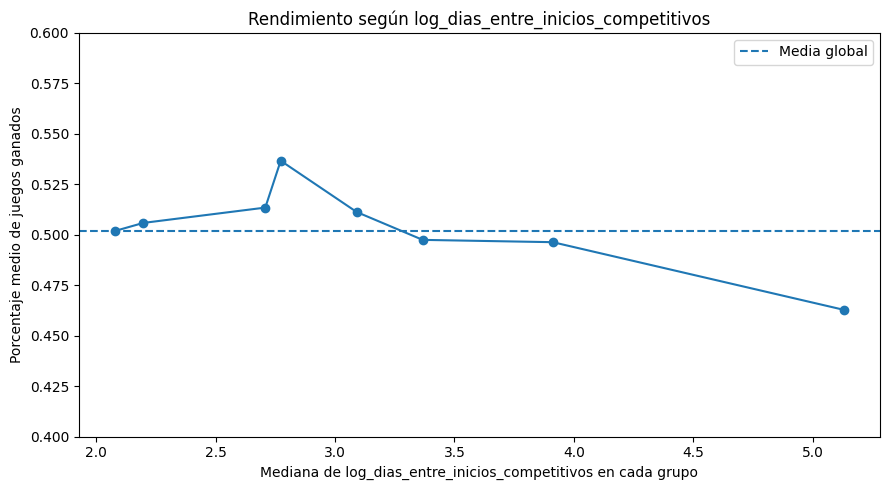

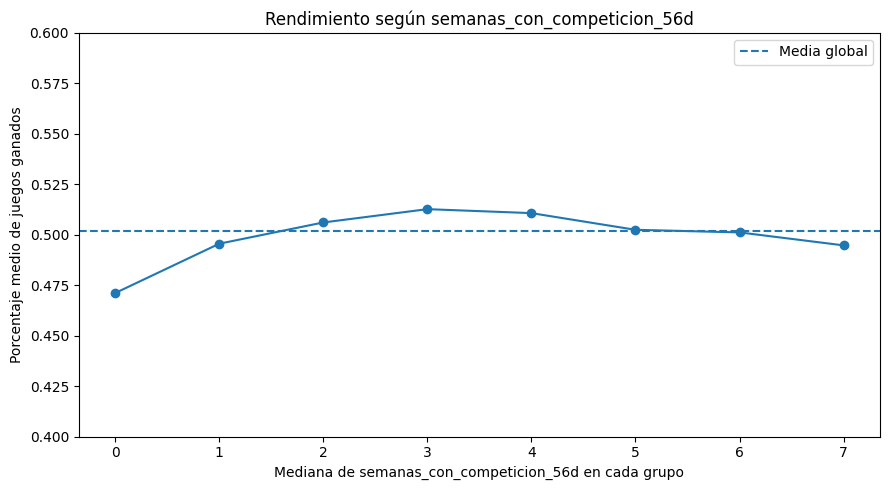

AMPLITUD DEL RENDIMIENTO ENTRE NIVELES DE CARGA


,variable,rendimiento_minimo,rendimiento_maximo,numero_grupos,amplitud_rendimiento
0,juegos_365d,0.4601,0.5669,10,0.1069
1,log_dias_entre_inicios_competitivos,0.4628,0.5366,8,0.0738
2,juegos_ultima_fecha_competitiva,0.4730,0.5436,10,0.0707
3,torneos_365d,0.4622,0.5178,10,0.0556
4,juegos_temporada,0.4782,0.5330,10,0.0548
5,semanas_con_competicion_56d,0.4711,0.5127,8,0.0416


Análisis descriptivo de carga y rendimiento completado.


In [24]:

# ============================================================
# 9.1. ASOCIACIÓN DESCRIPTIVA ENTRE CARGA Y RENDIMIENTO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau
)


variable_objetivo = "porcentaje_juegos_ganados"


# ------------------------------------------------------------
# 1. Preparación de la muestra
# ------------------------------------------------------------

datos_rendimiento = (
    data_muestra_principal[
        variables_carga_preseleccion_principal
        + [variable_objetivo]
    ]
    .astype(float)
    .copy()
)


assert len(datos_rendimiento) == len(data_muestra_principal)
assert datos_rendimiento.notna().all().all()

assert datos_rendimiento[
    variable_objetivo
].between(0, 1).all()


print(
    "Observaciones utilizadas:",
    len(datos_rendimiento)
)

print(
    "Media global del rendimiento:",
    round(
        datos_rendimiento[
            variable_objetivo
        ].mean(),
        4
    )
)


# ------------------------------------------------------------
# 2. Pearson, Spearman y Kendall tau-b
# ------------------------------------------------------------

resultados_asociacion = []


for variable in variables_carga_preseleccion_principal:

    x = datos_rendimiento[variable]
    y = datos_rendimiento[variable_objetivo]

    coeficiente_pearson = pearsonr(
        x,
        y
    ).statistic

    coeficiente_spearman = spearmanr(
        x,
        y
    ).statistic

    coeficiente_kendall = kendalltau(
        x,
        y,
        variant="b"
    ).statistic


    resultados_asociacion.append(
        {
            "variable": variable,
            "pearson": coeficiente_pearson,
            "spearman": coeficiente_spearman,
            "kendall_tau_b": coeficiente_kendall,
            "abs_pearson": abs(coeficiente_pearson),
            "abs_spearman": abs(coeficiente_spearman),
            "abs_kendall_tau_b": abs(
                coeficiente_kendall
            )
        }
    )


tabla_asociacion_rendimiento = (
    pd.DataFrame(resultados_asociacion)
    .sort_values(
        "abs_spearman",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "ASOCIACIÓN ENTRE LAS CARGAS "
    "Y EL PORCENTAJE DE JUEGOS GANADOS"
)

display(
    tabla_asociacion_rendimiento.style.format(
        {
            "pearson": "{:.4f}",
            "spearman": "{:.4f}",
            "kendall_tau_b": "{:.4f}",
            "abs_pearson": "{:.4f}",
            "abs_spearman": "{:.4f}",
            "abs_kendall_tau_b": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 3. Comparación gráfica de los coeficientes
# ------------------------------------------------------------

tabla_grafico = (
    tabla_asociacion_rendimiento
    .sort_values(
        "abs_spearman",
        ascending=True
    )
    .copy()
)


posiciones = np.arange(
    len(tabla_grafico)
)

altura = 0.24


figura, eje = plt.subplots(
    figsize=(11, 6)
)


eje.barh(
    posiciones - altura,
    tabla_grafico["pearson"],
    height=altura,
    label="Pearson"
)

eje.barh(
    posiciones,
    tabla_grafico["spearman"],
    height=altura,
    label="Spearman"
)

eje.barh(
    posiciones + altura,
    tabla_grafico["kendall_tau_b"],
    height=altura,
    label="Kendall tau-b"
)


eje.set_yticks(
    posiciones
)

eje.set_yticklabels(
    tabla_grafico["variable"]
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_xlabel(
    "Coeficiente de asociación"
)

eje.set_ylabel(
    "Variable de carga"
)

eje.set_title(
    "Asociación descriptiva entre carga y rendimiento"
)

eje.legend()

figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Función para estudiar el rendimiento por niveles de carga
# ------------------------------------------------------------

def resumen_rendimiento_por_carga(
    df,
    variable,
    objetivo,
    numero_grupos=10
):
    """
    Agrupa una variable de carga y calcula el rendimiento
    medio dentro de cada nivel.

    Si la variable tiene pocos valores distintos, utiliza
    directamente sus valores observados. En caso contrario,
    utiliza grupos definidos mediante cuantiles.
    """

    datos = (
        df[
            [
                variable,
                objetivo
            ]
        ]
        .dropna()
        .copy()
    )


    numero_valores_unicos = (
        datos[variable].nunique()
    )


    if numero_valores_unicos <= numero_grupos:

        datos["grupo_carga"] = datos[variable]

        resumen = (
            datos
            .groupby(
                "grupo_carga",
                as_index=False
            )
            .agg(
                observaciones=(
                    objetivo,
                    "size"
                ),
                carga_media=(
                    variable,
                    "mean"
                ),
                carga_mediana=(
                    variable,
                    "median"
                ),
                rendimiento_medio=(
                    objetivo,
                    "mean"
                ),
                rendimiento_mediano=(
                    objetivo,
                    "median"
                )
            )
        )

        resumen["tipo_agrupacion"] = (
            "Valores observados"
        )


    else:

        datos["grupo_carga"] = pd.qcut(
            datos[variable],
            q=numero_grupos,
            labels=False,
            duplicates="drop"
        )


        resumen = (
            datos
            .groupby(
                "grupo_carga",
                as_index=False
            )
            .agg(
                observaciones=(
                    objetivo,
                    "size"
                ),
                carga_media=(
                    variable,
                    "mean"
                ),
                carga_mediana=(
                    variable,
                    "median"
                ),
                rendimiento_medio=(
                    objetivo,
                    "mean"
                ),
                rendimiento_mediano=(
                    objetivo,
                    "median"
                )
            )
        )


        resumen["grupo_carga"] = (
            resumen["grupo_carga"] + 1
        )

        resumen["tipo_agrupacion"] = (
            "Cuantiles"
        )


    resumen["variable"] = variable

    return resumen


# ------------------------------------------------------------
# 5. Resúmenes y gráficos por niveles de carga
# ------------------------------------------------------------

resumenes_carga_rendimiento = []


for variable in variables_carga_preseleccion_principal:

    resumen_variable = (
        resumen_rendimiento_por_carga(
            datos_rendimiento,
            variable,
            variable_objetivo,
            numero_grupos=10
        )
    )


    resumenes_carga_rendimiento.append(
        resumen_variable
    )


    figura, eje = plt.subplots(
        figsize=(9, 5)
    )


    eje.plot(
        resumen_variable["carga_mediana"],
        resumen_variable["rendimiento_medio"],
        marker="o"
    )


    eje.axhline(
        datos_rendimiento[
            variable_objetivo
        ].mean(),
        linestyle="--",
        linewidth=1.5,
        label="Media global"
    )


    eje.set_title(
        f"Rendimiento según {variable}"
    )

    eje.set_xlabel(
        f"Mediana de {variable} en cada grupo"
    )

    eje.set_ylabel(
        "Porcentaje medio de juegos ganados"
    )

    eje.set_ylim(
        0.40,
        0.60
    )

    eje.legend()

    figura.tight_layout()
    plt.show()


tabla_rendimiento_por_carga = pd.concat(
    resumenes_carga_rendimiento,
    ignore_index=True
)


# ------------------------------------------------------------
# 6. Amplitud descriptiva del rendimiento entre grupos
# ------------------------------------------------------------

resumen_amplitud_rendimiento = (
    tabla_rendimiento_por_carga
    .groupby(
        "variable",
        as_index=False
    )
    .agg(
        rendimiento_minimo=(
            "rendimiento_medio",
            "min"
        ),
        rendimiento_maximo=(
            "rendimiento_medio",
            "max"
        ),
        numero_grupos=(
            "grupo_carga",
            "nunique"
        )
    )
)


resumen_amplitud_rendimiento[
    "amplitud_rendimiento"
] = (
    resumen_amplitud_rendimiento[
        "rendimiento_maximo"
    ]
    - resumen_amplitud_rendimiento[
        "rendimiento_minimo"
    ]
)


resumen_amplitud_rendimiento = (
    resumen_amplitud_rendimiento
    .sort_values(
        "amplitud_rendimiento",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "AMPLITUD DEL RENDIMIENTO ENTRE NIVELES DE CARGA"
)

display(
    resumen_amplitud_rendimiento.style.format(
        {
            "rendimiento_minimo": "{:.4f}",
            "rendimiento_maximo": "{:.4f}",
            "amplitud_rendimiento": "{:.4f}"
        }
    )
)


print(
    "Análisis descriptivo de carga y rendimiento completado."
)



### 9.2. Interpretación de la asociación descriptiva con el rendimiento

Las seis variables de carga presentan asociaciones brutas de magnitud reducida con el porcentaje de juegos ganados. La mayor relación monotónica corresponde a `juegos_365d`, con un coeficiente de Spearman de 0,2150, seguida por la carga de la última participación y los juegos acumulados durante la temporada.

Las relaciones positivas no deben interpretarse como evidencia de que una mayor carga mejore el rendimiento. Las medidas de volumen también actúan como indicadores indirectos de calidad, continuidad y éxito competitivo, ya que los jugadores que avanzan más rondas acumulan más juegos y partidos.

Los análisis por niveles de carga muestran tres tipos de patrones:

* una relación creciente para `juegos_365d`, `juegos_temporada` y `juegos_ultima_fecha_competitiva`;
* una relación no lineal para `torneos_365d`;
* patrones compatibles con una U invertida para el intervalo entre participaciones y la densidad de competición reciente.

En particular, `semanas_con_competicion_56d` presenta el mejor rendimiento en niveles intermedios de actividad y un descenso en las categorías de máxima densidad. Este resultado es compatible con un posible equilibrio entre ritmo competitivo y fatiga, pero no constituye una evidencia causal.

Las asociaciones deberán reevaluarse incorporando la carga del rival, los predictores tradicionales y los factores contextuales del partido.


## 10. Cargas del rival y diferencias relativas

La carga absoluta de un jugador puede resultar insuficiente para explicar su rendimiento si no se tiene en cuenta la situación de su oponente. Por este motivo, para cada variable de carga se incorporará:

* el valor correspondiente al rival;
* la diferencia entre el jugador y el rival.

Para una variable de carga ($X$), la diferencia relativa se define como:

$$
\Delta X_{i,m}
=
 X_{i,m}-
X_{r(i,m),m},
$$

donde ($X_{i,m}$) representa la carga del jugador ($i$) antes del partido ($m$), y ($X_{r(i,m),m}$) representa la carga de su rival antes del mismo encuentro.

La interpretación será:

* ($\Delta X_{i,m}>0$): el jugador presenta más carga que su rival;
* ($\Delta X_{i,m}<0)$: el rival presenta más carga;
* ($\Delta X_{i,m}=0$): ambos presentan la misma carga.

Como cada partido dispone de dos filas recíprocas, las diferencias de ambos jugadores deben tener el mismo valor absoluto y signo contrario.


In [25]:

# ============================================================
# 10. CARGAS DEL RIVAL Y DIFERENCIAS RELATIVAS
# ============================================================

import numpy as np
import pandas as pd


columna_partido = "_id_partido"


# ------------------------------------------------------------
# 1. Variables para las que se construirá la versión del rival
# ------------------------------------------------------------

variables_carga_rival = [
    # Ventana principal
    "juegos_365d",
    "torneos_365d",

    # Ventana de robustez
    "juegos_180d",
    "torneos_180d",

    # Temporada
    "juegos_temporada",

    # Carga inmediata
    "juegos_ultima_fecha_competitiva",

    # Separación entre participaciones
    "dias_entre_inicios_competitivos",
    "log_dias_entre_inicios_competitivos",

    # Densidad reciente
    "semanas_con_competicion_56d"
]


# ------------------------------------------------------------
# 2. Comprobaciones previas
# ------------------------------------------------------------

assert columna_partido in data.columns

variables_ausentes = [
    variable
    for variable in variables_carga_rival
    if variable not in data.columns
]

assert not variables_ausentes, (
    f"Faltan variables en data: {variables_ausentes}"
)


filas_por_partido = (
    data.groupby(columna_partido)
    .size()
)

assert filas_por_partido.eq(2).all()


jugadores_por_partido = (
    data.groupby(columna_partido)[
        "jugador_id"
    ]
    .nunique()
)

assert jugadores_por_partido.eq(2).all()


print(
    "Partidos comprobados:",
    data[columna_partido].nunique()
)


# ------------------------------------------------------------
# 3. Construcción de las variables del rival
# ------------------------------------------------------------

for variable in variables_carga_rival:

    variable_rival = f"{variable}_rival"
    variable_diferencia = f"diff_{variable}"


    grupo_partido = data.groupby(
        columna_partido
    )[variable]


    # En cada grupo existen exactamente dos filas:
    # la primera recibe el valor de la segunda y viceversa.
    data[variable_rival] = (
        grupo_partido.shift(-1)
        .combine_first(
            grupo_partido.shift(1)
        )
    )


    data[variable_diferencia] = (
        data[variable]
        - data[variable_rival]
    )


# ------------------------------------------------------------
# 4. Validaciones
# ------------------------------------------------------------

for variable in variables_carga_rival:

    variable_rival = f"{variable}_rival"
    variable_diferencia = f"diff_{variable}"


    # Al intercambiar los valores dentro de cada partido,
    # el número global de nulos debe mantenerse.
    assert (
        data[variable].isna().sum()
        ==
        data[variable_rival].isna().sum()
    )


    # La diferencia debe ser nula cuando falta el valor
    # del jugador o el del rival.
    mascara_nulo_esperada = (
        data[variable].isna()
        | data[variable_rival].isna()
    )

    assert data[
        variable_diferencia
    ].isna().equals(
        mascara_nulo_esperada
    )


    # Las dos diferencias de un mismo partido deben sumar cero.
    suma_diferencias_partido = (
        data.groupby(
            columna_partido
        )[variable_diferencia]
        .sum(min_count=2)
        .dropna()
    )

    assert np.allclose(
        suma_diferencias_partido,
        0,
        atol=1e-10
    )


# ------------------------------------------------------------
# 5. Resumen de las nuevas variables
# ------------------------------------------------------------

columnas_rival_creadas = [
    f"{variable}_rival"
    for variable in variables_carga_rival
]

columnas_diferencia_creadas = [
    f"diff_{variable}"
    for variable in variables_carga_rival
]


print(
    "Variables del rival creadas:",
    len(columnas_rival_creadas)
)

print(
    "Variables diferenciales creadas:",
    len(columnas_diferencia_creadas)
)

print(
    "Dimensiones actuales de data:",
    data.shape
)


columnas_muestra = [
    columna_partido,
    "jugador_id",
    "jugador_nombre",
    "juegos_365d",
    "juegos_365d_rival",
    "diff_juegos_365d",
    "juegos_ultima_fecha_competitiva",
    "juegos_ultima_fecha_competitiva_rival",
    "diff_juegos_ultima_fecha_competitiva",
    "log_dias_entre_inicios_competitivos",
    "log_dias_entre_inicios_competitivos_rival",
    "diff_log_dias_entre_inicios_competitivos"
]


display(
    data[
        columnas_muestra
    ].head(12)
)


print(
    "Cargas del rival y diferencias relativas "
    "construidas correctamente."
)



Partidos comprobados: 47015
Variables del rival creadas: 9
Variables diferenciales creadas: 9
Dimensiones actuales de data: (94030, 121)


,_id_partido,jugador_id,jugador_nombre,juegos_365d,juegos_365d_rival,diff_juegos_365d,juegos_ultima_fecha_competitiva,juegos_ultima_fecha_competitiva_rival,diff_juegos_ultima_fecha_competitiva,log_dias_entre_inicios_competitivos,log_dias_entre_inicios_competitivos_rival,diff_log_dias_entre_inicios_competitivos
0,2008-339__1,104534,Dudi Sela,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-339__1,103720,Lleyton Hewitt,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-339__2,104268,Alejandro Falla,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-339__2,104076,Jose Acasuso,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-339__3,104979,Andrey Golubev,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2008-339__3,105208,Ernests Gulbis,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2008-339__4,104542,Jo-Wilfried Tsonga,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
7,2008-339__4,103812,Victor Hanescu,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
8,2008-339__5,103657,Ivo Klec,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2008-339__5,103813,Jarkko Nieminen,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


Cargas del rival y diferencias relativas construidas correctamente.


## 10.1. Definición de muestras emparejadas

Para analizar las diferencias de carga es necesario que las dos observaciones de cada partido cumplan simultáneamente los requisitos de información.

No sería adecuado conservar una fila cuando el jugador dispone de historial completo, pero su rival no, ya que en ese caso la diferencia de carga no estaría disponible de forma comparable.

Se construirán muestras emparejadas en las que:

* ambos jugadores dispongan del historial temporal requerido;
* ambos tengan una participación competitiva anterior;
* la variable objetivo esté disponible para las dos observaciones;
* cada partido conserve exactamente sus dos filas recíprocas.

La muestra principal utilizará el historial completo de 365 días. También se conservarán muestras alternativas para las ventanas de 180 y 56 días.


In [26]:

# ============================================================
# 10.1. MUESTRAS EMPAREJADAS JUGADOR–RIVAL
# ============================================================

import numpy as np
import pandas as pd


columna_partido = "_id_partido"
variable_objetivo = "porcentaje_juegos_ganados"


# ------------------------------------------------------------
# 1. Indicadores de disponibilidad para ambos jugadores
# ------------------------------------------------------------

data["historial_365d_completo_ambos"] = (
    data
    .groupby(columna_partido)[
        "historial_365d_completo"
    ]
    .transform("all")
)


data["historial_180d_completo_ambos"] = (
    data
    .groupby(columna_partido)[
        "historial_180d_completo"
    ]
    .transform("all")
)


data["historial_56d_completo_ambos"] = (
    data
    .groupby(columna_partido)[
        "historial_56d_completo"
    ]
    .transform("all")
)


data["historial_anterior_disponible_ambos"] = (
    data
    .groupby(columna_partido)[
        "historial_anterior_disponible"
    ]
    .transform("all")
)


data["objetivo_disponible_ambos"] = (
    data[variable_objetivo]
    .notna()
    .groupby(data[columna_partido])
    .transform("all")
)


# ------------------------------------------------------------
# 2. Máscaras emparejadas
# ------------------------------------------------------------

mascara_principal_emparejada = (
    data["historial_365d_completo_ambos"]
    & data["historial_anterior_disponible_ambos"]
    & data["objetivo_disponible_ambos"]
)


mascara_180d_emparejada = (
    data["historial_180d_completo_ambos"]
    & data["historial_anterior_disponible_ambos"]
    & data["objetivo_disponible_ambos"]
)


mascara_56d_emparejada = (
    data["historial_56d_completo_ambos"]
    & data["historial_anterior_disponible_ambos"]
    & data["objetivo_disponible_ambos"]
)


# ------------------------------------------------------------
# 3. Creación de muestras emparejadas separando desarrollo y validación
# ------------------------------------------------------------

mascara_principal_emparejada_desarrollo = (
    mascara_principal_emparejada
    & data["es_desarrollo_modelo"].eq(1)
)

mascara_principal_emparejada_validacion = (
    mascara_principal_emparejada
    & data["es_validacion_temporal"].eq(1)
)

mascara_180d_emparejada_desarrollo = (
    mascara_180d_emparejada
    & data["es_desarrollo_modelo"].eq(1)
)

mascara_180d_emparejada_validacion = (
    mascara_180d_emparejada
    & data["es_validacion_temporal"].eq(1)
)

mascara_56d_emparejada_desarrollo = (
    mascara_56d_emparejada
    & data["es_desarrollo_modelo"].eq(1)
)

# Muestras de desarrollo: se usan para análisis y selección.
data_muestra_principal_emparejada = (
    data.loc[mascara_principal_emparejada_desarrollo]
    .copy()
)

data_robustez_180d_emparejada = (
    data.loc[mascara_180d_emparejada_desarrollo]
    .copy()
)

data_analisis_56d_emparejada = (
    data.loc[mascara_56d_emparejada_desarrollo]
    .copy()
)

# Muestras de validación: se preparan para el notebook posterior,
# pero no se usan para decidir variables.
data_validacion_principal_365d = (
    data.loc[mascara_principal_emparejada_validacion]
    .copy()
)

data_validacion_robustez_180d = (
    data.loc[mascara_180d_emparejada_validacion]
    .copy()
)


# ------------------------------------------------------------
# 4. Validaciones de la estructura emparejada
# ------------------------------------------------------------

muestras_emparejadas = {
    "Principal 365d desarrollo": data_muestra_principal_emparejada,
    "Robustez 180d desarrollo": data_robustez_180d_emparejada,
    "Análisis 56d desarrollo": data_analisis_56d_emparejada,
    "Principal 365d — evaluación externa": data_validacion_principal_365d,
    "Robustez 180d — evaluación externa": data_validacion_robustez_180d
}


for nombre_muestra, muestra in muestras_emparejadas.items():

    assert len(muestra) > 0, (
        f"La muestra {nombre_muestra} está vacía."
    )

    assert (
        muestra.groupby("_id_partido")
        .size()
        .eq(2)
        .all()
    ), (
        f"Algún partido no conserva dos perspectivas en {nombre_muestra}."
    )

# ------------------------------------------------------------
# 5. Validación de separación temporal
# ------------------------------------------------------------

for muestra in [
    data_muestra_principal_emparejada,
    data_robustez_180d_emparejada,
    data_analisis_56d_emparejada
]:

    assert muestra["es_desarrollo_modelo"].eq(1).all()
    assert muestra["es_validacion_temporal"].eq(0).all()
    assert muestra["es_buffer_carga"].eq(0).all()


for muestra in [
    data_validacion_principal_365d,
    data_validacion_robustez_180d
]:

    assert muestra["es_validacion_temporal"].eq(1).all()
    assert muestra["es_desarrollo_modelo"].eq(0).all()
    assert muestra["es_buffer_carga"].eq(0).all()

# ------------------------------------------------------------
# 6. Comprobación de las variables principales
# ------------------------------------------------------------

variables_relativas_principales = [
    "diff_juegos_365d",
    "diff_torneos_365d",
    "diff_juegos_temporada",
    "diff_juegos_ultima_fecha_competitiva",
    "diff_log_dias_entre_inicios_competitivos",
    "diff_semanas_con_competicion_56d"
]


assert (
    data_muestra_principal_emparejada[
        variables_relativas_principales
    ]
    .notna()
    .all()
    .all()
)


# ------------------------------------------------------------
# 7. Resumen de tamaños
# ------------------------------------------------------------

resumen_muestras_emparejadas = pd.DataFrame(
    {
        "muestra": list(
            muestras_emparejadas.keys()
        ),
        "observaciones_jugador_partido": [
            len(muestra)
            for muestra in muestras_emparejadas.values()
        ],
        "partidos": [
            muestra[columna_partido].nunique()
            for muestra in muestras_emparejadas.values()
        ],
        "jugadores": [
            muestra["jugador_id"].nunique()
            for muestra in muestras_emparejadas.values()
        ]
    }
)


display(
    resumen_muestras_emparejadas.style.format(
        {
            "observaciones_jugador_partido": "{:,.0f}",
            "partidos": "{:,.0f}",
            "jugadores": "{:,.0f}"
        }
    )
)


print(
    "Dimensiones de data:",
    data.shape
)

print(
    "Muestras emparejadas construidas correctamente."
)



,muestra,observaciones_jugador_partido,partidos,jugadores
0,Principal 365d desarrollo,"73,250","36,625","1,176"
1,Robustez 180d desarrollo,"73,450","36,725","1,176"
2,Análisis 56d desarrollo,"73,450","36,725","1,176"
3,Principal 365d — evaluación externa,"5,912","2,956",369
4,Robustez 180d — evaluación externa,"5,912","2,956",369


Dimensiones de data: (94030, 126)
Muestras emparejadas construidas correctamente.


## 10.2. Asociación entre las diferencias de carga y el rendimiento

Las variables relativas permiten estudiar la posición de cada jugador respecto a su rival antes del partido.

Para cada carga (X), se utiliza:

$$
\Delta X_{i,m}
= X_{i,m}-
X_{r(i,m),m}.
$$

Un valor positivo indica que el jugador presenta un valor superior al de su rival, mientras que un valor negativo indica lo contrario.

En el caso de `diff_log_dias_entre_inicios_competitivos`, un valor positivo no representa una mayor carga, sino un intervalo competitivo más prolongado que el del rival.

Las asociaciones se calcularán exclusivamente sobre partidos emparejados. Como las dos filas de cada encuentro son recíprocas, las diferencias presentan el mismo valor absoluto y signo contrario. Del mismo modo, los porcentajes de juegos ganados de ambos jugadores deben sumar uno.

El análisis continuará siendo descriptivo. Las dos perspectivas de un mismo encuentro no deben interpretarse como observaciones estadísticamente independientes; por este motivo, los coeficientes se utilizan para describir la asociación observada y no para realizar inferencia basada en la independencia entre filas.


Media del rendimiento en la muestra emparejada: 0.5
Partidos analizados: 36625
COMPARACIÓN ENTRE CARGAS ABSOLUTAS Y RELATIVAS


,variable_absoluta,variable_relativa,pearson_absoluta,pearson_relativa,spearman_absoluta,spearman_relativa,kendall_absoluta,kendall_relativa
0,juegos_365d,diff_juegos_365d,0.2211,0.3513,0.2267,0.3589,0.1537,0.2435
1,juegos_temporada,diff_juegos_temporada,0.1202,0.2771,0.1265,0.3009,0.0855,0.2030
2,juegos_ultima_fecha_competitiva,diff_juegos_ultima_fecha_competitiva,0.1470,0.2157,0.1482,0.2195,0.1004,0.1484
3,torneos_365d,diff_torneos_365d,0.1226,0.1893,0.1062,0.1767,0.0725,0.1206
4,log_dias_entre_inicios_competitivos,diff_log_dias_entre_inicios_competitivos,-0.0888,-0.1526,-0.0525,-0.1266,-0.0370,-0.0903
5,semanas_con_competicion_56d,diff_semanas_con_competicion_56d,0.0704,0.1237,0.0664,0.1124,0.0480,0.0811


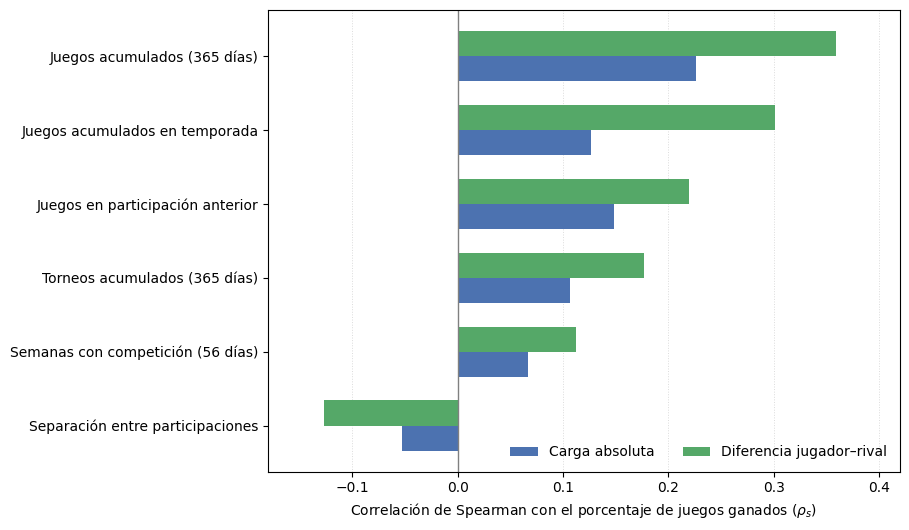

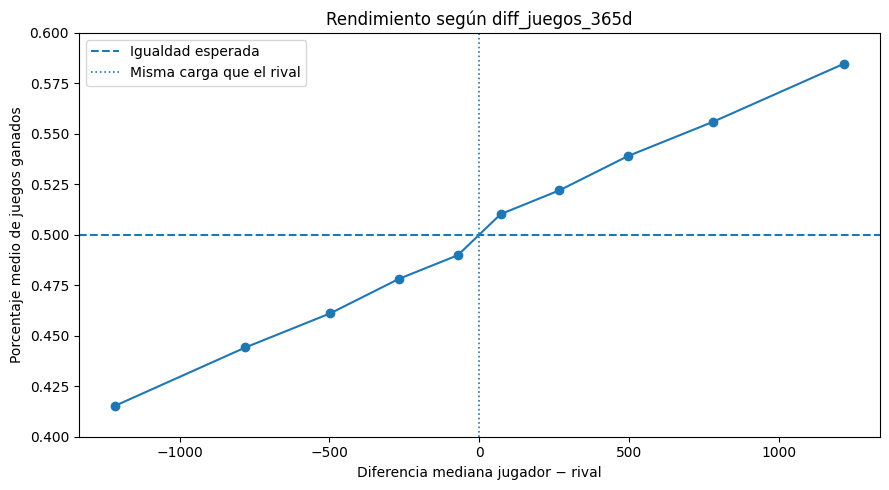

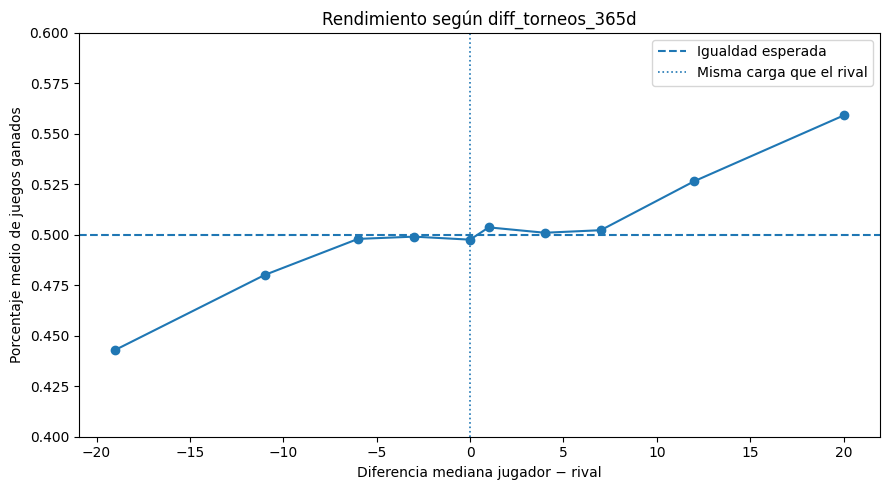

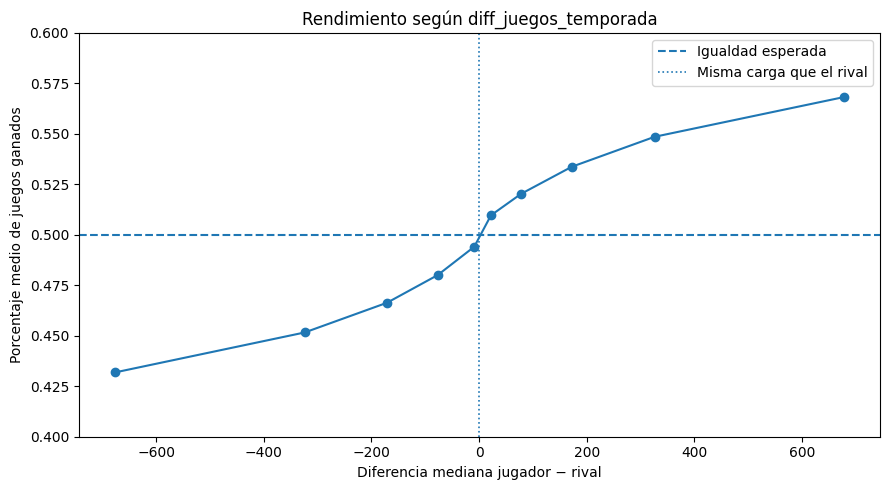

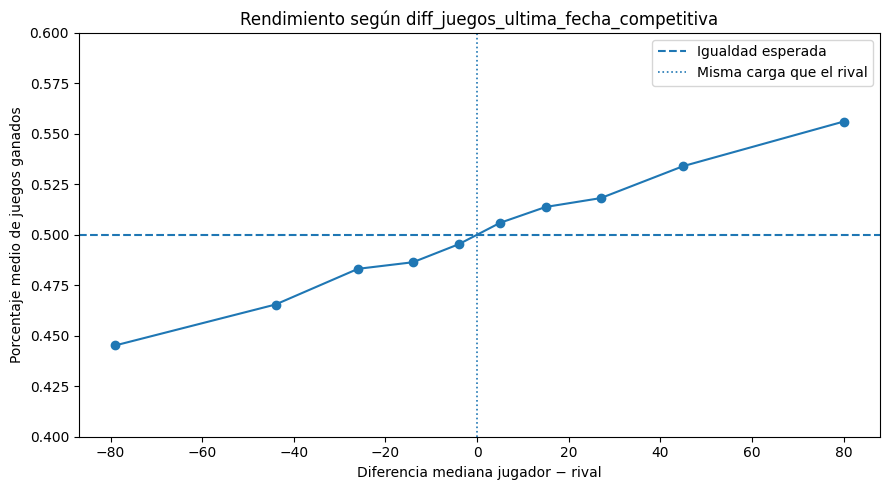

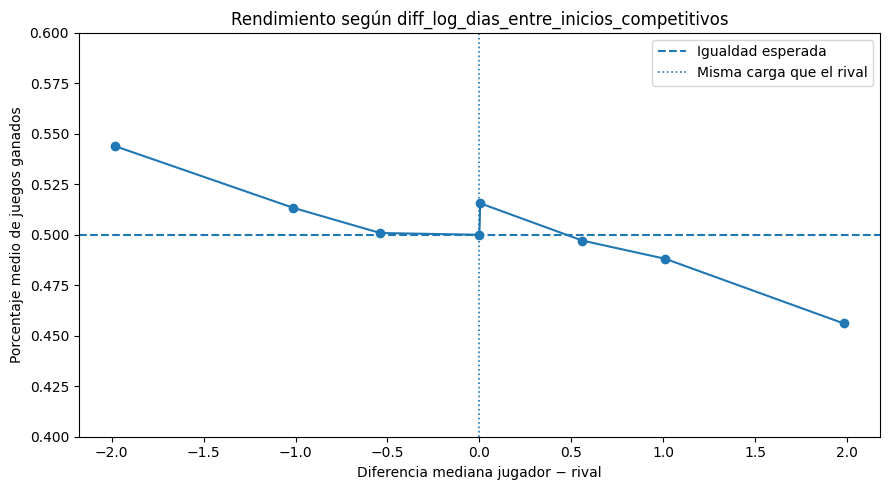

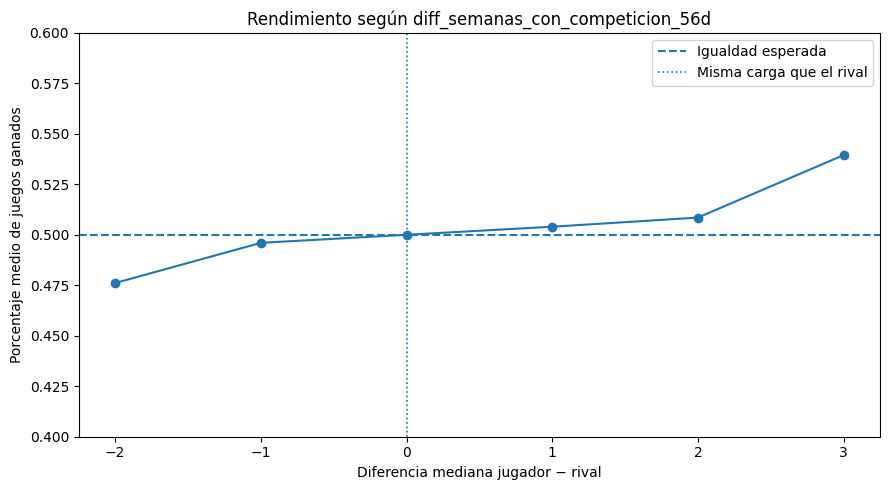

Análisis de cargas relativas completado.


In [27]:

# ============================================================
# 10.2. CARGAS RELATIVAS Y RENDIMIENTO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, kendalltau


muestra_relativa = data_muestra_principal_emparejada.copy()

columna_partido = "_id_partido"
variable_objetivo = "porcentaje_juegos_ganados"


pares_variables = {
    "juegos_365d":
        "diff_juegos_365d",

    "torneos_365d":
        "diff_torneos_365d",

    "juegos_temporada":
        "diff_juegos_temporada",

    "juegos_ultima_fecha_competitiva":
        "diff_juegos_ultima_fecha_competitiva",

    "log_dias_entre_inicios_competitivos":
        "diff_log_dias_entre_inicios_competitivos",

    "semanas_con_competicion_56d":
        "diff_semanas_con_competicion_56d"
}


variables_relativas = list(
    pares_variables.values()
)


# ------------------------------------------------------------
# 1. Comprobaciones de reciprocidad
# ------------------------------------------------------------



assert (
    muestra_relativa[
        variables_relativas + [variable_objetivo]
    ]
    .notna()
    .all()
    .all()
)


# Los porcentajes de juegos ganados de ambos jugadores
# deben sumar uno dentro de cada partido.
suma_objetivo_partido = (
    muestra_relativa
    .groupby(columna_partido)[variable_objetivo]
    .sum()
)


assert np.allclose(
    suma_objetivo_partido,
    1,
    atol=1e-10
)


# Todas las diferencias deben sumar cero dentro del partido.
for variable in variables_relativas:

    suma_diferencia = (
        muestra_relativa
        .groupby(columna_partido)[variable]
        .sum()
    )

    assert np.allclose(
        suma_diferencia,
        0,
        atol=1e-10
    )


print(
    "Media del rendimiento en la muestra emparejada:",
    round(
        muestra_relativa[variable_objetivo].mean(),
        4
    )
)

print(
    "Partidos analizados:",
    muestra_relativa[columna_partido].nunique()
)


# ------------------------------------------------------------
# 2. Comparación entre cargas absolutas y relativas
# ------------------------------------------------------------

resultados_comparacion = []


for variable_absoluta, variable_relativa in (
    pares_variables.items()
):

    y = muestra_relativa[variable_objetivo]

    x_absoluta = muestra_relativa[
        variable_absoluta
    ]

    x_relativa = muestra_relativa[
        variable_relativa
    ]


    resultados_comparacion.append(
        {
            "variable_absoluta":
                variable_absoluta,

            "variable_relativa":
                variable_relativa,

            "pearson_absoluta":
                pearsonr(
                    x_absoluta,
                    y
                ).statistic,

            "pearson_relativa":
                pearsonr(
                    x_relativa,
                    y
                ).statistic,

            "spearman_absoluta":
                spearmanr(
                    x_absoluta,
                    y
                ).statistic,

            "spearman_relativa":
                spearmanr(
                    x_relativa,
                    y
                ).statistic,

            "kendall_absoluta":
                kendalltau(
                    x_absoluta,
                    y,
                    variant="b"
                ).statistic,

            "kendall_relativa":
                kendalltau(
                    x_relativa,
                    y,
                    variant="b"
                ).statistic
        }
    )


tabla_comparacion_cargas = (
    pd.DataFrame(resultados_comparacion)
    .sort_values(
        "spearman_relativa",
        key=np.abs,
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "COMPARACIÓN ENTRE CARGAS ABSOLUTAS Y RELATIVAS"
)

display(
    tabla_comparacion_cargas.style.format(
        {
            "pearson_absoluta": "{:.4f}",
            "pearson_relativa": "{:.4f}",
            "spearman_absoluta": "{:.4f}",
            "spearman_relativa": "{:.4f}",
            "kendall_absoluta": "{:.4f}",
            "kendall_relativa": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 3. Representación de las correlaciones de Spearman
# ------------------------------------------------------------

# Nombres interpretables para la figura del TFG
etiquetas_variables = {
    "juegos_365d":
        "Juegos acumulados (365 días)",

    "juegos_temporada":
        "Juegos acumulados en temporada",

    "juegos_ultima_fecha_competitiva":
        "Juegos en participación anterior",

    "torneos_365d":
        "Torneos acumulados (365 días)",

    "log_dias_entre_inicios_competitivos":
        "Separación entre participaciones",

    "semanas_con_competicion_56d":
        "Semanas con competición (56 días)"
}


# Orden según la magnitud de la asociación relativa
tabla_grafico = (
    tabla_comparacion_cargas
    .sort_values(
        "spearman_relativa",
        ascending=True
    )
    .copy()
)

tabla_grafico["etiqueta"] = (
    tabla_grafico["variable_absoluta"]
    .map(etiquetas_variables)
)


# Posiciones de las barras
posiciones = np.arange(
    len(tabla_grafico)
)

altura = 0.34


# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------

figura_comparacion, eje = plt.subplots(
    figsize=(9.2, 5.4)
)


# Carga absoluta — azul
barras_absolutas = eje.barh(
    posiciones - altura / 2,
    tabla_grafico["spearman_absoluta"],
    height=altura,
    label="Carga absoluta",
    color="#4C72B0"
)


# Diferencia jugador-rival — verde
barras_relativas = eje.barh(
    posiciones + altura / 2,
    tabla_grafico["spearman_relativa"],
    height=altura,
    label="Diferencia jugador–rival",
    color="#55A868"
)


# ------------------------------------------------------------
# Línea de referencia en rho = 0
# ------------------------------------------------------------

eje.axvline(
    0,
    color="gray",
    linewidth=1
)


# ------------------------------------------------------------
# Etiquetas de las variables
# ------------------------------------------------------------

eje.set_yticks(
    posiciones
)

eje.set_yticklabels(
    tabla_grafico["etiqueta"]
)


# ------------------------------------------------------------
# Ejes
# ------------------------------------------------------------

eje.set_xlabel(
    r"Correlación de Spearman con el porcentaje de juegos ganados ($\rho_s$)"
)

eje.set_ylabel("")


# Margen suficiente para valores positivos y negativos
eje.set_xlim(
    -0.18,
    0.42
)


# ------------------------------------------------------------
# Rejilla
# ------------------------------------------------------------

eje.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45
)

eje.set_axisbelow(True)


# ------------------------------------------------------------
# Leyenda
# ------------------------------------------------------------

eje.legend(
    frameon=False,
    ncol=2,
    loc="lower right"
)


# ------------------------------------------------------------
# Formato final
# ------------------------------------------------------------

figura_comparacion.tight_layout()

plt.show()


# ------------------------------------------------------------
# EXPORTACIÓN — activar únicamente cuando la aprobemos
# ------------------------------------------------------------

# figura_comparacion.savefig(
#     "figura_carga_absoluta_vs_relativa_spearman.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.03
# )

# ------------------------------------------------------------
# 4. Rendimiento por niveles de diferencia
# ------------------------------------------------------------

resumenes_relativos = []


for variable in variables_relativas:

    datos_variable = muestra_relativa[
        [
            variable,
            variable_objetivo
        ]
    ].copy()


    datos_variable["grupo"] = pd.qcut(
        datos_variable[variable],
        q=10,
        labels=False,
        duplicates="drop"
    )


    resumen_variable = (
        datos_variable
        .groupby(
            "grupo",
            as_index=False
        )
        .agg(
            observaciones=(
                variable_objetivo,
                "size"
            ),
            diferencia_minima=(
                variable,
                "min"
            ),
            diferencia_mediana=(
                variable,
                "median"
            ),
            diferencia_maxima=(
                variable,
                "max"
            ),
            rendimiento_medio=(
                variable_objetivo,
                "mean"
            )
        )
    )


    resumen_variable["grupo"] = (
        resumen_variable["grupo"] + 1
    )

    resumen_variable["variable"] = variable

    resumenes_relativos.append(
        resumen_variable
    )


    figura, eje = plt.subplots(
        figsize=(9, 5)
    )


    eje.plot(
        resumen_variable[
            "diferencia_mediana"
        ],
        resumen_variable[
            "rendimiento_medio"
        ],
        marker="o"
    )


    eje.axhline(
        0.5,
        linestyle="--",
        linewidth=1.5,
        label="Igualdad esperada"
    )

    eje.axvline(
        0,
        linestyle=":",
        linewidth=1.2,
        label="Misma carga que el rival"
    )


    eje.set_title(
        f"Rendimiento según {variable}"
    )

    eje.set_xlabel(
        "Diferencia mediana jugador − rival"
    )

    eje.set_ylabel(
        "Porcentaje medio de juegos ganados"
    )

    eje.set_ylim(
        0.40,
        0.60
    )

    eje.legend()

    figura.tight_layout()
    plt.show()


tabla_rendimiento_relativo = pd.concat(
    resumenes_relativos,
    ignore_index=True
)


print(
    "Análisis de cargas relativas completado."
)



### 10.3. Interpretación de las cargas relativas

Las diferencias jugador–rival presentan asociaciones más intensas con el porcentaje de juegos ganados que las correspondientes cargas absolutas. La relación más elevada corresponde a `diff_juegos_365d`, cuyo coeficiente de Spearman alcanza 0,3589, seguida por `diff_juegos_temporada`, con 0,3009.

Los gráficos por cuantiles muestran relaciones crecientes para las diferencias de juegos acumulados durante los últimos 365 días, los juegos de la temporada y los juegos disputados en la última participación competitiva. Por tanto, los jugadores con mayor volumen competitivo previo que sus rivales tienden a obtener un porcentaje superior de juegos ganados.

La diferencia en el intervalo entre participaciones presenta una asociación negativa. Un valor positivo indica que el jugador lleva más tiempo sin competir que su rival, circunstancia asociada descriptivamente con un rendimiento inferior. La diferencia en semanas con competición reciente presenta una asociación positiva de menor magnitud.

El aumento de las asociaciones al utilizar diferencias es coherente con la naturaleza relativa de la variable objetivo. No obstante, estas relaciones no pueden interpretarse como efectos causales de la carga, ya que el volumen competitivo también refleja diferencias de nivel, continuidad y éxito deportivo previo.

Las variables relativas se conservarán provisionalmente para la modelización. Antes de fijar el conjunto definitivo se comprobará su colinealidad conjunta, especialmente entre `diff_juegos_365d` y `diff_torneos_365d`.


## 10.4. Diagnóstico de colinealidad de las cargas relativas

La transformación de las cargas en diferencias jugador–rival puede modificar la relación existente entre los predictores. Por este motivo, se recalcularán el factor de inflación de la varianza, la tolerancia y los índices de condición para las seis variables relativas.

El factor de inflación de la varianza se define como:

$$
\operatorname{VIF}_j
=
\frac{1}{1-R_j^2},
$$

mientras que la tolerancia será:

$$
\operatorname{Tolerancia}_j
= 1-R_j^2=
\frac{1}{\operatorname{VIF}_j}.
$$

Para realizar una comparación homogénea, los diagnósticos de las cargas absolutas y relativas se calcularán sobre la misma muestra emparejada.

Las dos especificaciones analizadas serán:

$$
\text{Cargas absolutas}
=
\left(
X_1,\ldots,X_6
\right),
$$

y

$$
\text{Cargas relativas}
=
\left(
\Delta X_1,\ldots,\Delta X_6
\right).
$$

El objetivo es comprobar si la utilización de diferencias respecto al rival incrementa la redundancia entre las variables, especialmente entre el volumen anual de juegos y el número anual de torneos.


VIF DE LAS CARGAS RELATIVAS


,variable,VIF,tolerancia,R2_auxiliar
0,diff_juegos_365d,5.531,0.181,0.819
1,diff_torneos_365d,4.636,0.216,0.784
2,diff_juegos_temporada,2.852,0.351,0.649
3,diff_semanas_con_competicion_56d,2.480,0.403,0.597
4,diff_log_dias_entre_inicios_competitivos,1.742,0.574,0.426
5,diff_juegos_ultima_fecha_competitiva,1.261,0.793,0.207


ÍNDICES DE CONDICIÓN DE LAS CARGAS RELATIVAS


,dimension,autovalor,valor_singular,indice_condicion
0,1,3.376648,1.837566,1.000
1,2,1.201231,1.096007,1.677
2,3,0.659367,0.812014,2.263
3,4,0.345077,0.587432,3.128
4,5,0.315532,0.561722,3.271
5,6,0.102146,0.319603,5.750


PROPORCIONES DE DESCOMPOSICIÓN DE LA VARIANZA DE LAS CARGAS RELATIVAS


,dimension,indice_condicion,diff_juegos_365d,diff_torneos_365d,diff_juegos_temporada,diff_juegos_ultima_fecha_competitiva,diff_log_dias_entre_inicios_competitivos,diff_semanas_con_competicion_56d
0,1,1.000,0.012,0.015,0.022,0.005,0.022,0.021
1,2,1.677,0.010,0.000,0.015,0.371,0.091,0.043
2,3,2.263,0.026,0.031,0.026,0.443,0.284,0.040
3,4,3.128,0.049,0.018,0.060,0.006,0.488,0.610
4,5,3.271,0.006,0.196,0.621,0.088,0.108,0.063
5,6,5.750,0.897,0.739,0.257,0.086,0.007,0.222


COMPARACIÓN DE VIF: CARGAS ABSOLUTAS Y RELATIVAS


,variable_absoluta,variable_relativa,VIF_absoluta,tolerancia_absoluta,VIF_relativa,tolerancia_relativa,diferencia_VIF
0,juegos_365d,diff_juegos_365d,5.038,0.198,5.531,0.181,+0.493
1,torneos_365d,diff_torneos_365d,4.822,0.207,4.636,0.216,-0.186
2,juegos_temporada,diff_juegos_temporada,1.835,0.545,2.852,0.351,+1.017
3,semanas_con_competicion_56d,diff_semanas_con_competicion_56d,2.518,0.397,2.480,0.403,-0.038
4,log_dias_entre_inicios_competitivos,diff_log_dias_entre_inicios_competitivos,2.033,0.492,1.742,0.574,-0.291
5,juegos_ultima_fecha_competitiva,diff_juegos_ultima_fecha_competitiva,1.273,0.785,1.261,0.793,-0.012


,especificacion,indice_condicion_maximo,autovalor_minimo
0,Cargas absolutas,5.614,0.105962
1,Cargas relativas,5.750,0.102146


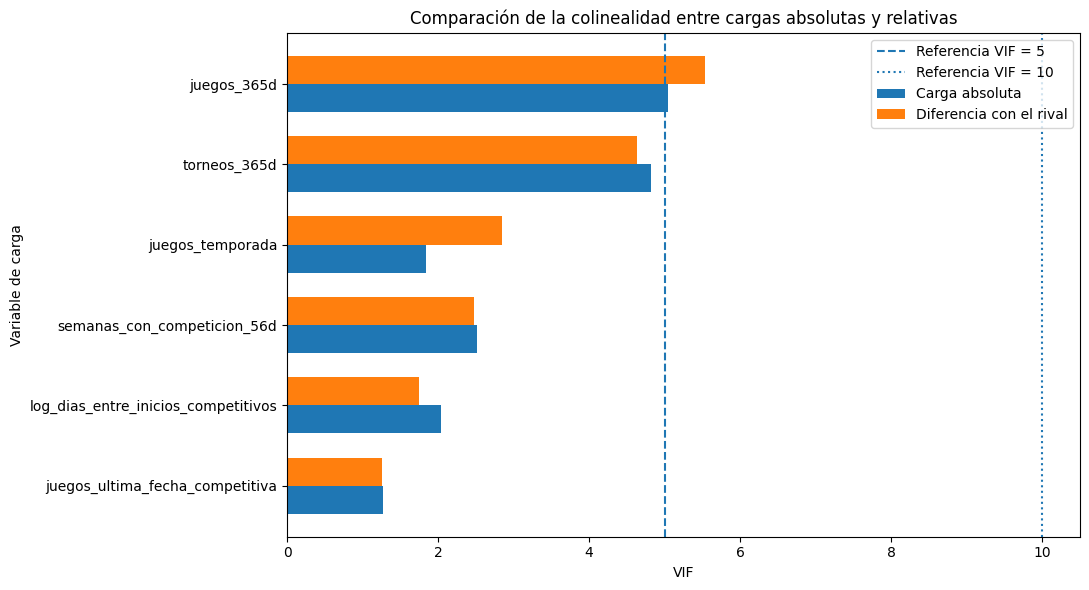

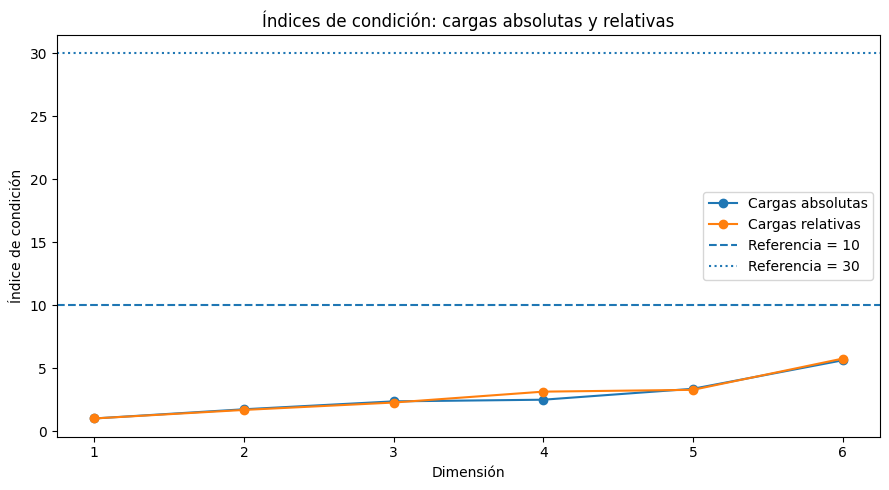

Diagnóstico de colinealidad de las cargas relativas completado.


In [28]:

# ============================================================
# 10.4. COLINEALIDAD DE LAS CARGAS RELATIVAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


# ------------------------------------------------------------
# 1. Definición de variables
# ------------------------------------------------------------

variables_absolutas_comparacion = [
    "juegos_365d",
    "torneos_365d",
    "juegos_temporada",
    "juegos_ultima_fecha_competitiva",
    "log_dias_entre_inicios_competitivos",
    "semanas_con_competicion_56d"
]


variables_relativas_comparacion = [
    "diff_juegos_365d",
    "diff_torneos_365d",
    "diff_juegos_temporada",
    "diff_juegos_ultima_fecha_competitiva",
    "diff_log_dias_entre_inicios_competitivos",
    "diff_semanas_con_competicion_56d"
]


muestra_colinealidad_relativa = (
    data_muestra_principal_emparejada.copy()
)


assert len(muestra_colinealidad_relativa) == len(data_muestra_principal_emparejada)

assert (
    muestra_colinealidad_relativa[
        variables_absolutas_comparacion
        + variables_relativas_comparacion
    ]
    .notna()
    .all()
    .all()
)


# ------------------------------------------------------------
# 2. Función de diagnóstico
# ------------------------------------------------------------

def diagnostico_colinealidad(
    df,
    variables
):
    """
    Calcula:

    - VIF;
    - tolerancia;
    - R² auxiliar;
    - índices de condición;
    - proporciones de descomposición de la varianza.
    """

    X = (
        df[variables]
        .astype(float)
        .copy()
    )


    assert X.notna().all().all()
    assert X.nunique().gt(1).all()


    # Estandarización
    escalador = StandardScaler()

    X_estandarizada = pd.DataFrame(
        escalador.fit_transform(X),
        columns=variables,
        index=X.index
    )


    # --------------------------------------------------------
    # VIF
    # --------------------------------------------------------

    X_vif = sm.add_constant(
        X_estandarizada,
        has_constant="add"
    )


    resultados_vif = []


    for posicion, variable in enumerate(
        variables,
        start=1
    ):

        vif = variance_inflation_factor(
            X_vif.to_numpy(),
            posicion
        )


        resultados_vif.append(
            {
                "variable": variable,
                "VIF": vif,
                "tolerancia": 1 / vif,
                "R2_auxiliar": 1 - (1 / vif)
            }
        )


    tabla_vif_resultado = (
        pd.DataFrame(resultados_vif)
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Índices de condición
    # --------------------------------------------------------

    matriz_estandarizada = (
        X_estandarizada.to_numpy()
    )


    normas_columnas = np.linalg.norm(
        matriz_estandarizada,
        axis=0
    )


    assert np.all(
        normas_columnas > 0
    )


    matriz_norma_unidad = (
        matriz_estandarizada
        / normas_columnas
    )


    U, valores_singulares, Vt = np.linalg.svd(
        matriz_norma_unidad,
        full_matrices=False
    )


    autovalores = valores_singulares ** 2


    indices_condicion = (
        valores_singulares.max()
        / valores_singulares
    )


    tabla_indices_resultado = pd.DataFrame(
        {
            "dimension": np.arange(
                1,
                len(valores_singulares) + 1
            ),
            "autovalor": autovalores,
            "valor_singular": valores_singulares,
            "indice_condicion": indices_condicion
        }
    )


    # --------------------------------------------------------
    # Proporciones de descomposición de la varianza
    # --------------------------------------------------------

    V = Vt.T


    componentes_varianza = (
        V ** 2
        / autovalores[np.newaxis, :]
    )


    proporciones_varianza = (
        componentes_varianza
        / componentes_varianza.sum(
            axis=1,
            keepdims=True
        )
    )


    tabla_proporciones_resultado = pd.DataFrame(
        proporciones_varianza.T,
        columns=variables
    )


    tabla_proporciones_resultado.insert(
        0,
        "indice_condicion",
        indices_condicion
    )


    tabla_proporciones_resultado.insert(
        0,
        "dimension",
        np.arange(
            1,
            len(indices_condicion) + 1
        )
    )


    return (
        tabla_vif_resultado,
        tabla_indices_resultado,
        tabla_proporciones_resultado
    )


# ------------------------------------------------------------
# 3. Diagnóstico de las cargas absolutas
# ------------------------------------------------------------

(
    tabla_vif_absolutas_emparejadas,
    tabla_indices_absolutas_emparejadas,
    tabla_proporciones_absolutas_emparejadas
) = diagnostico_colinealidad(
    muestra_colinealidad_relativa,
    variables_absolutas_comparacion
)


# ------------------------------------------------------------
# 4. Diagnóstico de las cargas relativas
# ------------------------------------------------------------

(
    tabla_vif_relativas,
    tabla_indices_relativas,
    tabla_proporciones_relativas
) = diagnostico_colinealidad(
    muestra_colinealidad_relativa,
    variables_relativas_comparacion
)


print(
    "VIF DE LAS CARGAS RELATIVAS"
)

display(
    tabla_vif_relativas.style.format(
        {
            "VIF": "{:.3f}",
            "tolerancia": "{:.3f}",
            "R2_auxiliar": "{:.3f}"
        }
    )
)


print(
    "ÍNDICES DE CONDICIÓN DE LAS CARGAS RELATIVAS"
)

display(
    tabla_indices_relativas.style.format(
        {
            "autovalor": "{:.6f}",
            "valor_singular": "{:.6f}",
            "indice_condicion": "{:.3f}"
        }
    )
)


print(
    "PROPORCIONES DE DESCOMPOSICIÓN "
    "DE LA VARIANZA DE LAS CARGAS RELATIVAS"
)

display(
    tabla_proporciones_relativas.style.format(
        {
            columna: "{:.3f}"
            for columna
            in tabla_proporciones_relativas.columns
            if columna != "dimension"
        }
    )
)


# ------------------------------------------------------------
# 5. Comparación directa de los VIF
# ------------------------------------------------------------

mapeo_variables = pd.DataFrame(
    {
        "variable_absoluta":
            variables_absolutas_comparacion,

        "variable_relativa":
            variables_relativas_comparacion
    }
)


vif_absolutas_comparacion = (
    tabla_vif_absolutas_emparejadas[
        [
            "variable",
            "VIF",
            "tolerancia"
        ]
    ]
    .rename(
        columns={
            "variable": "variable_absoluta",
            "VIF": "VIF_absoluta",
            "tolerancia": "tolerancia_absoluta"
        }
    )
)


vif_relativas_comparacion = (
    tabla_vif_relativas[
        [
            "variable",
            "VIF",
            "tolerancia"
        ]
    ]
    .rename(
        columns={
            "variable": "variable_relativa",
            "VIF": "VIF_relativa",
            "tolerancia": "tolerancia_relativa"
        }
    )
)


tabla_comparacion_vif = (
    mapeo_variables
    .merge(
        vif_absolutas_comparacion,
        on="variable_absoluta",
        how="left"
    )
    .merge(
        vif_relativas_comparacion,
        on="variable_relativa",
        how="left"
    )
)


tabla_comparacion_vif[
    "diferencia_VIF"
] = (
    tabla_comparacion_vif["VIF_relativa"]
    - tabla_comparacion_vif["VIF_absoluta"]
)


tabla_comparacion_vif = (
    tabla_comparacion_vif
    .sort_values(
        "VIF_relativa",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "COMPARACIÓN DE VIF: "
    "CARGAS ABSOLUTAS Y RELATIVAS"
)

display(
    tabla_comparacion_vif.style.format(
        {
            "VIF_absoluta": "{:.3f}",
            "VIF_relativa": "{:.3f}",
            "diferencia_VIF": "{:+.3f}",
            "tolerancia_absoluta": "{:.3f}",
            "tolerancia_relativa": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 6. Comparación de los índices de condición máximos
# ------------------------------------------------------------

resumen_indices_condicion = pd.DataFrame(
    {
        "especificacion": [
            "Cargas absolutas",
            "Cargas relativas"
        ],
        "indice_condicion_maximo": [
            tabla_indices_absolutas_emparejadas[
                "indice_condicion"
            ].max(),

            tabla_indices_relativas[
                "indice_condicion"
            ].max()
        ],
        "autovalor_minimo": [
            tabla_indices_absolutas_emparejadas[
                "autovalor"
            ].min(),

            tabla_indices_relativas[
                "autovalor"
            ].min()
        ]
    }
)


display(
    resumen_indices_condicion.style.format(
        {
            "indice_condicion_maximo": "{:.3f}",
            "autovalor_minimo": "{:.6f}"
        }
    )
)


# ------------------------------------------------------------
# 7. Gráfico comparativo de los VIF
# ------------------------------------------------------------

tabla_grafico_vif = (
    tabla_comparacion_vif
    .sort_values(
        "VIF_relativa",
        ascending=True
    )
)


posiciones = np.arange(
    len(tabla_grafico_vif)
)

altura = 0.35


figura, eje = plt.subplots(
    figsize=(11, 6)
)


eje.barh(
    posiciones - altura / 2,
    tabla_grafico_vif["VIF_absoluta"],
    height=altura,
    label="Carga absoluta"
)


eje.barh(
    posiciones + altura / 2,
    tabla_grafico_vif["VIF_relativa"],
    height=altura,
    label="Diferencia con el rival"
)


eje.set_yticks(posiciones)

eje.set_yticklabels(
    tabla_grafico_vif["variable_absoluta"]
)


eje.axvline(
    5,
    linestyle="--",
    linewidth=1.5,
    label="Referencia VIF = 5"
)


eje.axvline(
    10,
    linestyle=":",
    linewidth=1.5,
    label="Referencia VIF = 10"
)


eje.set_xlabel("VIF")

eje.set_ylabel(
    "Variable de carga"
)

eje.set_title(
    "Comparación de la colinealidad "
    "entre cargas absolutas y relativas"
)

eje.legend()

figura.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Gráfico comparativo de los índices de condición
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(9, 5)
)


eje.plot(
    tabla_indices_absolutas_emparejadas[
        "dimension"
    ],
    tabla_indices_absolutas_emparejadas[
        "indice_condicion"
    ],
    marker="o",
    label="Cargas absolutas"
)


eje.plot(
    tabla_indices_relativas[
        "dimension"
    ],
    tabla_indices_relativas[
        "indice_condicion"
    ],
    marker="o",
    label="Cargas relativas"
)


eje.axhline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="Referencia = 10"
)


eje.axhline(
    30,
    linestyle=":",
    linewidth=1.5,
    label="Referencia = 30"
)


eje.set_xlabel("Dimensión")
eje.set_ylabel("Índice de condición")

eje.set_title(
    "Índices de condición: "
    "cargas absolutas y relativas"
)

eje.legend()

figura.tight_layout()
plt.show()


print(
    "Diagnóstico de colinealidad "
    "de las cargas relativas completado."
)



### 10.5. Interpretación del diagnóstico de colinealidad relativo

La transformación de las variables de carga en diferencias jugador–rival no produce
un cambio sustancial en la colinealidad global. El índice de condición máximo pasa
de 5,614 en las cargas absolutas a 5,750 en las cargas relativas.

La principal dependencia se concentra entre `diff_juegos_365d` y
`diff_torneos_365d`, con factores de inflación de la varianza de 5,531 y 4,636,
respectivamente. La diferencia de juegos acumulados durante la temporada presenta
un VIF de 2,852, mientras que las restantes variables relativas muestran valores
inferiores.

Estos resultados indican que el volumen anual de juegos y la frecuencia anual de
participación contienen una dependencia apreciable, aunque no se aplicó un umbral
automático de eliminación. Por este motivo, `diff_torneos_365d` se reservó para la
especificación ampliada, manteniendo las restantes variables en el núcleo principal.


### Resumen del diagnóstico de colinealidad para el anexo

Para documentar de forma compacta el diagnóstico multivariante de las variables de
carga relativas, se resumen los factores de inflación de la varianza y sus correspondientes
tolerancias.

El cuadro utiliza exclusivamente los resultados ya obtenidos sobre la muestra
emparejada empleada en el análisis de colinealidad. No se incluye el $R^2$ auxiliar,
ya que contiene información algebraicamente equivalente a la tolerancia y al VIF.

El índice de condición máximo se conservará como resultado complementario en la
nota del cuadro.


In [29]:
# ============================================================
# RESUMEN PARA EL ANEXO:
# VIF Y TOLERANCIA DE LAS CARGAS RELATIVAS
# ============================================================

tabla_vif_anexo = (
    tabla_vif_relativas[
        [
            "variable",
            "VIF",
            "tolerancia"
        ]
    ]
    .copy()
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobaciones
# ------------------------------------------------------------

assert len(tabla_vif_anexo) == 6

assert tabla_vif_anexo[
    ["VIF", "tolerancia"]
].notna().all().all()

assert np.allclose(
    tabla_vif_anexo["tolerancia"],
    1 / tabla_vif_anexo["VIF"]
)


# ------------------------------------------------------------
# Índice de condición máximo
# ------------------------------------------------------------

indice_condicion_max_relativo = (
    tabla_indices_relativas[
        "indice_condicion"
    ].max()
)

indice_condicion_max_absoluto = (
    tabla_indices_absolutas_emparejadas[
        "indice_condicion"
    ].max()
)


# ------------------------------------------------------------
# Presentación
# ------------------------------------------------------------

display(
    tabla_vif_anexo.style.format(
        {
            "VIF": "{:.3f}",
            "tolerancia": "{:.3f}"
        }
    )
)

print(
    "Índice de condición máximo - cargas relativas:",
    f"{indice_condicion_max_relativo:.3f}"
)

print(
    "Índice de condición máximo - cargas absolutas:",
    f"{indice_condicion_max_absoluto:.3f}"
)

,variable,VIF,tolerancia
0,diff_juegos_365d,5.531,0.181
1,diff_torneos_365d,4.636,0.216
2,diff_juegos_temporada,2.852,0.351
3,diff_semanas_con_competicion_56d,2.480,0.403
4,diff_log_dias_entre_inicios_competitivos,1.742,0.574
5,diff_juegos_ultima_fecha_competitiva,1.261,0.793


Índice de condición máximo - cargas relativas: 5.750
Índice de condición máximo - cargas absolutas: 5.614


ASOCIACIÓN DE LAS CARGAS RELATIVAS POR PERIODO


,periodo,variable,observaciones,partidos,pearson,spearman,kendall_tau_b
0,2009-2019,diff_juegos_365d,"62,310","31,155",0.3587,0.3678,0.2496
1,2009-2019,diff_torneos_365d,"62,310","31,155",0.1898,0.1772,0.1209
2,2009-2019,diff_juegos_temporada,"62,310","31,155",0.2801,0.3049,0.2058
3,2009-2019,diff_juegos_ultima_fecha_competitiva,"62,310","31,155",0.2188,0.2223,0.1502
4,2009-2019,diff_log_dias_entre_inicios_competitivos,"62,310","31,155",-0.1516,-0.1266,-0.0902
5,2009-2019,diff_semanas_con_competicion_56d,"62,310","31,155",0.1188,0.1080,0.0780
6,2022-2023,diff_juegos_365d,"10,940","5,470",0.3080,0.3077,0.2087
7,2022-2023,diff_torneos_365d,"10,940","5,470",0.1878,0.1739,0.1189
8,2022-2023,diff_juegos_temporada,"10,940","5,470",0.2618,0.2781,0.1876
9,2022-2023,diff_juegos_ultima_fecha_competitiva,"10,940","5,470",0.1978,0.2035,0.1377


COMPARACIÓN TEMPORAL DE SPEARMAN


periodo,variable,2009-2019,2022-2023,diferencia_periodos,mismo_signo,magnitud_minima
0,diff_juegos_365d,0.3678,0.3077,-0.0601,True,0.3077
1,diff_juegos_temporada,0.3049,0.2781,-0.0269,True,0.2781
2,diff_juegos_ultima_fecha_competitiva,0.2223,0.2035,-0.0188,True,0.2035
3,diff_torneos_365d,0.1772,0.1739,-0.0034,True,0.1739
4,diff_log_dias_entre_inicios_competitivos,-0.1266,-0.1266,+0.0000,True,0.1266
5,diff_semanas_con_competicion_56d,0.1080,0.1368,+0.0288,True,0.1080


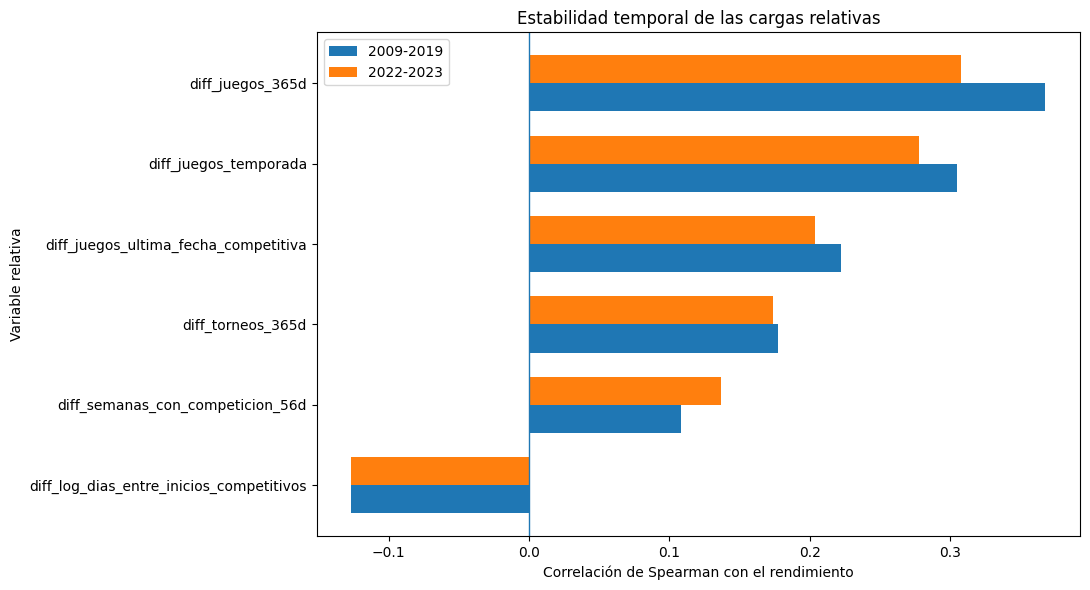

Análisis de estabilidad temporal completado.


In [30]:

# ============================================================
# 10.6. ESTABILIDAD TEMPORAL DE LAS CARGAS RELATIVAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, kendalltau


muestra_estabilidad_temporal = (
    data_muestra_principal_emparejada.copy()
)


# ------------------------------------------------------------
# 1. Año del partido
# ------------------------------------------------------------

if "match_year" in muestra_estabilidad_temporal.columns:

    muestra_estabilidad_temporal[
        "anio_analisis"
    ] = (
        muestra_estabilidad_temporal[
            "match_year"
        ]
        .astype(int)
    )

else:

    muestra_estabilidad_temporal[
        "fecha_torneo"
    ] = pd.to_datetime(
        muestra_estabilidad_temporal[
            "fecha_torneo"
        ],
        errors="raise"
    )

    muestra_estabilidad_temporal[
        "anio_analisis"
    ] = (
        muestra_estabilidad_temporal[
            "fecha_torneo"
        ]
        .dt.year
    )


# ------------------------------------------------------------
# 2. Definición de los periodos
# ------------------------------------------------------------

condiciones_periodo = [
    muestra_estabilidad_temporal[
        "anio_analisis"
    ].between(2009, 2019),

    muestra_estabilidad_temporal[
        "anio_analisis"
    ].between(2022, 2023)
]


etiquetas_periodo = [
    "2009-2019",
    "2022-2023"
]


muestra_estabilidad_temporal[
    "periodo_estudio"
] = np.select(
    condiciones_periodo,
    etiquetas_periodo,
    default="Fuera del periodo"
)


assert (
    muestra_estabilidad_temporal[
        "periodo_estudio"
    ]
    .ne("Fuera del periodo")
    .all()
)


# ------------------------------------------------------------
# 3. Correlaciones por periodo
# ------------------------------------------------------------

resultados_periodos = []


for periodo in etiquetas_periodo:

    datos_periodo = (
        muestra_estabilidad_temporal.loc[
            muestra_estabilidad_temporal[
                "periodo_estudio"
            ].eq(periodo)
        ]
        .copy()
    )


    for variable in variables_relativas_comparacion:

        x = datos_periodo[variable]
        y = datos_periodo[variable_objetivo]


        resultados_periodos.append(
            {
                "periodo": periodo,
                "variable": variable,
                "observaciones": len(datos_periodo),
                "partidos": datos_periodo[
                    "_id_partido"
                ].nunique(),
                "pearson": pearsonr(
                    x,
                    y
                ).statistic,
                "spearman": spearmanr(
                    x,
                    y
                ).statistic,
                "kendall_tau_b": kendalltau(
                    x,
                    y,
                    variant="b"
                ).statistic
            }
        )


tabla_estabilidad_periodos_larga = (
    pd.DataFrame(resultados_periodos)
)


print(
    "ASOCIACIÓN DE LAS CARGAS RELATIVAS "
    "POR PERIODO"
)

display(
    tabla_estabilidad_periodos_larga.style.format(
        {
            "observaciones": "{:,.0f}",
            "partidos": "{:,.0f}",
            "pearson": "{:.4f}",
            "spearman": "{:.4f}",
            "kendall_tau_b": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 4. Comparación directa de Spearman
# ------------------------------------------------------------

tabla_estabilidad_periodos = (
    tabla_estabilidad_periodos_larga
    .pivot(
        index="variable",
        columns="periodo",
        values="spearman"
    )
    .reset_index()
)


tabla_estabilidad_periodos[
    "diferencia_periodos"
] = (
    tabla_estabilidad_periodos[
        "2022-2023"
    ]
    - tabla_estabilidad_periodos[
        "2009-2019"
    ]
)


tabla_estabilidad_periodos[
    "mismo_signo"
] = (
    np.sign(
        tabla_estabilidad_periodos[
            "2009-2019"
        ]
    )
    ==
    np.sign(
        tabla_estabilidad_periodos[
            "2022-2023"
        ]
    )
)


tabla_estabilidad_periodos[
    "magnitud_minima"
] = (
    tabla_estabilidad_periodos[
        [
            "2009-2019",
            "2022-2023"
        ]
    ]
    .abs()
    .min(axis=1)
)


tabla_estabilidad_periodos = (
    tabla_estabilidad_periodos
    .sort_values(
        "magnitud_minima",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "COMPARACIÓN TEMPORAL DE SPEARMAN"
)

display(
    tabla_estabilidad_periodos.style.format(
        {
            "2009-2019": "{:.4f}",
            "2022-2023": "{:.4f}",
            "diferencia_periodos": "{:+.4f}",
            "magnitud_minima": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 5. Gráfico comparativo
# ------------------------------------------------------------

tabla_grafico_periodos = (
    tabla_estabilidad_periodos
    .sort_values(
        "2009-2019",
        ascending=True
    )
    .copy()
)


posiciones = np.arange(
    len(tabla_grafico_periodos)
)

altura = 0.35


figura, eje = plt.subplots(
    figsize=(11, 6)
)


eje.barh(
    posiciones - altura / 2,
    tabla_grafico_periodos[
        "2009-2019"
    ],
    height=altura,
    label="2009-2019"
)


eje.barh(
    posiciones + altura / 2,
    tabla_grafico_periodos[
        "2022-2023"
    ],
    height=altura,
    label="2022-2023"
)


eje.set_yticks(posiciones)

eje.set_yticklabels(
    tabla_grafico_periodos[
        "variable"
    ]
)


eje.axvline(
    0,
    linewidth=1
)


eje.set_xlabel(
    "Correlación de Spearman con el rendimiento"
)

eje.set_ylabel(
    "Variable relativa"
)

eje.set_title(
    "Estabilidad temporal de las cargas relativas"
)

eje.legend()


figura.tight_layout()
plt.show()


print(
    "Análisis de estabilidad temporal completado."
)



### 10.7. Interpretación de la estabilidad temporal

Las asociaciones entre las cargas relativas y el porcentaje de juegos ganados se evaluaron comparando los dos subperiodos de desarrollo considerados:

$$
2009\text{--}2019
$$

y:

$$
2022\text{--}2023.
$$

Esta comparación permite comprobar si la dirección y la magnitud aproximada de las relaciones observadas se mantienen entre ambos periodos de desarrollo.

La temporada 2024 permaneció completamente excluida de este análisis y se reservó íntegramente para la evaluación temporal externa.

Columna utilizada: nivel_torneo
Niveles observados:


,nivel_torneo,observaciones
0,ATP,39546
1,Masters_1000,14686
2,Grand_Slam,12948
3,Davis_Cup,5592
4,ATP_Finals,478


TAMAÑO DE LA MUESTRA POR NIVEL DE TORNEO


,nivel_torneo,observaciones,partidos,jugadores
0,ATP,39546,19773,779
4,Masters_1000,14686,7343,457
3,Grand_Slam,12948,6474,563
2,Davis_Cup,5592,2796,844
1,ATP_Finals,478,239,59


Niveles incluidos: ['ATP', 'Masters_1000', 'Grand_Slam', 'Davis_Cup', 'ATP_Finals']
ASOCIACIÓN DE LAS CARGAS RELATIVAS SEGÚN EL NIVEL DEL TORNEO


,nivel_torneo,variable,observaciones,partidos,spearman
0,ATP,diff_juegos_365d,"39,546","19,773",0.3155
1,ATP,diff_torneos_365d,"39,546","19,773",0.1917
2,ATP,diff_juegos_temporada,"39,546","19,773",0.2646
3,ATP,diff_juegos_ultima_fecha_competitiva,"39,546","19,773",0.1722
4,ATP,diff_log_dias_entre_inicios_competitivos,"39,546","19,773",-0.1231
5,ATP,diff_semanas_con_competicion_56d,"39,546","19,773",0.1303
6,Masters_1000,diff_juegos_365d,"14,686","7,343",0.3251
7,Masters_1000,diff_torneos_365d,"14,686","7,343",0.0142
8,Masters_1000,diff_juegos_temporada,"14,686","7,343",0.2681
9,Masters_1000,diff_juegos_ultima_fecha_competitiva,"14,686","7,343",0.2444


nivel_torneo,ATP,ATP_Finals,Davis_Cup,Grand_Slam,Masters_1000
variable,,,,,
diff_juegos_365d,0.3155,0.1207,0.4566,0.5016,0.3251
diff_juegos_temporada,0.2646,0.1045,0.4260,0.4143,0.2681
diff_juegos_ultima_fecha_competitiva,0.1722,0.1486,0.2714,0.3148,0.2444
diff_log_dias_entre_inicios_competitivos,-0.1231,-0.1860,-0.3877,-0.1089,-0.0324
diff_semanas_con_competicion_56d,0.1303,-0.0364,0.3465,0.1490,-0.0508
diff_torneos_365d,0.1917,-0.1185,0.3765,0.2272,0.0142


VARIACIÓN DE LAS ASOCIACIONES ENTRE NIVELES


,variable,spearman_minimo,spearman_maximo,spearman_medio,amplitud,mismo_signo_todos_niveles
0,diff_torneos_365d,-0.1185,0.3765,0.1382,0.4950,False
1,diff_semanas_con_competicion_56d,-0.0508,0.3465,0.1077,0.3974,False
2,diff_juegos_365d,0.1207,0.5016,0.3439,0.3809,True
3,diff_log_dias_entre_inicios_competitivos,-0.3877,-0.0324,-0.1676,0.3553,True
4,diff_juegos_temporada,0.1045,0.4260,0.2955,0.3214,True
5,diff_juegos_ultima_fecha_competitiva,0.1486,0.3148,0.2303,0.1662,True


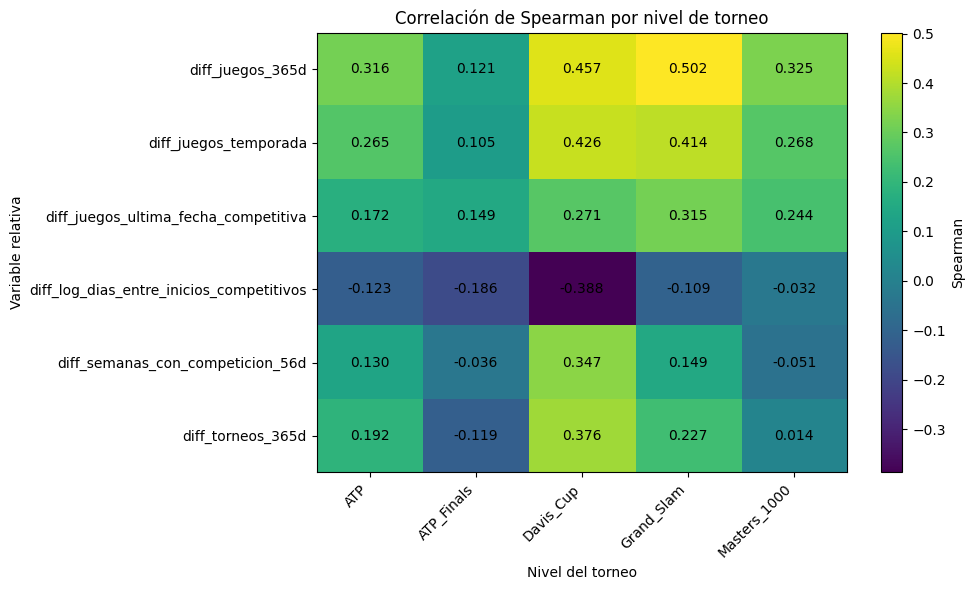

Análisis por nivel de torneo completado.


In [31]:

# ============================================================
# 10.8. ESTABILIDAD SEGÚN EL NIVEL DEL TORNEO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


muestra_niveles = (
    data_muestra_principal_emparejada.copy()
)


# ------------------------------------------------------------
# 1. Identificación de la columna del nivel del torneo
# ------------------------------------------------------------

candidatas_nivel = [
    "nivel_torneo",
    "tourney_level",
    "categoria_torneo",
    "nivel"
]


columna_nivel = next(
    (
        columna
        for columna in candidatas_nivel
        if columna in muestra_niveles.columns
    ),
    None
)


assert columna_nivel is not None, (
    "No se ha encontrado la columna que identifica "
    "el nivel del torneo."
)


print(
    "Columna utilizada:",
    columna_nivel
)

print(
    "Niveles observados:"
)

display(
    muestra_niveles[
        columna_nivel
    ]
    .value_counts(dropna=False)
    .rename_axis("nivel_torneo")
    .reset_index(name="observaciones")
)


# ------------------------------------------------------------
# 2. Comprobación de coherencia dentro de cada partido
# ------------------------------------------------------------

niveles_por_partido = (
    muestra_niveles
    .groupby("_id_partido")[
        columna_nivel
    ]
    .nunique(dropna=False)
)


assert niveles_por_partido.eq(1).all()


# ------------------------------------------------------------
# 3. Número de partidos por nivel
# ------------------------------------------------------------

resumen_niveles = (
    muestra_niveles
    .groupby(
        columna_nivel,
        dropna=False
    )
    .agg(
        observaciones=(
            "_id_partido",
            "size"
        ),
        partidos=(
            "_id_partido",
            "nunique"
        ),
        jugadores=(
            "jugador_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "partidos",
        ascending=False
    )
)


print(
    "TAMAÑO DE LA MUESTRA POR NIVEL DE TORNEO"
)

display(resumen_niveles)


# ------------------------------------------------------------
# 4. Selección de niveles con tamaño suficiente
# ------------------------------------------------------------

minimo_partidos = 200


niveles_validos = (
    resumen_niveles.loc[
        resumen_niveles[
            "partidos"
        ] >= minimo_partidos,
        columna_nivel
    ]
    .tolist()
)


print(
    "Niveles incluidos:",
    niveles_validos
)


# ------------------------------------------------------------
# 5. Correlaciones de Spearman por nivel
# ------------------------------------------------------------

resultados_nivel = []


for nivel in niveles_validos:

    datos_nivel = (
        muestra_niveles.loc[
            muestra_niveles[
                columna_nivel
            ].eq(nivel)
        ]
        .copy()
    )


    for variable in variables_relativas_comparacion:

        coeficiente = spearmanr(
            datos_nivel[variable],
            datos_nivel[
                variable_objetivo
            ]
        ).statistic


        resultados_nivel.append(
            {
                "nivel_torneo": nivel,
                "variable": variable,
                "observaciones": len(
                    datos_nivel
                ),
                "partidos": datos_nivel[
                    "_id_partido"
                ].nunique(),
                "spearman": coeficiente
            }
        )


tabla_estabilidad_nivel_larga = pd.DataFrame(
    resultados_nivel
)


print(
    "ASOCIACIÓN DE LAS CARGAS RELATIVAS "
    "SEGÚN EL NIVEL DEL TORNEO"
)

display(
    tabla_estabilidad_nivel_larga.style.format(
        {
            "observaciones": "{:,.0f}",
            "partidos": "{:,.0f}",
            "spearman": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 6. Tabla matricial
# ------------------------------------------------------------

tabla_estabilidad_nivel = (
    tabla_estabilidad_nivel_larga
    .pivot(
        index="variable",
        columns="nivel_torneo",
        values="spearman"
    )
)


display(
    tabla_estabilidad_nivel.style.format(
        "{:.4f}"
    )
)


# ------------------------------------------------------------
# 7. Amplitud entre niveles
# ------------------------------------------------------------

resumen_variacion_niveles = (
    tabla_estabilidad_nivel_larga
    .groupby(
        "variable",
        as_index=False
    )
    .agg(
        spearman_minimo=(
            "spearman",
            "min"
        ),
        spearman_maximo=(
            "spearman",
            "max"
        ),
        spearman_medio=(
            "spearman",
            "mean"
        )
    )
)


resumen_variacion_niveles[
    "amplitud"
] = (
    resumen_variacion_niveles[
        "spearman_maximo"
    ]
    - resumen_variacion_niveles[
        "spearman_minimo"
    ]
)


resumen_variacion_niveles[
    "mismo_signo_todos_niveles"
] = (
    tabla_estabilidad_nivel_larga
    .groupby("variable")[
        "spearman"
    ]
    .apply(
        lambda serie: (
            np.all(serie > 0)
            or np.all(serie < 0)
        )
    )
    .to_numpy()
)


resumen_variacion_niveles = (
    resumen_variacion_niveles
    .sort_values(
        "amplitud",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "VARIACIÓN DE LAS ASOCIACIONES ENTRE NIVELES"
)

display(
    resumen_variacion_niveles.style.format(
        {
            "spearman_minimo": "{:.4f}",
            "spearman_maximo": "{:.4f}",
            "spearman_medio": "{:.4f}",
            "amplitud": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 8. Mapa de calor
# ------------------------------------------------------------

matriz_grafico = (
    tabla_estabilidad_nivel
    .copy()
)


figura, eje = plt.subplots(
    figsize=(10, 6)
)


imagen = eje.imshow(
    matriz_grafico.to_numpy(),
    aspect="auto"
)


eje.set_xticks(
    np.arange(
        len(matriz_grafico.columns)
    )
)

eje.set_xticklabels(
    matriz_grafico.columns,
    rotation=45,
    ha="right"
)


eje.set_yticks(
    np.arange(
        len(matriz_grafico.index)
    )
)

eje.set_yticklabels(
    matriz_grafico.index
)


for fila in range(
    matriz_grafico.shape[0]
):

    for columna in range(
        matriz_grafico.shape[1]
    ):

        valor = matriz_grafico.iloc[
            fila,
            columna
        ]

        eje.text(
            columna,
            fila,
            f"{valor:.3f}",
            ha="center",
            va="center"
        )


eje.set_title(
    "Correlación de Spearman por nivel de torneo"
)

eje.set_xlabel(
    "Nivel del torneo"
)

eje.set_ylabel(
    "Variable relativa"
)


figura.colorbar(
    imagen,
    ax=eje,
    label="Spearman"
)


figura.tight_layout()
plt.show()


print(
    "Análisis por nivel de torneo completado."
)



### 10.9. Interpretación de la estabilidad según el nivel del torneo

Las principales variables relativas conservan la dirección de su relación con el rendimiento en todos los niveles competitivos analizados. Las diferencias en juegos acumulados durante los últimos 365 días, juegos de temporada y juegos disputados en la última participación presentan asociaciones positivas en todas las categorías. Por su parte, la diferencia en el intervalo entre participaciones mantiene una asociación negativa.

La relación más elevada de `diff_juegos_365d` se observa en los Grand Slam, con un coeficiente de Spearman de 0,5016, seguida por la Copa Davis, con 0,4566. La diferencia en juegos acumulados durante la temporada presenta un comportamiento semejante.

Las variables `diff_torneos_365d` y `diff_semanas_con_competicion_56d` muestran una mayor heterogeneidad entre niveles, incluyendo cambios de signo en ATP Finals y Masters 1000. Estas variaciones indican que su relación con el rendimiento puede depender del contexto competitivo.

Los resultados de ATP Finals deben interpretarse con cautela debido al reducido número de partidos y a la fuerte selección de los jugadores participantes. En consecuencia, no se eliminarán variables únicamente por los cambios observados en esta categoría.

En conjunto, las variables principales de volumen, carga inmediata y descanso relativo presentan una estabilidad suficiente para continuar hacia la modelización, incorporando el nivel del torneo como variable contextual.


Columna utilizada: superficie


,superficie,observaciones,partidos,jugadores
3,Hard,42108,21054,1008
1,Clay,22808,11404,861
2,Grass,8140,4070,522
0,Carpet,152,76,81
4,UNKNOWN,42,21,35


Superficies incluidas: ['Hard', 'Clay', 'Grass']


,superficie,variable,observaciones,partidos,spearman
0,Hard,diff_juegos_365d,"42,108","21,054",0.3647
1,Hard,diff_torneos_365d,"42,108","21,054",0.1640
2,Hard,diff_juegos_temporada,"42,108","21,054",0.2905
3,Hard,diff_juegos_ultima_fecha_competitiva,"42,108","21,054",0.2257
4,Hard,diff_log_dias_entre_inicios_competitivos,"42,108","21,054",-0.1149
5,Hard,diff_semanas_con_competicion_56d,"42,108","21,054",0.0731
6,Clay,diff_juegos_365d,"22,808","11,404",0.3497
7,Clay,diff_torneos_365d,"22,808","11,404",0.1976
8,Clay,diff_juegos_temporada,"22,808","11,404",0.3182
9,Clay,diff_juegos_ultima_fecha_competitiva,"22,808","11,404",0.2030


superficie,Clay,Grass,Hard
variable,,,
diff_juegos_365d,0.3497,0.3583,0.3647
diff_juegos_temporada,0.3182,0.3297,0.2905
diff_juegos_ultima_fecha_competitiva,0.2030,0.2433,0.2257
diff_log_dias_entre_inicios_competitivos,-0.1471,-0.1186,-0.1149
diff_semanas_con_competicion_56d,0.1630,0.1565,0.0731
diff_torneos_365d,0.1976,0.1777,0.1640


,variable,spearman_minimo,spearman_maximo,spearman_medio,amplitud,mismo_signo_todas_superficies
0,diff_semanas_con_competicion_56d,0.0731,0.1630,0.1308,0.0899,True
1,diff_juegos_ultima_fecha_competitiva,0.2030,0.2433,0.2240,0.0403,True
2,diff_juegos_temporada,0.2905,0.3297,0.3128,0.0392,True
3,diff_torneos_365d,0.1640,0.1976,0.1797,0.0336,True
4,diff_log_dias_entre_inicios_competitivos,-0.1471,-0.1149,-0.1269,0.0322,True
5,diff_juegos_365d,0.3497,0.3647,0.3575,0.0150,True


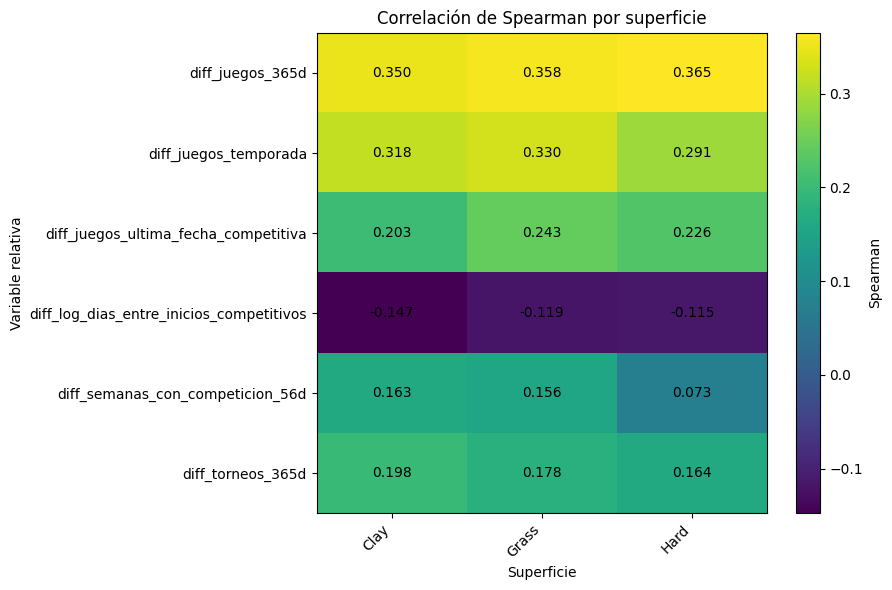

Análisis por superficie completado.


In [32]:

# ============================================================
# 10.10. ESTABILIDAD SEGÚN LA SUPERFICIE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


muestra_superficies = (
    data_muestra_principal_emparejada.copy()
)


# ------------------------------------------------------------
# 1. Identificación de la columna de superficie
# ------------------------------------------------------------

candidatas_superficie = [
    "superficie",
    "surface",
    "tipo_superficie"
]


columna_superficie = next(
    (
        columna
        for columna in candidatas_superficie
        if columna in muestra_superficies.columns
    ),
    None
)


assert columna_superficie is not None, (
    "No se ha encontrado la columna de superficie."
)


print(
    "Columna utilizada:",
    columna_superficie
)


# ------------------------------------------------------------
# 2. Tamaño de las muestras
# ------------------------------------------------------------

resumen_superficies = (
    muestra_superficies
    .groupby(
        columna_superficie,
        dropna=False
    )
    .agg(
        observaciones=(
            "_id_partido",
            "size"
        ),
        partidos=(
            "_id_partido",
            "nunique"
        ),
        jugadores=(
            "jugador_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "partidos",
        ascending=False
    )
)


display(resumen_superficies)


# ------------------------------------------------------------
# 3. Selección de superficies con muestra suficiente
# ------------------------------------------------------------

minimo_partidos_superficie = 200


superficies_validas = (
    resumen_superficies.loc[
        resumen_superficies["partidos"]
        >= minimo_partidos_superficie,
        columna_superficie
    ]
    .tolist()
)


print(
    "Superficies incluidas:",
    superficies_validas
)


# ------------------------------------------------------------
# 4. Correlaciones por superficie
# ------------------------------------------------------------

resultados_superficie = []


for superficie in superficies_validas:

    datos_superficie = (
        muestra_superficies.loc[
            muestra_superficies[
                columna_superficie
            ].eq(superficie)
        ]
        .copy()
    )


    for variable in variables_relativas_comparacion:

        coeficiente = spearmanr(
            datos_superficie[variable],
            datos_superficie[
                variable_objetivo
            ]
        ).statistic


        resultados_superficie.append(
            {
                "superficie": superficie,
                "variable": variable,
                "observaciones": len(
                    datos_superficie
                ),
                "partidos": datos_superficie[
                    "_id_partido"
                ].nunique(),
                "spearman": coeficiente
            }
        )


tabla_estabilidad_superficie_larga = pd.DataFrame(
    resultados_superficie
)


display(
    tabla_estabilidad_superficie_larga.style.format(
        {
            "observaciones": "{:,.0f}",
            "partidos": "{:,.0f}",
            "spearman": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 5. Tabla comparativa
# ------------------------------------------------------------

tabla_estabilidad_superficie = (
    tabla_estabilidad_superficie_larga
    .pivot(
        index="variable",
        columns="superficie",
        values="spearman"
    )
)


display(
    tabla_estabilidad_superficie.style.format(
        "{:.4f}"
    )
)


# ------------------------------------------------------------
# 6. Resumen de variación
# ------------------------------------------------------------

resumen_variacion_superficies = (
    tabla_estabilidad_superficie_larga
    .groupby(
        "variable",
        as_index=False
    )
    .agg(
        spearman_minimo=(
            "spearman",
            "min"
        ),
        spearman_maximo=(
            "spearman",
            "max"
        ),
        spearman_medio=(
            "spearman",
            "mean"
        )
    )
)


resumen_variacion_superficies[
    "amplitud"
] = (
    resumen_variacion_superficies[
        "spearman_maximo"
    ]
    - resumen_variacion_superficies[
        "spearman_minimo"
    ]
)


signos_superficie = (
    tabla_estabilidad_superficie_larga
    .groupby("variable")["spearman"]
    .apply(
        lambda serie: (
            np.all(serie > 0)
            or np.all(serie < 0)
        )
    )
    .rename(
        "mismo_signo_todas_superficies"
    )
    .reset_index()
)


resumen_variacion_superficies = (
    resumen_variacion_superficies
    .merge(
        signos_superficie,
        on="variable",
        how="left"
    )
    .sort_values(
        "amplitud",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    resumen_variacion_superficies.style.format(
        {
            "spearman_minimo": "{:.4f}",
            "spearman_maximo": "{:.4f}",
            "spearman_medio": "{:.4f}",
            "amplitud": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 7. Mapa de calor
# ------------------------------------------------------------

figura, eje = plt.subplots(
    figsize=(9, 6)
)


imagen = eje.imshow(
    tabla_estabilidad_superficie.to_numpy(),
    aspect="auto"
)


eje.set_xticks(
    np.arange(
        len(
            tabla_estabilidad_superficie.columns
        )
    )
)

eje.set_xticklabels(
    tabla_estabilidad_superficie.columns,
    rotation=45,
    ha="right"
)


eje.set_yticks(
    np.arange(
        len(
            tabla_estabilidad_superficie.index
        )
    )
)

eje.set_yticklabels(
    tabla_estabilidad_superficie.index
)


for fila in range(
    tabla_estabilidad_superficie.shape[0]
):

    for columna in range(
        tabla_estabilidad_superficie.shape[1]
    ):

        valor = (
            tabla_estabilidad_superficie
            .iloc[fila, columna]
        )

        eje.text(
            columna,
            fila,
            f"{valor:.3f}",
            ha="center",
            va="center"
        )


eje.set_title(
    "Correlación de Spearman por superficie"
)

eje.set_xlabel("Superficie")
eje.set_ylabel("Variable relativa")


figura.colorbar(
    imagen,
    ax=eje,
    label="Spearman"
)


figura.tight_layout()
plt.show()


print(
    "Análisis por superficie completado."
)



### 10.11. Interpretación de la estabilidad según la superficie

Las asociaciones de las variables relativas mantienen una dirección consistente en las tres superficies con tamaño muestral suficiente: pista dura, tierra batida y hierba.

En particular, `diff_juegos_365d` conserva una asociación positiva y de magnitud semejante entre superficies, mientras que `diff_log_dias_entre_inicios_competitivos` mantiene una asociación negativa. Las restantes variables también conservan el signo de su relación con el rendimiento.

Estos resultados indican que los principales patrones observados no se concentran exclusivamente en una única superficie y respaldan la estabilidad descriptiva de las variables seleccionadas antes de la modelización.

## 11. Control del momento de la temporada

La carga acumulada durante la temporada depende parcialmente del momento del calendario en el que se disputa el partido. Un jugador dispone de más tiempo para acumular actividad conforme avanza la temporada, aunque su intensidad competitiva sea semejante.

Para controlar este componente se construye el número de días transcurridos desde la primera fecha observable de cada temporada competitiva. Sea \(T_s^{\min}\) la primera fecha observable de la temporada \(s\):

$$
T_s^{\min}
=
\min \left\{
T_m:
\operatorname{match\_year}_m=s
\right\}.
$$

Para cada observación \(m\), la variable se define como:

$$
D_m^{\mathrm{temp}}
=
T_m-T_{s(m)}^{\min},
$$

donde \(T_m\) representa la fecha del torneo y \(s(m)\) la temporada competitiva asociada a la observación.

La variable es idéntica para los dos jugadores de un mismo partido, ya que ambos compiten en la misma fecha. Su función será controlar el avance del calendario observable y la mayor oportunidad de acumular carga conforme transcurre la temporada, no representar por sí misma una medida de carga competitiva.


In [33]:

# ============================================================
# 11. CONTROL DEL MOMENTO DE LA TEMPORADA
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Conversión rigurosa de la fecha
# ------------------------------------------------------------

data["fecha_torneo"] = pd.to_datetime(
    data["fecha_torneo"],
    errors="raise"
)



# ------------------------------------------------------------
# 2. Días desde el comienzo observable de cada temporada
# ------------------------------------------------------------

# Se utiliza match_year porque es la misma variable empleada
# para reiniciar las cargas acumuladas de temporada.

data["fecha_inicio_temporada_observada"] = (
    data
    .groupby("match_year")["fecha_torneo"]
    .transform("min")
)

data["dias_desde_inicio_temporada"] = (
    data["fecha_torneo"]
    - data["fecha_inicio_temporada_observada"]
).dt.days






# ------------------------------------------------------------
# 3. Validaciones
# ------------------------------------------------------------

assert data[
    "dias_desde_inicio_temporada"
].ge(0).all()





# ------------------------------------------------------------
# 4. Incorporación a las muestras ya construidas
# ------------------------------------------------------------

columnas_calendario = [
    "dias_desde_inicio_temporada"
   
]


data_muestra_principal_emparejada[
    columnas_calendario
] = data.loc[
    data_muestra_principal_emparejada.index,
    columnas_calendario
]


data_robustez_180d_emparejada[
    columnas_calendario
] = data.loc[
    data_robustez_180d_emparejada.index,
    columnas_calendario
]

data_validacion_principal_365d[
    columnas_calendario
] = data.loc[
    data_validacion_principal_365d.index,
    columnas_calendario
]

data_validacion_robustez_180d[
    columnas_calendario
] = data.loc[
    data_validacion_robustez_180d.index,
    columnas_calendario
]

data_analisis_56d_emparejada[
    columnas_calendario
] = data.loc[
    data_analisis_56d_emparejada.index,
    columnas_calendario
]


# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

resumen_calendario = (
    data_muestra_principal_emparejada[
        columnas_calendario
    ]
    .describe()
    .T
)


display(
    resumen_calendario.style.format(
        "{:.4f}"
    )
)


print(
    "Dimensiones actuales de data:",
    data.shape
)

print(
    "Control del momento de la temporada creado correctamente."
)



,count,mean,std,min,25%,50%,75%,max
dias_desde_inicio_temporada,73250.0000,149.3463,91.2976,0.0000,63.0000,147.0000,224.0000,334.0000


Dimensiones actuales de data: (94030, 128)
Control del momento de la temporada creado correctamente.



## 12. Selección definitiva de las variables de carga

El análisis ha permitido reducir el conjunto inicial de variables acumuladas y enriquecidas. Las variables de juegos, sets y partidos pertenecientes a una misma ventana presentaron una información prácticamente equivalente, por lo que se seleccionó una única variable representativa de cada dimensión.

La especificación principal se basará en diferencias jugador–rival, definidas como:

$$
\Delta X_{i,m}
=
 X_{i,m}-
X_{r(i,m),m}.
$$

No se introducirán simultáneamente la carga del jugador, la carga del rival y su diferencia, puesto que:

$$
\Delta X
=
 X_{\text{jugador}}-
X_{\text{rival}},
$$

lo que produciría una dependencia lineal exacta.

El núcleo principal de cargas estará formado por:

* diferencia de juegos acumulados en 365 días;
* diferencia de juegos acumulados durante la temporada;
* diferencia de juegos disputados en la última participación;
* diferencia en el intervalo entre participaciones;
* diferencia en semanas con competición durante los últimos 56 días.

`diff_torneos_365d` se conservará como variable adicional de sensibilidad debido a su dependencia con `diff_juegos_365d`.

La ventana de 180 días se utilizará como análisis de robustez.



In [34]:

# ============================================================
# 12.1. CONFIGURACIÓN FINAL DE VARIABLES
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Configuración general
# ------------------------------------------------------------

ruta_salida = Path(".")

variable_objetivo_modelo = (
    "porcentaje_juegos_ganados"
)


# ------------------------------------------------------------
# 2. Comprobación de objetos creados previamente
# ------------------------------------------------------------

objetos_necesarios = [
    "data",
    "data_muestra_principal_emparejada",
    "data_robustez_180d_emparejada",
    "data_validacion_principal_365d",
    "data_validacion_robustez_180d",
    "variables_predictivas_tradicionales"
]


objetos_ausentes = [
    objeto
    for objeto in objetos_necesarios
    if objeto not in globals()
]


assert not objetos_ausentes, (
    f"Faltan objetos creados anteriormente: "
    f"{objetos_ausentes}"
)


assert len(
    variables_predictivas_tradicionales
) == 29


data["fecha_torneo"] = pd.to_datetime(
    data["fecha_torneo"],
    errors="raise"
)


assert variable_objetivo_modelo in data.columns


# ------------------------------------------------------------
# 3. Predictores tradicionales con valores ausentes permitidos
# ------------------------------------------------------------

# Estos valores no se eliminan ni se imputan en este notebook.
# Su imputación deberá ajustarse exclusivamente con los datos
# de entrenamiento dentro del pipeline de modelización.

variables_con_nulos_permitidos = [
    "diff_altura",
    "diff_ranking",
    "diff_edad"
]


assert set(
    variables_con_nulos_permitidos
).issubset(
    variables_predictivas_tradicionales
)


# El resto de predictores tradicionales debe estar completo.
variables_tradicionales_sin_nulos = [
    variable
    for variable in variables_predictivas_tradicionales
    if variable not in variables_con_nulos_permitidos
]


assert (
    data_muestra_principal_emparejada[
        variables_tradicionales_sin_nulos
    ]
    .notna()
    .all()
    .all()
)


# ------------------------------------------------------------
# 4. Variable de control temporal
# ------------------------------------------------------------

variables_control_modelo = [
    "dias_desde_inicio_temporada"
]


assert set(
    variables_control_modelo
).issubset(data.columns)



# ------------------------------------------------------------
# 5. Cargas relativas principales: ventana de 365 días
# ------------------------------------------------------------

cargas_relativas_nucleo_365d = [
    "diff_juegos_365d",
    "diff_juegos_temporada",
    "diff_juegos_ultima_fecha_competitiva",
    "diff_log_dias_entre_inicios_competitivos",
    "diff_semanas_con_competicion_56d"
]


# Variable adicional para comparar una especificación ampliada.
cargas_relativas_sensibilidad_365d = [
    "diff_torneos_365d"
]


cargas_relativas_candidatas_365d = (
    cargas_relativas_nucleo_365d
    + cargas_relativas_sensibilidad_365d
)


# ------------------------------------------------------------
# 6. Cargas relativas de robustez: ventana de 180 días
# ------------------------------------------------------------

cargas_relativas_nucleo_180d = [
    "diff_juegos_180d",
    "diff_juegos_temporada",
    "diff_juegos_ultima_fecha_competitiva",
    "diff_log_dias_entre_inicios_competitivos",
    "diff_semanas_con_competicion_56d"
]


# Variable adicional para la sensibilidad de 180 días.
cargas_relativas_sensibilidad_180d = [
    "diff_torneos_180d"
]


cargas_relativas_candidatas_180d = (
    cargas_relativas_nucleo_180d
    + cargas_relativas_sensibilidad_180d
)


# ------------------------------------------------------------
# 7. Comprobación de las variables de carga
# ------------------------------------------------------------

variables_carga_necesarias = list(
    dict.fromkeys(
        cargas_relativas_candidatas_365d
        + cargas_relativas_candidatas_180d
    )
)


variables_carga_ausentes = [
    variable
    for variable in variables_carga_necesarias
    if variable not in data.columns
]


assert not variables_carga_ausentes, (
    f"Faltan variables de carga: "
    f"{variables_carga_ausentes}"
)


# Las variables de carga seleccionadas deben estar completas
# en sus respectivas muestras emparejadas.

assert (
    data_muestra_principal_emparejada[
        cargas_relativas_candidatas_365d
    ]
    .notna()
    .all()
    .all()
)


assert (
    data_robustez_180d_emparejada[
        cargas_relativas_candidatas_180d
    ]
    .notna()
    .all()
    .all()
)



# ------------------------------------------------------------
# 8. Especificaciones de modelización
# ------------------------------------------------------------

# El conjunto de predictores del modelo base es el mismo
# en las dos familias de análisis, pero el modelo deberá
# ajustarse independientemente sobre cada muestra.

predictores_modelo_base = (
    variables_predictivas_tradicionales
    + variables_control_modelo
)


# Copias explícitas para diferenciar los dos ajustes
# que se realizarán posteriormente.

predictores_modelo_base_365d = (
    predictores_modelo_base.copy()
)

predictores_modelo_base_180d = (
    predictores_modelo_base.copy()
)


# ------------------------------------------------------------
# Familia principal: ventana de 365 días
# ------------------------------------------------------------

predictores_modelo_principal_365d = (
    predictores_modelo_base_365d
    + cargas_relativas_nucleo_365d
)


predictores_modelo_ampliado_365d = (
    predictores_modelo_principal_365d
    + cargas_relativas_sensibilidad_365d
)


# ------------------------------------------------------------
# Familia de robustez: ventana de 180 días
# ------------------------------------------------------------

predictores_modelo_robustez_180d = (
    predictores_modelo_base_180d
    + cargas_relativas_nucleo_180d
)


predictores_modelo_robustez_ampliado_180d = (
    predictores_modelo_robustez_180d
    + cargas_relativas_sensibilidad_180d
)


# ------------------------------------------------------------
# 9. Validación de tamaños y duplicados
# ------------------------------------------------------------

assert len(predictores_modelo_base_365d) == (
    len(variables_predictivas_tradicionales)
    + len(variables_control_modelo)
)

assert len(predictores_modelo_principal_365d) == (
    len(predictores_modelo_base_365d)
    + len(cargas_relativas_nucleo_365d)
)

assert len(predictores_modelo_ampliado_365d) == (
    len(predictores_modelo_principal_365d)
    + len(cargas_relativas_sensibilidad_365d)
)

assert len(predictores_modelo_base_180d) == (
    len(variables_predictivas_tradicionales)
    + len(variables_control_modelo)
)

assert len(predictores_modelo_robustez_180d) == (
    len(predictores_modelo_base_180d)
    + len(cargas_relativas_nucleo_180d)
)

assert len(predictores_modelo_robustez_ampliado_180d) == (
    len(predictores_modelo_robustez_180d)
    + len(cargas_relativas_sensibilidad_180d)
)


# Ambos modelos base deben utilizar exactamente
# el mismo conjunto de predictores.

assert (
    predictores_modelo_base_365d
    ==
    predictores_modelo_base_180d
)


listas_predictores = {
    "Modelo base 365d":
        predictores_modelo_base_365d,

    "Modelo principal 365d":
        predictores_modelo_principal_365d,

    "Modelo ampliado 365d":
        predictores_modelo_ampliado_365d,

    "Modelo base 180d":
        predictores_modelo_base_180d,

    "Modelo de robustez 180d":
        predictores_modelo_robustez_180d,

    "Modelo de robustez ampliado 180d":
        predictores_modelo_robustez_ampliado_180d
}


for nombre, lista_variables in listas_predictores.items():

    assert len(lista_variables) == len(
        set(lista_variables)
    ), (
        f"Hay variables repetidas en {nombre}."
    )


# ------------------------------------------------------------
# 10. Familias válidas de comparación
# ------------------------------------------------------------

familias_comparacion = {
    "familia_principal_365d": {
        "dataset":
            "df_modelo_principal_365d",

        "modelos": [
            "Modelo base 365d",
            "Modelo principal 365d",
            "Modelo ampliado 365d"
        ]
    },

    "familia_robustez_180d": {
        "dataset":
            "df_modelo_robustez_180d",

        "modelos": [
            "Modelo base 180d",
            "Modelo de robustez 180d",
            "Modelo de robustez ampliado 180d"
        ]
    }
}


# ------------------------------------------------------------
# 11. Resumen de la configuración
# ------------------------------------------------------------

resumen_configuracion = pd.DataFrame(
    [
        {
            "familia": "Principal 365d",
            "especificacion": "Modelo base 365d",
            "numero_predictores": len(predictores_modelo_base_365d),
            "filas_muestra": len(data_muestra_principal_emparejada)
        },
        {
            "familia": "Principal 365d",
            "especificacion": "Modelo principal 365d",
            "numero_predictores": len(predictores_modelo_principal_365d),
            "filas_muestra": len(data_muestra_principal_emparejada)
        },
        {
            "familia": "Principal 365d",
            "especificacion": "Modelo ampliado 365d",
            "numero_predictores": len(predictores_modelo_ampliado_365d),
            "filas_muestra": len(data_muestra_principal_emparejada)
        },
        {
            "familia": "Robustez 180d",
            "especificacion": "Modelo base 180d",
            "numero_predictores": len(predictores_modelo_base_180d),
            "filas_muestra": len(data_robustez_180d_emparejada)
        },
        {
            "familia": "Robustez 180d",
            "especificacion": "Modelo de robustez 180d",
            "numero_predictores": len(predictores_modelo_robustez_180d),
            "filas_muestra": len(data_robustez_180d_emparejada)
        },
        {
            "familia": "Robustez 180d",
            "especificacion":
                "Modelo de robustez ampliado 180d",
            "numero_predictores": len(predictores_modelo_robustez_ampliado_180d),
            "filas_muestra": len(data_robustez_180d_emparejada)
        }
    ]
)


display(resumen_configuracion)


print(
    "Comparaciones válidas:"
)

print(
    "- Dentro de la familia principal de 365 días."
)

print(
    "- Dentro de la familia de robustez de 180 días."
)

print(
    "Los resultados de ambas familias no deben "
    "compararse directamente porque utilizan "
    "muestras diferentes."
)

print(
    "Configuración final de variables completada."
)



,familia,especificacion,numero_predictores,filas_muestra
0,Principal 365d,Modelo base 365d,30,73250
1,Principal 365d,Modelo principal 365d,35,73250
2,Principal 365d,Modelo ampliado 365d,36,73250
3,Robustez 180d,Modelo base 180d,30,73450
4,Robustez 180d,Modelo de robustez 180d,35,73450
5,Robustez 180d,Modelo de robustez ampliado 180d,36,73450


Comparaciones válidas:
- Dentro de la familia principal de 365 días.
- Dentro de la familia de robustez de 180 días.
Los resultados de ambas familias no deben compararse directamente porque utilizan muestras diferentes.
Configuración final de variables completada.


### Cuadro resumen de las variables de carga seleccionadas

A continuación se genera una versión de presentación del cuadro resumen de las variables de carga competitiva finalmente seleccionadas para la modelización.

El objetivo de esta celda no es recalcular resultados, sino representar de forma clara y legible la selección final obtenida previamente. Para ello, el cuadro resume tres aspectos: la dimensión competitiva representada, la variable seleccionada en la especificación principal y su incorporación dentro de los modelos.

La especificación alternativa de 180 días no se incorpora como una columna adicional para no recargar visualmente el cuadro. En su lugar, se explicará mediante una nota en LaTeX, indicando que únicamente se sustituyen las medidas anuales de juegos y torneos por sus equivalentes de 180 días, manteniéndose sin cambios el resto de variables.

En esta versión se ajustan de forma conjunta el tamaño de la figura, el reparto de anchuras y los saltos de línea internos para evitar truncamientos y mejorar la legibilidad en la memoria final del TFG.

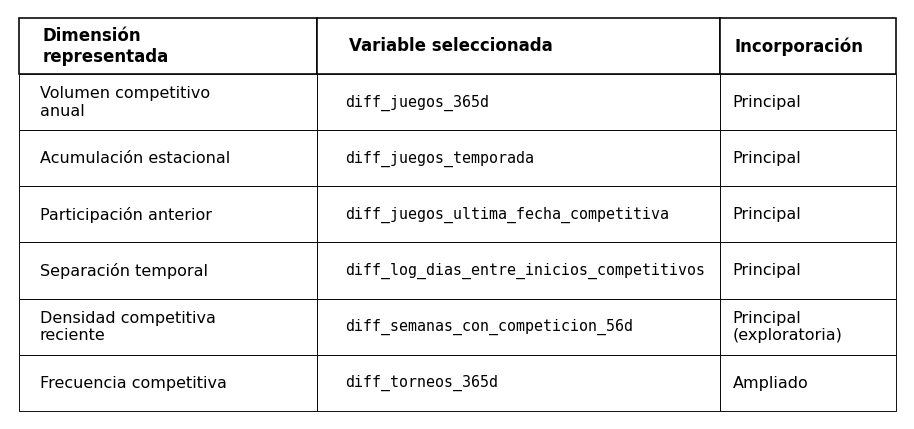

In [35]:
# ============================================================
# CUADRO PARA LA MEMORIA — VARIABLES DE CARGA SELECCIONADAS
# Versión final corregida para evitar truncamientos
# ============================================================

import matplotlib.pyplot as plt

filas = [
    [
        "Volumen competitivo\nanual",
        "diff_juegos_365d",
        "Principal"
    ],
    [
        "Acumulación estacional",
        "diff_juegos_temporada",
        "Principal"
    ],
    [
        "Participación anterior",
        "diff_juegos_ultima_fecha_competitiva",
        "Principal"
    ],
    [
        "Separación temporal",
        "diff_log_dias_entre_inicios_competitivos",
        "Principal"
    ],
    [
        "Densidad competitiva\nreciente",
        "diff_semanas_con_competicion_56d",
        "Principal\n(exploratoria)"
    ],
    [
        "Frecuencia competitiva",
        "diff_torneos_365d",
        "Ampliado"
    ]
]

columnas = [
    "Dimensión\nrepresentada",
    "Variable seleccionada",
    "Incorporación"
]

fig, ax = plt.subplots(figsize=(9.0, 4.15))
ax.axis("off")

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.34, 0.46, 0.20],
    bbox=[0.01, 0.02, 0.98, 0.96]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11.5)

# Ajuste global de altura de filas
tabla.scale(1, 1.28)

# Encabezados
for j in range(len(columnas)):
    celda = tabla[(0, j)]
    celda.set_text_props(weight="bold", fontsize=12)
    celda.set_linewidth(1.15)
    celda.PAD = 0.08
    celda.get_text().set_va("center")

# Cuerpo
for i in range(1, len(filas) + 1):
    for j in range(len(columnas)):
        celda = tabla[(i, j)]
        celda.set_linewidth(0.65)
        celda.PAD = 0.07
        celda.get_text().set_va("center")

# Tipografía monoespaciada para variables
for i in range(1, len(filas) + 1):
    texto_variable = tabla[(i, 1)].get_text()
    texto_variable.set_fontfamily("monospace")
    texto_variable.set_fontsize(10.8)

plt.tight_layout(pad=0.2)
plt.show()



### Cuadro resumen de las especificaciones de modelización

Una vez seleccionados los predictores tradicionales y las variables de carga competitiva, se genera un cuadro resumen de las especificaciones definidas para la modelización.

Se distinguen las familias de 365 y 180 días y, dentro de cada una, los modelos base, principal y ampliado. El modelo base contiene los 29 predictores tradicionales seleccionados y el control temporal `dias_desde_inicio_temporada`. La especificación principal incorpora cinco variables diferenciales de carga, mientras que la ampliada añade además la medida de frecuencia competitiva correspondiente a cada horizonte.

El cuadro tiene únicamente una finalidad de síntesis para la memoria y no modifica los conjuntos de predictores definidos previamente.

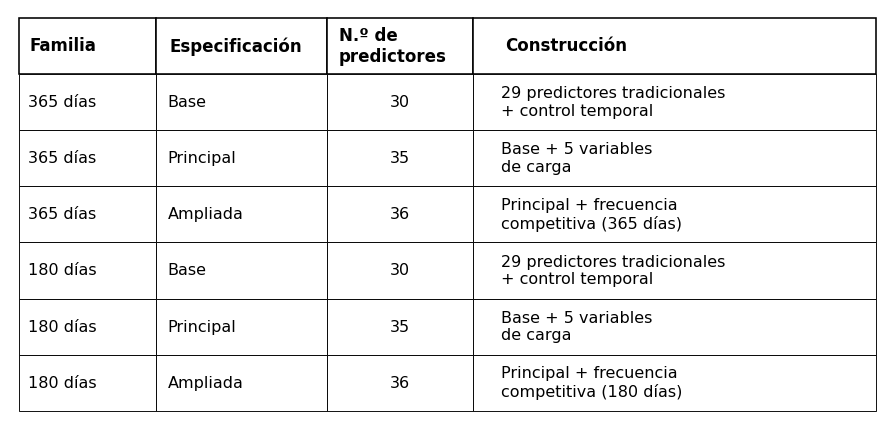

In [36]:
# ============================================================
# CUADRO PARA LA MEMORIA — ESPECIFICACIONES DE MODELIZACIÓN
# ============================================================

import matplotlib.pyplot as plt

filas = [
    [
        "365 días",
        "Base",
        "30",
        "29 predictores tradicionales\n+ control temporal"
    ],
    [
        "365 días",
        "Principal",
        "35",
        "Base + 5 variables\nde carga"
    ],
    [
        "365 días",
        "Ampliada",
        "36",
        "Principal + frecuencia\ncompetitiva (365 días)"
    ],
    [
        "180 días",
        "Base",
        "30",
        "29 predictores tradicionales\n+ control temporal"
    ],
    [
        "180 días",
        "Principal",
        "35",
        "Base + 5 variables\nde carga"
    ],
    [
        "180 días",
        "Ampliada",
        "36",
        "Principal + frecuencia\ncompetitiva (180 días)"
    ]
]

columnas = [
    "Familia",
    "Especificación",
    "N.º de\npredictores",
    "Construcción"
]

fig, ax = plt.subplots(figsize=(8.8, 4.15))
ax.axis("off")

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.16, 0.20, 0.17, 0.47],
    bbox=[0.01, 0.02, 0.98, 0.96]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11.5)
tabla.scale(1, 1.25)

# Encabezados
for j in range(len(columnas)):
    celda = tabla[(0, j)]
    celda.set_text_props(weight="bold", fontsize=12)
    celda.set_linewidth(1.15)
    celda.PAD = 0.08
    celda.get_text().set_va("center")

# Cuerpo
for i in range(1, len(filas) + 1):
    for j in range(len(columnas)):
        celda = tabla[(i, j)]
        celda.set_linewidth(0.65)
        celda.PAD = 0.07
        celda.get_text().set_va("center")

# Centrado de la columna con el número de predictores
for i in range(1, len(filas) + 1):
    tabla[(i, 2)].get_text().set_ha("center")

plt.tight_layout(pad=0.2)
plt.show()



## 13. Datasets finales

Se generarán cinco datasets destinados a preservar la trazabilidad y preparar las etapas posteriores de modelización y evaluación.

### Dataset maestro

`df_jugador_cargas_enriquecidas_final.csv` conservará las variables originales y derivadas obtenidas durante el análisis. No se utilizará directamente como matriz completa de predictores.

### Dataset principal de desarrollo — 365 días

`df_modelo_principal_365d.csv` contendrá las observaciones de desarrollo compatibles con la familia principal de 365 días, junto con las variables identificativas, los 29 predictores tradicionales, el control temporal, las seis diferencias de carga candidatas y la variable objetivo.

El modelo principal utilizará cinco diferencias de carga y la especificación ampliada añadirá `diff_torneos_365d`.

### Dataset de robustez de desarrollo — 180 días

`df_modelo_robustez_180d.csv` mantendrá la misma estructura, sustituyendo las medidas de 365 días por sus equivalentes de 180 días cuando corresponda.

### Datasets de evaluación temporal externa

`df_modelo_principal_365d_validacion.csv` y `df_modelo_robustez_180d_validacion.csv` contendrán exclusivamente las observaciones correspondientes a la evaluación temporal externa de 2024 para las familias de 365 y 180 días, respectivamente.

La temporada 2024 se conserva separada de los datasets de desarrollo y no interviene en las decisiones de selección realizadas en este notebook.

Además, se guardará `configuracion_variables_modelos.json` con las listas exactas de predictores y `resumen_seleccion_variables_carga.csv` con la trazabilidad de las decisiones adoptadas sobre las variables de carga.

In [37]:

# ============================================================
# 13.1. CONSTRUCCIÓN DE LOS DATASETS DE MODELIZACIÓN
# ============================================================


# ------------------------------------------------------------
# 1. Variables de identificación y trazabilidad
# ------------------------------------------------------------

variables_identificacion_deseadas = [
    "_id_partido",
    "identificador_torneo",
    "numero_partido",
    "jugador_id",
    "jugador_nombre",
    "rival_id",
    "rival_nombre",
    "fecha_torneo",
    "nombre_torneo",
    "match_year",
    "es_muestra_estudio",
    "es_buffer_carga",
    "es_desarrollo_modelo",
    "es_validacion_temporal",
    "superficie",
    "nivel_torneo",
    "ronda",
    "pais",
    "pais_rival"
]


# Solo se conservarán las columnas que existan realmente.
variables_identificacion_modelo = [
    columna
    for columna in variables_identificacion_deseadas
    if columna in data.columns
]


identificadores_esenciales = [
    "_id_partido",
    "jugador_id",
    "fecha_torneo",
    "match_year"
]


identificadores_ausentes = [
    columna
    for columna in identificadores_esenciales
    if columna not in data.columns
]


assert not identificadores_ausentes, (
    f"Faltan identificadores esenciales: "
    f"{identificadores_ausentes}"
)


# ------------------------------------------------------------
# 2. Columnas de los datasets compactos
# ------------------------------------------------------------

columnas_dataset_principal_365d = list(
    dict.fromkeys(
        variables_identificacion_modelo
        + predictores_modelo_base
        + cargas_relativas_candidatas_365d
        + [variable_objetivo_modelo]
    )
)


columnas_dataset_robustez_180d = list(
    dict.fromkeys(
        variables_identificacion_modelo
        + predictores_modelo_base
        + cargas_relativas_candidatas_180d
        + [variable_objetivo_modelo]
    )
)


assert len(columnas_dataset_principal_365d) == len(
    set(columnas_dataset_principal_365d)
)

assert len(columnas_dataset_robustez_180d) == len(
    set(columnas_dataset_robustez_180d)
)


# ------------------------------------------------------------
# 3. Reconstrucción desde el dataset maestro
# ------------------------------------------------------------

# Se recuperan las filas desde data para incorporar todas
# las variables creadas hasta este punto del notebook.

muestra_principal_final = data.loc[
    data_muestra_principal_emparejada.index
].copy()


muestra_robustez_final = data.loc[
    data_robustez_180d_emparejada.index
].copy()


muestra_validacion_principal_final = data.loc[
    data_validacion_principal_365d.index
].copy()

muestra_validacion_robustez_final = data.loc[
    data_validacion_robustez_180d.index
].copy()

assert len(muestra_principal_final) == len(data_muestra_principal_emparejada)
assert len(muestra_robustez_final) == len(data_robustez_180d_emparejada)

assert len(muestra_validacion_principal_final) == len(data_validacion_principal_365d)
assert len(muestra_validacion_robustez_final) == len(data_validacion_robustez_180d)

assert muestra_principal_final["es_desarrollo_modelo"].eq(1).all()
assert muestra_robustez_final["es_desarrollo_modelo"].eq(1).all()

assert muestra_validacion_principal_final["es_validacion_temporal"].eq(1).all()
assert muestra_validacion_robustez_final["es_validacion_temporal"].eq(1).all()


# ------------------------------------------------------------
# 4. Función definitiva de preparación
# ------------------------------------------------------------

def preparar_dataset_modelizacion(
    muestra,
    columnas,
    predictores,
    variables_relativas,
    nombre
):
    """
    Prepara un dataset compacto de modelización.

    Se mantienen todos los partidos emparejados.
    Únicamente se permiten valores ausentes en:
    diff_altura, diff_ranking y diff_edad.

    La imputación se realizará posteriormente dentro
    del pipeline de entrenamiento.
    """

    # --------------------------------------------------------
    # Comprobación de columnas
    # --------------------------------------------------------

    columnas_necesarias = list(
        dict.fromkeys(
            columnas
            + predictores
            + variables_relativas
            + [variable_objetivo_modelo]
        )
    )


    columnas_ausentes = [
        columna
        for columna in columnas_necesarias
        if columna not in muestra.columns
    ]


    assert not columnas_ausentes, (
        f"Faltan columnas en {nombre}: "
        f"{columnas_ausentes}"
    )


    # --------------------------------------------------------
    # Selección y ordenación temporal
    # --------------------------------------------------------

    df_modelo = (
        muestra[columnas]
        .copy()
        .sort_values(
            [
                "fecha_torneo",
                "_id_partido",
                "jugador_id"
            ]
        )
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Validación de la estructura jugador-partido
    # --------------------------------------------------------

    filas_por_partido = (
        df_modelo
        .groupby("_id_partido")
        .size()
    )


    assert filas_por_partido.eq(2).all()


    # --------------------------------------------------------
    # Predictores que deben estar completamente observados
    # --------------------------------------------------------

    predictores_sin_nulos = [
        variable
        for variable in predictores
        if variable not in variables_con_nulos_permitidos
    ]


    assert (
        df_modelo[predictores_sin_nulos]
        .notna()
        .all()
        .all()
    )


    matriz_sin_nulos = (
        df_modelo[predictores_sin_nulos]
        .apply(pd.to_numeric, errors="coerce")
    )


    assert (
        matriz_sin_nulos
        .notna()
        .all()
        .all()
    )


    assert np.isfinite(
        matriz_sin_nulos.to_numpy()
    ).all()


    # --------------------------------------------------------
    # Validación de los nulos permitidos
    # --------------------------------------------------------

    for variable in variables_con_nulos_permitidos:

        if variable not in predictores:
            continue

        serie_original = df_modelo[variable]

        serie_numerica = pd.to_numeric(
            serie_original,
            errors="coerce"
        )


        # La conversión no debe generar nuevos nulos.
        assert (
            serie_numerica.isna().sum()
            ==
            serie_original.isna().sum()
        )


        # Los valores observados deben ser finitos.
        assert np.isfinite(
            serie_numerica
            .dropna()
            .to_numpy()
        ).all()


    # --------------------------------------------------------
    # Validación de la variable objetivo
    # --------------------------------------------------------

    assert (
        df_modelo[variable_objetivo_modelo]
        .notna()
        .all()
    )


    assert (
        df_modelo[variable_objetivo_modelo]
        .between(0, 1)
        .all()
    )


    suma_objetivo_por_partido = (
        df_modelo
        .groupby("_id_partido")[
            variable_objetivo_modelo
        ]
        .sum()
    )


    assert np.allclose(
        suma_objetivo_por_partido,
        1,
        atol=1e-8
    )


    # --------------------------------------------------------
    # Validación de las diferencias jugador-rival
    # --------------------------------------------------------

    assert (
        df_modelo[variables_relativas]
        .notna()
        .all()
        .all()
    )


    for variable in variables_relativas:

        suma_diferencia_por_partido = (
            df_modelo
            .groupby("_id_partido")[variable]
            .sum()
        )


        assert np.allclose(
            suma_diferencia_por_partido,
            0,
            atol=1e-8
        )


    # --------------------------------------------------------
    # Resumen
    # --------------------------------------------------------

    resumen_nulos = (
        df_modelo[
            variables_con_nulos_permitidos
        ]
        .isna()
        .sum()
        .rename("numero_nulos")
        .to_frame()
    )


    print(f"\n{nombre}")
    print("Dimensiones:", df_modelo.shape)

    print(
        "Partidos:",
        df_modelo["_id_partido"].nunique()
    )

    print(
        "Jugadores:",
        df_modelo["jugador_id"].nunique()
    )

    print("\nValores ausentes permitidos:")

    display(resumen_nulos)


    return df_modelo


# ------------------------------------------------------------
# 5. Construcción de los datasets finales
# ------------------------------------------------------------

df_modelo_principal_365d = (
    preparar_dataset_modelizacion(
        muestra=muestra_principal_final,
        columnas=columnas_dataset_principal_365d,
        predictores=predictores_modelo_ampliado_365d,
        variables_relativas=(
            cargas_relativas_candidatas_365d
        ),
        nombre="Dataset principal 365 días"
    )
)


df_modelo_robustez_180d = (
    preparar_dataset_modelizacion(
        muestra=muestra_robustez_final,
        columnas=columnas_dataset_robustez_180d,
        predictores=(
            predictores_modelo_robustez_ampliado_180d
        ),
        variables_relativas=(
            cargas_relativas_candidatas_180d
        ),
        nombre="Dataset de robustez 180 días"
    )
)

df_modelo_principal_365d_validacion = (
    preparar_dataset_modelizacion(
        muestra=muestra_validacion_principal_final,
        columnas=columnas_dataset_principal_365d,
        predictores=predictores_modelo_ampliado_365d,
        variables_relativas=(
            cargas_relativas_candidatas_365d
        ),
        nombre="Dataset validación principal 365 días"
    )
)

df_modelo_robustez_180d_validacion = (
    preparar_dataset_modelizacion(
        muestra=muestra_validacion_robustez_final,
        columnas=columnas_dataset_robustez_180d,
        predictores=(
            predictores_modelo_robustez_ampliado_180d
        ),
        variables_relativas=(
            cargas_relativas_candidatas_180d
        ),
        nombre="Dataset validación robustez 180 días"
    )
)

# ------------------------------------------------------------
# 6. Comprobación final de tamaños
# ------------------------------------------------------------

assert len(df_modelo_principal_365d) == len(muestra_principal_final)
assert len(df_modelo_robustez_180d) == len(muestra_robustez_final)

assert len(df_modelo_principal_365d_validacion) == len(
    muestra_validacion_principal_final
)

assert len(df_modelo_robustez_180d_validacion) == len(
    muestra_validacion_robustez_final
)

assert df_modelo_principal_365d["es_desarrollo_modelo"].eq(1).all()
assert df_modelo_robustez_180d["es_desarrollo_modelo"].eq(1).all()

assert df_modelo_principal_365d_validacion[
    "es_validacion_temporal"
].eq(1).all()

assert df_modelo_robustez_180d_validacion[
    "es_validacion_temporal"
].eq(1).all()

print(
    "\nConstrucción de los datasets "
    "de modelización completada correctamente."
)




Dataset principal 365 días
Dimensiones: (73250, 56)
Partidos: 36625
Jugadores: 1176

Valores ausentes permitidos:


,numero_nulos
diff_altura,1586
diff_ranking,838
diff_edad,2



Dataset de robustez 180 días
Dimensiones: (73450, 56)
Partidos: 36725
Jugadores: 1176

Valores ausentes permitidos:


,numero_nulos
diff_altura,1586
diff_ranking,838
diff_edad,2



Dataset validación principal 365 días
Dimensiones: (5912, 56)
Partidos: 2956
Jugadores: 369

Valores ausentes permitidos:


,numero_nulos
diff_altura,52
diff_ranking,40
diff_edad,0



Dataset validación robustez 180 días
Dimensiones: (5912, 56)
Partidos: 2956
Jugadores: 369

Valores ausentes permitidos:


,numero_nulos
diff_altura,52
diff_ranking,40
diff_edad,0



Construcción de los datasets de modelización completada correctamente.


In [38]:

# ============================================================
# 13.2. EXPORTACIÓN DEFINITIVA DE LOS RESULTADOS
# ============================================================


# ------------------------------------------------------------
# 1. Preparación de la ruta de salida
# ------------------------------------------------------------

ruta_salida.mkdir(
    parents=True,
    exist_ok=True
)


rutas_archivos = {
    "dataset_maestro":
        ruta_salida
        / "df_jugador_cargas_enriquecidas_final.csv",

    "dataset_principal_365d":
        ruta_salida
        / "df_modelo_principal_365d.csv",

    "dataset_robustez_180d":
        ruta_salida
        / "df_modelo_robustez_180d.csv",

    "dataset_principal_365d_validacion":
        ruta_salida
        / "df_modelo_principal_365d_validacion.csv",

    "dataset_robustez_180d_validacion":
        ruta_salida
        / "df_modelo_robustez_180d_validacion.csv",        

    "configuracion_modelos":
        ruta_salida
        / "configuracion_variables_modelos.json",

    "resumen_seleccion":
        ruta_salida
        / "resumen_seleccion_variables_carga.csv"
}


# ------------------------------------------------------------
# 2. Comprobaciones inmediatamente anteriores a la exportación
# ------------------------------------------------------------
assert len(data) == filas_iniciales
assert data["_id_partido"].nunique() == partidos_iniciales

assert len(df_modelo_principal_365d) == len(muestra_principal_final)
assert len(df_modelo_robustez_180d) == len(muestra_robustez_final)

assert len(df_modelo_principal_365d_validacion) == len(
    muestra_validacion_principal_final
)

assert len(df_modelo_robustez_180d_validacion) == len(
    muestra_validacion_robustez_final
)

assert df_modelo_principal_365d["es_desarrollo_modelo"].eq(1).all()
assert df_modelo_robustez_180d["es_desarrollo_modelo"].eq(1).all()

assert df_modelo_principal_365d_validacion[
    "es_validacion_temporal"
].eq(1).all()

assert df_modelo_robustez_180d_validacion[
    "es_validacion_temporal"
].eq(1).all()


assert (
    list(df_modelo_principal_365d.columns)
    ==
    columnas_dataset_principal_365d
)

assert (
    list(df_modelo_robustez_180d.columns)
    ==
    columnas_dataset_robustez_180d
)


# No debe haber duplicados exactos de una misma
# perspectiva jugador-partido.

assert not df_modelo_principal_365d.duplicated(
    subset=[
        "_id_partido",
        "jugador_id"
    ]
).any()


assert not df_modelo_robustez_180d.duplicated(
    subset=[
        "_id_partido",
        "jugador_id"
    ]
).any()


# ------------------------------------------------------------
# 3. Registro de las decisiones de selección
# ------------------------------------------------------------

resumen_seleccion_variables_carga = pd.DataFrame(
    [
        {
            "variable_original": "juegos_365d",
            "variable_final": "diff_juegos_365d",
            "familia": "Ventana móvil de 365 días",
            "decision": "Núcleo principal",
            "justificacion":
                "Representante del volumen competitivo anual."
        },
        {
            "variable_original": "sets_365d",
            "variable_final": "",
            "familia": "Ventana móvil de 365 días",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_365d."
        },
        {
            "variable_original": "partidos_365d",
            "variable_final": "",
            "familia": "Ventana móvil de 365 días",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_365d."
        },
        {
            "variable_original": "torneos_365d",
            "variable_final": "diff_torneos_365d",
            "familia": "Ventana móvil de 365 días",
            "decision": "Sensibilidad",
            "justificacion":
                "Aporta frecuencia competitiva, pero presenta "
                "redundancia con juegos_365d."
        },
        {
            "variable_original": "juegos_180d",
            "variable_final": "diff_juegos_180d",
            "familia": "Ventana móvil de 180 días",
            "decision": "Robustez",
            "justificacion":
                "Alternativa de medio plazo a juegos_365d."
        },
        {
            "variable_original": "sets_180d",
            "variable_final": "",
            "familia": "Ventana móvil de 180 días",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_180d."
        },
        {
            "variable_original": "partidos_180d",
            "variable_final": "",
            "familia": "Ventana móvil de 180 días",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_180d."
        },
        {
            "variable_original": "torneos_180d",
            "variable_final": "diff_torneos_180d",
            "familia": "Ventana móvil de 180 días",
            "decision": "Sensibilidad de robustez",
            "justificacion":
                "Variable adicional de frecuencia competitiva."
        },
        {
            "variable_original": "juegos_temporada",
            "variable_final": "diff_juegos_temporada",
            "familia": "Temporada",
            "decision": "Núcleo principal",
            "justificacion":
                "Representa la carga acumulada durante la temporada competitiva vigente."
        },
        {
            "variable_original": "sets_temporada",
            "variable_final": "",
            "familia": "Temporada",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_temporada."
        },
        {
            "variable_original": "partidos_temporada",
            "variable_final": "",
            "familia": "Temporada",
            "decision": "Descartada",
            "justificacion":
                "Redundancia muy elevada con juegos_temporada."
        },
        {
            "variable_original": "torneos_temporada",
            "variable_final": "",
            "familia": "Temporada",
            "decision": "Descartada",
            "justificacion":
                "No aporta una dimensión suficientemente "
                "diferenciada respecto al volumen de temporada."
        },
        {
            "variable_original":
                "juegos_ultima_fecha_competitiva",
            "variable_final":
                "diff_juegos_ultima_fecha_competitiva",
            "familia": "Última participación",
            "decision": "Núcleo principal",
            "justificacion":
                "Representa la carga inmediata de la última "
                "participación observable."
        },
        {
            "variable_original":
                "sets_ultima_fecha_competitiva",
            "variable_final": "",
            "familia": "Última participación",
            "decision": "Descartada",
            "justificacion":
                "Redundancia elevada con los juegos de la "
                "última participación."
        },
        {
            "variable_original":
                "partidos_ultima_fecha_competitiva",
            "variable_final": "",
            "familia": "Última participación",
            "decision": "Descartada",
            "justificacion":
                "Redundancia elevada con los juegos de la "
                "última participación."
        },
        {
            "variable_original":
                "torneos_ultima_fecha_competitiva",
            "variable_final": "",
            "familia": "Última participación",
            "decision": "Descartada",
            "justificacion":
                "Variable prácticamente constante."
        },
        {
            "variable_original":
                "dias_entre_inicios_competitivos",
            "variable_final":
                "diff_log_dias_entre_inicios_competitivos",
            "familia": "Recencia",
            "decision": "Transformada",
            "justificacion":
                "Se sustituye por log(1 + días) para reducir "
                "su fuerte asimetría."
        },
        {
            "variable_original":
                "log_dias_entre_inicios_competitivos",
            "variable_final":
                "diff_log_dias_entre_inicios_competitivos",
            "familia": "Recencia",
            "decision": "Núcleo principal",
            "justificacion":
                "Representa la diferencia de descanso o "
                "inactividad entre jugador y rival."
        },
        {
            "variable_original":
                "semanas_con_competicion_56d",
            "variable_final":
                "diff_semanas_con_competicion_56d",
            "familia": "Densidad reciente",
            "decision": "Núcleo principal",
            "justificacion":
                "Representa la distribución de la actividad "
                "competitiva en las ocho semanas anteriores."
        }
    ]
)


assert not resumen_seleccion_variables_carga.empty

assert resumen_seleccion_variables_carga[
    "variable_original"
].notna().all()


# ------------------------------------------------------------
# 4. Configuración reproducible de los modelos
# ------------------------------------------------------------

configuracion_variables_modelos = {
    "version_configuracion": "1.0",

    "unidad_observacion":
        "Jugador-partido con dos perspectivas por partido",

    "variable_objetivo":
        variable_objetivo_modelo,

    "variables_identificacion":
        variables_identificacion_modelo,

    "variables_con_nulos_permitidos":
        variables_con_nulos_permitidos,

    "nota_valores_ausentes":
        (
            "Los valores ausentes no se imputan en este "
            "notebook. La imputación deberá ajustarse "
            "exclusivamente con los datos de entrenamiento."
        ),

    "variables_control_modelo":
        variables_control_modelo,

    "variables_predictivas_tradicionales":
        variables_predictivas_tradicionales,

    "cargas_relativas_nucleo_365d":
        cargas_relativas_nucleo_365d,

    "cargas_relativas_sensibilidad_365d":
        cargas_relativas_sensibilidad_365d,

    "cargas_relativas_candidatas_365d":
        cargas_relativas_candidatas_365d,

    "cargas_relativas_nucleo_180d":
        cargas_relativas_nucleo_180d,

    "cargas_relativas_sensibilidad_180d":
        cargas_relativas_sensibilidad_180d,

    "cargas_relativas_candidatas_180d":
        cargas_relativas_candidatas_180d,

    "predictores_modelo_base":
        predictores_modelo_base,

    "predictores_modelo_base_365d":
        predictores_modelo_base_365d,

   "predictores_modelo_base_180d":
        predictores_modelo_base_180d,

   "familias_comparacion":
        familias_comparacion,

    "predictores_modelo_principal_365d":
        predictores_modelo_principal_365d,

    "predictores_modelo_ampliado_365d":
        predictores_modelo_ampliado_365d,

    "predictores_modelo_robustez_180d":
        predictores_modelo_robustez_180d,

    "predictores_modelo_robustez_ampliado_180d":
        predictores_modelo_robustez_ampliado_180d,

    "columnas_dataset_principal_365d":
        columnas_dataset_principal_365d,

    "columnas_dataset_robustez_180d":
        columnas_dataset_robustez_180d,

    "dimensiones_datasets": {
        "dataset_maestro": {
            "filas": int(data.shape[0]),
            "columnas": int(data.shape[1]),
            "partidos": int(
                data["_id_partido"].nunique()
            )
        },
        "dataset_principal_365d": {
            "filas": int(
                df_modelo_principal_365d.shape[0]
            ),
            "columnas": int(
                df_modelo_principal_365d.shape[1]
            ),
            "partidos": int(
                df_modelo_principal_365d[
                    "_id_partido"
                ].nunique()
            ),
            "jugadores": int(
                df_modelo_principal_365d[
                    "jugador_id"
                ].nunique()
            )
        },
        "dataset_robustez_180d": {
            "filas": int(
                df_modelo_robustez_180d.shape[0]
            ),
            "columnas": int(
                df_modelo_robustez_180d.shape[1]
            ),
            "partidos": int(
                df_modelo_robustez_180d[
                    "_id_partido"
                ].nunique()
            ),
            "jugadores": int(
                df_modelo_robustez_180d[
                    "jugador_id"
                ].nunique()
            )
        },
                "dataset_principal_365d_validacion": {
            "filas": int(
                df_modelo_principal_365d_validacion.shape[0]
            ),
            "columnas": int(
                df_modelo_principal_365d_validacion.shape[1]
            ),
            "partidos": int(
                df_modelo_principal_365d_validacion[
                    "_id_partido"
                ].nunique()
            ),
            "jugadores": int(
                df_modelo_principal_365d_validacion[
                    "jugador_id"
                ].nunique()
            )
        },
        "dataset_robustez_180d_validacion": {
            "filas": int(
                df_modelo_robustez_180d_validacion.shape[0]
            ),
            "columnas": int(
                df_modelo_robustez_180d_validacion.shape[1]
            ),
            "partidos": int(
                df_modelo_robustez_180d_validacion[
                    "_id_partido"
                ].nunique()
            ),
            "jugadores": int(
                df_modelo_robustez_180d_validacion[
                    "jugador_id"
                ].nunique()
            )
        }
    }
}


# ------------------------------------------------------------
# 5. Exportación
# ------------------------------------------------------------

data.to_csv(
    rutas_archivos["dataset_maestro"],
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)


df_modelo_principal_365d.to_csv(
    rutas_archivos["dataset_principal_365d"],
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)


df_modelo_robustez_180d.to_csv(
    rutas_archivos["dataset_robustez_180d"],
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

df_modelo_principal_365d_validacion.to_csv(
    rutas_archivos["dataset_principal_365d_validacion"],
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

df_modelo_robustez_180d_validacion.to_csv(
    rutas_archivos["dataset_robustez_180d_validacion"],
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)


with open(
    rutas_archivos["configuracion_modelos"],
    mode="w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        configuracion_variables_modelos,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


resumen_seleccion_variables_carga.to_csv(
    rutas_archivos["resumen_seleccion"],
    index=False,
    encoding="utf-8-sig"
)


print("Exportación final completada.")

for nombre, ruta in rutas_archivos.items():
    print(f"- {nombre}: {ruta}")



Exportación final completada.
- dataset_maestro: df_jugador_cargas_enriquecidas_final.csv
- dataset_principal_365d: df_modelo_principal_365d.csv
- dataset_robustez_180d: df_modelo_robustez_180d.csv
- dataset_principal_365d_validacion: df_modelo_principal_365d_validacion.csv
- dataset_robustez_180d_validacion: df_modelo_robustez_180d_validacion.csv
- configuracion_modelos: configuracion_variables_modelos.json
- resumen_seleccion: resumen_seleccion_variables_carga.csv


In [39]:
# ============================================================
# 13.3. VERIFICACIÓN DE LOS ARCHIVOS EXPORTADOS
# ============================================================

# ------------------------------------------------------------
# 1. Existencia y tamaño de los archivos
# ------------------------------------------------------------

for nombre, ruta in rutas_archivos.items():

    assert ruta.exists(), (
        f"No se ha creado el archivo: {ruta}"
    )

    assert ruta.stat().st_size > 0, (
        f"El archivo está vacío: {ruta}"
    )

# ------------------------------------------------------------
# 2. Nueva lectura desde el disco
# ------------------------------------------------------------

data_verificacion = pd.read_csv(
    rutas_archivos["dataset_maestro"],
    low_memory=False,
    parse_dates=["fecha_torneo"]
)

principal_verificacion = pd.read_csv(
    rutas_archivos["dataset_principal_365d"],
    low_memory=False,
    parse_dates=["fecha_torneo"]
)

robustez_verificacion = pd.read_csv(
    rutas_archivos["dataset_robustez_180d"],
    low_memory=False,
    parse_dates=["fecha_torneo"]
)

principal_validacion_verificacion = pd.read_csv(
    rutas_archivos["dataset_principal_365d_validacion"],
    low_memory=False,
    parse_dates=["fecha_torneo"]
)

robustez_validacion_verificacion = pd.read_csv(
    rutas_archivos["dataset_robustez_180d_validacion"],
    low_memory=False,
    parse_dates=["fecha_torneo"]
)

seleccion_verificacion = pd.read_csv(
    rutas_archivos["resumen_seleccion"],
    low_memory=False
)

with open(
    rutas_archivos["configuracion_modelos"],
    mode="r",
    encoding="utf-8"
) as archivo_json:

    configuracion_verificacion = json.load(
        archivo_json
    )

# ------------------------------------------------------------
# 3. Verificación del dataset maestro
# ------------------------------------------------------------

assert data_verificacion.shape == data.shape

assert list(data_verificacion.columns) == list(data.columns)

assert (
    data_verificacion["_id_partido"].nunique()
    == data["_id_partido"].nunique()
)

# ------------------------------------------------------------
# 4. Verificación de datasets de desarrollo
# ------------------------------------------------------------

assert principal_verificacion.shape == df_modelo_principal_365d.shape
assert robustez_verificacion.shape == df_modelo_robustez_180d.shape

assert (
    list(principal_verificacion.columns)
    == columnas_dataset_principal_365d
)

assert (
    list(robustez_verificacion.columns)
    == columnas_dataset_robustez_180d
)

assert principal_verificacion["es_desarrollo_modelo"].eq(1).all()
assert robustez_verificacion["es_desarrollo_modelo"].eq(1).all()

# ------------------------------------------------------------
# 5. Verificación de datasets de validación
# ------------------------------------------------------------

assert (
    principal_validacion_verificacion.shape
    == df_modelo_principal_365d_validacion.shape
)

assert (
    robustez_validacion_verificacion.shape
    == df_modelo_robustez_180d_validacion.shape
)

assert (
    list(principal_validacion_verificacion.columns)
    == columnas_dataset_principal_365d
)

assert (
    list(robustez_validacion_verificacion.columns)
    == columnas_dataset_robustez_180d
)

assert principal_validacion_verificacion[
    "es_validacion_temporal"
].eq(1).all()

assert robustez_validacion_verificacion[
    "es_validacion_temporal"
].eq(1).all()

# ------------------------------------------------------------
# 6. Verificación de estructura jugador-partido
# ------------------------------------------------------------

for nombre, df in {
    "principal_desarrollo": principal_verificacion,
    "robustez_desarrollo": robustez_verificacion,
    "principal_validacion": principal_validacion_verificacion,
    "robustez_validacion": robustez_validacion_verificacion
}.items():

    filas_por_partido = (
        df.groupby("_id_partido")
        .size()
    )

    assert filas_por_partido.eq(2).all(), (
        f"Algún partido no conserva dos perspectivas en {nombre}."
    )

    assert df[variable_objetivo_modelo].notna().all()

    assert (
        df[variable_objetivo_modelo]
        .between(0, 1)
        .all()
    )

# ------------------------------------------------------------
# 7. Verificación de valores ausentes en predictores
# ------------------------------------------------------------

predictores_principal_sin_nulos = [
    variable
    for variable in predictores_modelo_ampliado_365d
    if variable not in variables_con_nulos_permitidos
]

predictores_robustez_sin_nulos = [
    variable
    for variable
    in predictores_modelo_robustez_ampliado_180d
    if variable not in variables_con_nulos_permitidos
]

for nombre, df, predictores in [
    (
        "principal_desarrollo",
        principal_verificacion,
        predictores_principal_sin_nulos
    ),
    (
        "principal_validacion",
        principal_validacion_verificacion,
        predictores_principal_sin_nulos
    ),
    (
        "robustez_desarrollo",
        robustez_verificacion,
        predictores_robustez_sin_nulos
    ),
    (
        "robustez_validacion",
        robustez_validacion_verificacion,
        predictores_robustez_sin_nulos
    )
]:

    assert (
        df[predictores]
        .notna()
        .all()
        .all()
    ), (
        f"Hay nulos no permitidos en {nombre}."
    )

# ------------------------------------------------------------
# 8. Verificación del JSON y del resumen
# ------------------------------------------------------------

assert (
    configuracion_verificacion["variable_objetivo"]
    == variable_objetivo_modelo
)

assert (
    configuracion_verificacion[
        "variables_con_nulos_permitidos"
    ]
    == variables_con_nulos_permitidos
)

assert not seleccion_verificacion.empty

print(
    "Todos los archivos se han exportado, recargado "
    "y validado correctamente."
)

print("Dataset maestro:", data_verificacion.shape)
print("Principal 365d desarrollo:", principal_verificacion.shape)
print("Robustez 180d desarrollo:", robustez_verificacion.shape)
print("Principal 365d validación:", principal_validacion_verificacion.shape)
print("Robustez 180d validación:", robustez_validacion_verificacion.shape)

Todos los archivos se han exportado, recargado y validado correctamente.
Dataset maestro: (94030, 128)
Principal 365d desarrollo: (73250, 56)
Robustez 180d desarrollo: (73450, 56)
Principal 365d validación: (5912, 56)
Robustez 180d validación: (5912, 56)


## Conclusión

El análisis exploratorio permitió caracterizar las variables de carga competitiva, estudiar su redundancia y evaluar su asociación descriptiva con el rendimiento sin utilizar la temporada 2024 en las decisiones de selección.

La especificación base queda formada por los 29 predictores tradicionales y `dias_desde_inicio_temporada`. La especificación principal incorpora cinco diferencias jugador–rival de carga competitiva, mientras que la ampliada añade la frecuencia competitiva como variable adicional de sensibilidad.

Se han preparado de forma independiente las familias de 365 y 180 días y se han mantenido separados los datasets de desarrollo y de evaluación temporal externa de 2024. Los archivos generados constituyen la entrada de la etapa posterior de modelización.